## Step 1: install Packges

In [ ]:
!pip install pandas numpy plotly ipywidgets nbformat scipy openpyxl tqdm statsmodels scikit-learn -q
print("✅ Packages installed!")

## step 2 : import libraries

In [2]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
import glob
from datetime import datetime
from IPython.display import display, HTML, clear_output
import ipywidgets as widgets
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
import colorsys
from scipy import stats
from tqdm.notebook import tqdm
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings
warnings.filterwarnings('ignore')

pio.renderers.default = 'browser'
pd.set_option('display.max_columns', None)


print("✅ Libraries imported!")
print("=" * 80)

✅ Libraries imported!


## If you need  to import data here uncomment the previous cell

In [20]:
# # ============================================================================
# # CELL 2: LOAD VARIABLES (ضعها في بداية Notebook الجديد)
# # ============================================================================
#
# import pickle
# from pathlib import Path
# from datetime import datetime
#
# print("=" * 80)
# print("📥 LOADING SAVED VARIABLES")
# print("=" * 80)
#
# # ═══════════════════════════════════════════════════════════════════════════
# # 📂 STEP 1: Find save folder
# # ═══════════════════════════════════════════════════════════════════════════
#
# save_folder = Path.home() / "Desktop" / "notebook_variables"
#
# if not save_folder.exists():
#     print()
#     print("❌ No saved sessions found!")
#     print(f"   Expected location: {save_folder}")
#     print()
#     print("💡 First run CELL 1 in your source notebook to save variables")
#     print("=" * 80)
# else:
#     # ═══════════════════════════════════════════════════════════════════════════
#     # 📋 STEP 2: List available sessions
#     # ═══════════════════════════════════════════════════════════════════════════
#
#     sessions = sorted([d for d in save_folder.iterdir() if d.is_dir()], reverse=True)
#
#     if len(sessions) == 0:
#         print()
#         print("❌ No sessions found in folder!")
#         print(f"   Folder exists but is empty: {save_folder}")
#         print()
#         print("💡 Run CELL 1 in your source notebook to create a session")
#         print("=" * 80)
#     else:
#         print()
#         print(f"📂 Found {len(sessions)} saved session(s):")
#         print()
#         print("-" * 80)
#
#         # Display available sessions
#         for idx, session in enumerate(sessions, 1):
#             metadata_path = session / "metadata.pkl"
#
#             if metadata_path.exists():
#                 try:
#                     with open(metadata_path, 'rb') as f:
#                         metadata = pickle.load(f)
#
#                     dt = metadata.get('datetime', metadata.get('timestamp', 'Unknown'))
#                     var_count = metadata.get('success_count',
#                                len([v for v in metadata.get('saved_variables', {}).values()
#                                    if v.get('saved', False)]))
#
#                     print(f"  {idx}. {session.name}")
#                     print(f"     Date: {dt}")
#                     print(f"     Variables: {var_count}")
#
#                     # Show variable names
#                     vars_list = [k for k, v in metadata.get('saved_variables', {}).items()
#                                 if v.get('saved', False)]
#                     if len(vars_list) > 0:
#                         print(f"     Contains: {', '.join(vars_list[:5])}")
#                         if len(vars_list) > 5:
#                             print(f"               ... and {len(vars_list)-5} more")
#                     print()
#                 except:
#                     print(f"  {idx}. {session.name} (metadata error)")
#                     print()
#             else:
#                 print(f"  {idx}. {session.name} (no metadata)")
#                 print()
#
#         print("-" * 80)
#
#         # ═══════════════════════════════════════════════════════════════════════════
#         # 🎯 STEP 3: Choose session to load
#         # ═══════════════════════════════════════════════════════════════════════════
#
#         choice = input("\nEnter session number to load (press Enter for latest): ").strip()
#
#         if choice == '':
#             choice = '1'
#
#         try:
#             session_idx = int(choice) - 1
#
#             if session_idx < 0 or session_idx >= len(sessions):
#                 print(f"\n❌ Invalid choice! Must be 1-{len(sessions)}")
#                 print("=" * 80)
#             else:
#                 selected_session = sessions[session_idx]
#
#                 print()
#                 print("=" * 80)
#                 print(f"📥 Loading session: {selected_session.name}")
#                 print("=" * 80)
#                 print()
#
#                 # ═══════════════════════════════════════════════════════════════════════════
#                 # 📦 STEP 4: Load metadata
#                 # ═══════════════════════════════════════════════════════════════════════════
#
#                 metadata_path = selected_session / "metadata.pkl"
#
#                 if metadata_path.exists():
#                     with open(metadata_path, 'rb') as f:
#                         metadata = pickle.load(f)
#                 else:
#                     print("⚠️  No metadata found - will try to load all .pkl files")
#                     metadata = {'saved_variables': {}}
#
#                 # ═══════════════════════════════════════════════════════════════════════════
#                 # 💾 STEP 5: Load variables
#                 # ═══════════════════════════════════════════════════════════════════════════
#
#                 loaded_count = 0
#                 failed_count = 0
#
#                 saved_vars = metadata.get('saved_variables', {})
#
#                 if len(saved_vars) == 0:
#                     # No metadata, try all .pkl files
#                     pkl_files = list(selected_session.glob("*.pkl"))
#                     print(f"Found {len(pkl_files)} .pkl files (excluding metadata)")
#                     print()
#
#                     for pkl_file in pkl_files:
#                         if pkl_file.name != "metadata.pkl":
#                             var_name = pkl_file.stem  # filename without .pkl
#
#                             try:
#                                 with open(pkl_file, 'rb') as f:
#                                     var_value = pickle.load(f)
#
#                                 globals()[var_name] = var_value
#
#                                 size_kb = pkl_file.stat().st_size / 1024
#                                 size_str = f"{size_kb:.1f} KB" if size_kb < 1024 else f"{size_kb/1024:.1f} MB"
#                                 var_type = type(var_value).__name__
#
#                                 print(f"✅ {var_name:<25} | {var_type:<15} | {size_str}")
#                                 loaded_count += 1
#
#                             except Exception as e:
#                                 print(f"❌ {var_name:<25} | FAILED: {str(e)[:40]}")
#                                 failed_count += 1
#                 else:
#                     # Use metadata
#                     for var_name, var_info in saved_vars.items():
#                         if var_info.get('saved', False):
#                             try:
#                                 file_path = selected_session / f"{var_name}.pkl"
#
#                                 with open(file_path, 'rb') as f:
#                                     var_value = pickle.load(f)
#
#                                 # Load into global scope
#                                 globals()[var_name] = var_value
#
#                                 print(f"✅ {var_name:<25} | {var_info.get('type', 'Unknown'):<15} | {var_info.get('size', 'Unknown')}")
#                                 loaded_count += 1
#
#                             except FileNotFoundError:
#                                 print(f"❌ {var_name:<25} | FILE NOT FOUND")
#                                 failed_count += 1
#                             except Exception as e:
#                                 print(f"❌ {var_name:<25} | FAILED: {str(e)[:40]}")
#                                 failed_count += 1
#
#                 # ═══════════════════════════════════════════════════════════════════════════
#                 # ✅ STEP 6: Summary
#                 # ═══════════════════════════════════════════════════════════════════════════
#
#                 print()
#                 print("=" * 80)
#                 print("✅ LOAD COMPLETE!")
#                 print("=" * 80)
#                 print(f"✅ Loaded:  {loaded_count} variables")
#                 print(f"❌ Failed:  {failed_count} variables")
#                 print("=" * 80)
#                 print()
#                 print("💡 Variables are now available in this notebook!")
#                 print("   Example: print(combined_df.head())")
#                 print("=" * 80)
#
#         except ValueError:
#             print()
#             print("❌ Invalid input! Please enter a number")
#             print("=" * 80)

📥 LOADING SAVED VARIABLES

📂 Found 25 saved session(s):

--------------------------------------------------------------------------------
  1. session_20260119_122517
     Date: 2026-01-19 12:26:21
     Variables: 4
     Contains: combined_df, combined_df_updated, df, inventory_df

  2. session_20260119_121915
     Date: 2026-01-19 12:19:21
     Variables: 1
     Contains: combined_df

  3. session_20260119_100308
     Date: 2026-01-19 10:03:14
     Variables: 3
     Contains: combined_df, df, inventory_df

  4. session_20260119_092005
     Date: 2026-01-19 09:20:13
     Variables: 2
     Contains: combined_df, df

  5. session_20260118_165224
     Date: 2026-01-18 16:54:41
     Variables: 4
     Contains: combined_df, combined_df_updated, df, inventory_df

  6. session_20260118_151536
     Date: 2026-01-18 15:17:07
     Variables: 7
     Contains: combined_df, combined_df_updated, df, inventory_df, sku_df
               ... and 1 more

  7. session_20260118_151247
     Date: 2026-01-1

## Data Loading Function

In [24]:
# import pandas as pd
# import numpy as np
# from pathlib import Path
# import glob
# from tqdm import tqdm
# import os
#
# # ==================== ENRICHMENT LOADERS ====================
#
# def load_supplier_code(file_path):
#     """Load SKU Supplier mapping"""
#     print("\n🏭 Loading SUPPLIER CODE data...")
#     try:
#         df = pd.read_excel(file_path)
#         print(f"✅ Loaded {len(df):,} records")
#         print(f"📋 Columns: {list(df.columns)}")
#
#         sku_col = next((c for c in df.columns if 'sku' in c.lower()), None)
#         supplier_col = next((c for c in df.columns if 'supplier' in c.lower()), None)
#
#         if not sku_col or not supplier_col:
#             print("❌ Required columns (SKU, Supplier) not found")
#             return None
#
#         df = df.rename(columns={sku_col: 'SKU', supplier_col: 'Supplier'})
#         df['SKU'] = df['SKU'].astype(str).str.strip()
#         df['SKU'] = df['SKU'].str.replace(r'\.0+$', '', regex=True)
#
#         df['Supplier'] = df['Supplier'].astype(str).str.strip()
#         df.loc[df['Supplier'].isin(['', 'nan', 'None']), 'Supplier'] = np.nan
#
#         return df[['SKU', 'Supplier']]
#
#     except Exception as e:
#         print(f"❌ SUPPLIER load error: {e}")
#         return None
#
#
# def load_cost_data(cost_file_path):
#     """Load SKU cost data – AUTO DETECT"""
#     print("\n💰 Loading COST data...")
#     try:
#         df = pd.read_excel(cost_file_path)
#         print(f"✅ Loaded {len(df):,} cost records")
#         print(f"📋 Columns: {list(df.columns)}")
#
#         sku_col = next((c for c in df.columns if 'sku' in c.lower()), None)
#         cost_col = next((c for c in df.columns if 'cost' in c.lower() or 'سعر' in c.lower()), None)
#
#         if not sku_col or not cost_col:
#             print("❌ Required columns not found")
#             return None
#
#         df = df.rename(columns={sku_col: 'SKU', cost_col: 'Cost'})
#         df['SKU'] = df['SKU'].astype(str).str.strip()
#         df['Cost'] = pd.to_numeric(df['Cost'], errors='coerce')
#
#         return df[['SKU', 'Cost']]
#
#     except Exception as e:
#         print(f"❌ COST load error: {e}")
#         return None
#
#
# def load_last_entry_date(file_path):
#     """Load SKU Last Entry Date"""
#     print("\n📅 Loading LAST ENTRY DATE data...")
#     try:
#         df = pd.read_excel(file_path)
#         print(f"✅ Loaded {len(df):,} records")
#
#         sku_col = next((c for c in df.columns if 'sku' in c.lower()), None)
#         date_col = next((c for c in df.columns if 'date' in c.lower()), None)
#
#         if not sku_col or not date_col:
#             print("❌ Required columns not found")
#             return None
#
#         df = df.rename(columns={sku_col: 'SKU', date_col: 'LAST_ENTRY_DATE'})
#         df['SKU'] = df['SKU'].astype(str).str.strip()
#         df['LAST_ENTRY_DATE'] = pd.to_datetime(df['LAST_ENTRY_DATE'], errors='coerce')
#
#         return df[['SKU', 'LAST_ENTRY_DATE']]
#
#     except Exception as e:
#         print(f"❌ ENTRY DATE load error: {e}")
#         return None
#
#
# def load_sku_category(file_path):
#     """Load SKU Category mapping"""
#     print("\n🗂️ Loading SKU CATEGORY data...")
#     try:
#         df = pd.read_excel(file_path)
#         print(f"✅ Loaded {len(df):,} records")
#
#         sku_col = next((c for c in df.columns if 'sku' in c.lower()), None)
#         cat_col = next((c for c in df.columns if 'category' in c.lower()), None)
#
#         if not sku_col or not cat_col:
#             print("❌ Required columns not found")
#             return None
#
#         df = df.rename(columns={sku_col: 'SKU', cat_col: 'CATEGORY'})
#         df['SKU'] = df['SKU'].astype(str).str.strip()
#
#         return df[['SKU', 'CATEGORY']]
#
#     except Exception as e:
#         print(f"❌ CATEGORY load error: {e}")
#         return None
#
#
# def load_first_inv_date(file_path):
#     """
#     Load Section First Invoice Date (OPTIONAL)
#
#     File structure:
#     Section | Year
#     --------|------
#     HW-001  | 2020
#     EL-002  | 2019
#
#     Purpose: Track when each section first entered the market
#     """
#     print("\n📆 Loading FIRST INVOICE DATE data...")
#     try:
#         df = pd.read_excel(file_path)
#         print(f"✅ Loaded {len(df):,} records")
#         print(f"📋 Columns: {list(df.columns)}")
#
#         # Smart column detection
#         section_col = next((c for c in df.columns if 'section' in c.lower()), None)
#         year_col = next((c for c in df.columns if 'year' in c.lower()), None)
#
#         if not section_col or not year_col:
#             print("⚠️  Required columns (Section, Year) not found")
#             print(f"    Available: {list(df.columns)}")
#             return None
#
#         df = df.rename(columns={section_col: 'Section', year_col: 'First_Inv_Year'})
#
#         # Clean section names
#         df['Section'] = df['Section'].astype(str).str.strip()
#
#         # Convert year to numeric
#         df['First_Inv_Year'] = pd.to_numeric(df['First_Inv_Year'], errors='coerce')
#
#         # Remove invalid rows
#         df = df.dropna(subset=['Section', 'First_Inv_Year'])
#         df = df[df['First_Inv_Year'] > 1900]  # Sanity check
#
#         print(f"✅ Processed {len(df)} valid section-year mappings")
#         print(f"📊 Year range: {int(df['First_Inv_Year'].min())} - {int(df['First_Inv_Year'].max())}")
#
#         return df[['Section', 'First_Inv_Year']]
#
#     except FileNotFoundError:
#         print("⚠️  File not found - skipping (optional)")
#         return None
#     except Exception as e:
#         print(f"⚠️  FIRST INV DATE load error: {e}")
#         print("    Continuing without this data (optional)")
#         return None
#
#
# def load_stock_data(stock_file_path):
#     """
#     Load stock data with SMART column detection
#
#     Expected columns (flexible names):
#     - Collection Name / Collection
#     - SKU
#     - STOCK / Current Stock
#     - OUTSTANDING / Outstanding
#     - PR QTY / PR / Purchase Requisition
#
#     Calculates:
#     - EFFECTIVE_STOCK = STOCK + OUTSTANDING + PR
#     """
#     print("\n📦 Loading STOCK data...")
#     try:
#         df = pd.read_excel(stock_file_path)
#         print(f"✅ Loaded {len(df):,} records")
#         print(f"📋 Columns: {list(df.columns)}")
#
#         # Smart column mapping
#         rename_map = {}
#
#         for c in df.columns:
#             cl = c.lower().strip()
#
#             # SKU detection
#             if 'sku' in cl:
#                 rename_map[c] = 'SKU'
#
#             # Collection detection
#             elif 'collection' in cl:
#                 rename_map[c] = 'COLLECTION'
#
#             # Stock detection
#             elif cl in ['stock', 'current stock', 'current_stock', 'stocks']:
#                 rename_map[c] = 'CURRENT_STOCK'
#
#             # Outstanding detection
#             elif 'outstanding' in cl:
#                 rename_map[c] = 'OUTSTANDING'
#
#             # PR detection (Purchase Requisition)
#             elif 'pr' in cl or 'purchase requisition' in cl:
#                 rename_map[c] = 'PR'
#
#         df = df.rename(columns=rename_map)
#
#         print(f"📋 Mapped columns: {rename_map}")
#
#         # Verify required columns
#         if 'SKU' not in df.columns:
#             print("❌ SKU column not found!")
#             return None
#
#         # Clean SKU
#         df['SKU'] = df['SKU'].astype(str).str.strip()
#         df['SKU'] = df['SKU'].str.replace(r'\.0+$', '', regex=True)
#
#         # Convert numeric columns
#         numeric_cols = ['CURRENT_STOCK', 'OUTSTANDING', 'PR']
#
#         for col in numeric_cols:
#             if col in df.columns:
#                 df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
#                 print(f"✅ {col}: {df[col].sum():,.0f} total units")
#             else:
#                 df[col] = 0
#                 print(f"⚠️  {col}: Not found, defaulting to 0")
#
#         # Calculate EFFECTIVE STOCK
#         df['EFFECTIVE_STOCK'] = (
#             df['CURRENT_STOCK'] +
#             df['OUTSTANDING'] +
#             df['PR']
#         ).astype(int)
#
#         print(f"\n📊 STOCK SUMMARY:")
#         print(f"   Current Stock:    {df['CURRENT_STOCK'].sum():>15,.0f}")
#         print(f"   Outstanding:      {df['OUTSTANDING'].sum():>15,.0f}")
#         print(f"   PR (Requisition): {df['PR'].sum():>15,.0f}")
#         print(f"   ─────────────────────────────────────")
#         print(f"   EFFECTIVE STOCK:  {df['EFFECTIVE_STOCK'].sum():>15,.0f}")
#
#         return df
#
#     except Exception as e:
#         print(f"❌ STOCK load error: {e}")
#         return None
#
#
# # ==================== SALES TYPE DETECTION ====================
#
# def detect_sales_type(df, contract_threshold=100):
#     """
#     Detect sales type per transaction
#     CONTRACT = bal Qty >= threshold
#     FAMILY   = otherwise
#     """
#     print(f"\n🏢 Detecting sales types (threshold: {contract_threshold})...")
#
#     df['bal Qty'] = pd.to_numeric(df['bal Qty'], errors='coerce')
#     df['bal Value'] = pd.to_numeric(df['bal Value'], errors='coerce')
#
#     df['Sales_Type'] = np.where(
#         df['bal Qty'] >= contract_threshold,
#         'CONTRACT',
#         'FAMILY'
#     )
#
#     contract_count = (df['Sales_Type'] == 'CONTRACT').sum()
#     family_count = (df['Sales_Type'] == 'FAMILY').sum()
#
#     contract_value = df.loc[df['Sales_Type'] == 'CONTRACT', 'bal Value'].sum()
#     family_value = df.loc[df['Sales_Type'] == 'FAMILY', 'bal Value'].sum()
#
#     print(f"✅ CONTRACT: {contract_count:,} records | Value: {contract_value:,.0f}")
#     print(f"✅ FAMILY  : {family_count:,} records | Value: {family_value:,.0f}")
#
#     return df
#
#
# # ==================== MAIN PIPELINE ====================
#
# def combine_csv_with_enrichment(
#     csv_folder,
#     output_file,
#     cost_file=None,
#     stock_file=None,
#     entry_date_file=None,
#     category_file=None,
#     supplier_file=None,
#     first_inv_date_file=None,
#     contract_threshold=100
# ):
#     """
#     Combine CSV files with enrichment data
#
#     New Parameters:
#     ---------------
#     first_inv_date_file : str, optional
#         Path to first_inv_date.xlsx (Section, Year)
#         This is OPTIONAL - will continue if not found
#     """
#     print("\n🚀 STARTING FULL COMBINATION PIPELINE")
#     print("=" * 90)
#
#     # Load enrichment data
#     cost_df = load_cost_data(cost_file) if cost_file else None
#     stock_df = load_stock_data(stock_file) if stock_file else None
#     entry_df = load_last_entry_date(entry_date_file) if entry_date_file else None
#     category_df = load_sku_category(category_file) if category_file else None
#     supplier_df = load_supplier_code(supplier_file) if supplier_file else None
#     first_inv_df = load_first_inv_date(first_inv_date_file) if first_inv_date_file else None
#
#     # Load and combine CSVs
#     csv_files = glob.glob(os.path.join(csv_folder, '*.csv'))
#     if not csv_files:
#         print("❌ No CSV files found")
#         return None
#
#     all_dfs = []
#     print("\n📂 Reading CSV files:")
#     for file in tqdm(csv_files, ncols=100):
#         try:
#             df = pd.read_csv(file, encoding='windows-1256', low_memory=False)
#             df['Source_File'] = Path(file).stem
#             if 'Date' in df.columns:
#                 df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
#             all_dfs.append(df)
#         except Exception as e:
#             print(f"❌ {file}: {e}")
#
#     combined = pd.concat(all_dfs, ignore_index=True)
#     combined['SKU'] = combined['SKU'].astype(str).str.strip()
#     combined['SKU'] = combined['SKU'].str.replace(r'\.0+$', '', regex=True)
#     combined = combined.sort_values('Date')
#
#     # Merge enrichment data
#     if cost_df is not None:
#         combined = combined.merge(cost_df, on='SKU', how='outer')
#         print(f"✅ Merged COST data")
#
#     if stock_df is not None:
#         combined = combined.merge(stock_df, on='SKU', how='outer')
#         print(f"✅ Merged STOCK data (includes EFFECTIVE_STOCK)")
#
#     if entry_df is not None:
#         combined = combined.merge(entry_df, on='SKU', how='outer')
#         print(f"✅ Merged ENTRY DATE data")
#
#     if category_df is not None:
#         combined = combined.merge(category_df, on='SKU', how='outer')
#         print(f"✅ Merged CATEGORY data")
#
#     if supplier_df is not None:
#         combined = combined.merge(supplier_df, on='SKU', how='outer')
#         combined['Supplier'] = combined['Supplier'].astype(str).str.strip()
#         combined.loc[combined['Supplier'].isin(['nan', '', 'None']), 'Supplier'] = np.nan
#         print(f"✅ Merged SUPPLIER data")
#
#     # Merge FIRST INVOICE DATE (Section-level)
#     if first_inv_df is not None:
#         # Check if Section column exists
#         if 'Section' in combined.columns:
#             # Clean section names in combined data
#             combined['Section'] = combined['Section'].astype(str).str.strip()
#
#             # Merge on Section
#             before_count = len(combined)
#             combined = combined.merge(first_inv_df, on='Section', how='outer')
#
#             # Count matches
#             matched = combined['First_Inv_Year'].notna().sum()
#             print(f"✅ Merged FIRST INVOICE DATE data")
#             print(f"   📊 {matched:,} / {before_count:,} records matched ({matched/before_count*100:.1f}%)")
#         else:
#             print("⚠️  Section column not found - cannot merge First Invoice Date")
#     else:
#         print("⚠️  FIRST INVOICE DATE data not loaded (optional - skipped)")
#
#     # Financial calculations
#     combined['bal Value'] = pd.to_numeric(combined['bal Value'], errors='coerce')
#     combined['bal Qty'] = pd.to_numeric(combined['bal Qty'], errors='coerce')
#     combined['Cost'] = pd.to_numeric(combined['Cost'], errors='coerce')
#
#     combined['Unit_Price'] = combined['bal Value'] / combined['bal Qty'].replace(0, np.nan)
#     combined['Total_Cost'] = combined['Cost'] * combined['bal Qty']
#     combined['Total_Profit'] = combined['bal Value'] - combined['Total_Cost']
#     combined['Profit_Margin_%'] = (combined['Total_Profit'] / combined['bal Value']) * 100
#
#     # Detect Sales Type
#     combined = detect_sales_type(combined, contract_threshold=contract_threshold)
#
#     # Save final result
#     combined.to_csv(output_file, index=False, encoding='utf-8-sig')
#
#     print("\n" + "=" * 90)
#     print(f"✅ FINAL FILE SAVED: {len(combined):,} records → {output_file}")
#     print("=" * 90)
#
#     # Print column summary
#     print(f"\n📋 FINAL COLUMNS ({len(combined.columns)}):")
#
#     # Group columns by category
#     core_cols = [c for c in combined.columns if c in [
#         'Date', 'SKU', 'bal Qty', 'bal Value', 'Client', 'Section'
#     ]]
#
#     stock_cols = [c for c in combined.columns if any(x in c.upper() for x in [
#         'STOCK', 'OUTSTANDING', 'PR', 'EFFECTIVE'
#     ])]
#
#     enrichment_cols = [c for c in combined.columns if c in [
#         'Cost', 'CATEGORY', 'Supplier', 'LAST_ENTRY_DATE', 'First_Inv_Year', 'COLLECTION'
#     ]]
#
#     calc_cols = [c for c in combined.columns if any(x in c for x in [
#         'Unit_Price', 'Total_Cost', 'Total_Profit', 'Profit_Margin', 'Sales_Type'
#     ])]
#
#     print(f"   Core: {', '.join(core_cols)}")
#     print(f"   Stock: {', '.join(stock_cols)}")
#     print(f"   Enrichment: {', '.join(enrichment_cols)}")
#     print(f"   Calculated: {', '.join(calc_cols)}")
#
#     return combined
#
#
# # ==================== CONVENIENCE WRAPPER ====================
#
# def run_pipeline(
#     csv_folder=r"C:\Users\User\PycharmProjects\JupyterProject\MD",
#     output_file="combined_output_PRO_CLEAN_FINAL.csv",
#     cost_file=None,
#     stock_file=None,
#     entry_date_file=None,
#     category_file=None,
#     supplier_file=None,
#     first_inv_date_file=None,
#     contract_threshold=100
# ):
#     """
#     Convenience wrapper for running the pipeline
#
#     Usage:
#     ------
#     # Minimal (just CSV files)
#     combined_df = run_pipeline()
#
#     # Full enrichment
#     combined_df = run_pipeline(
#         cost_file="SKUS COST.xlsx",
#         stock_file="current_stock.xlsx",
#         first_inv_date_file="first_inv_date.xlsx"
#     )
#     """
#     # Auto-detect files in folder if paths not absolute
#     folder = Path(csv_folder)
#
#     def resolve_file(file_arg, pattern):
#         if file_arg is None:
#             return None
#         if Path(file_arg).is_absolute():
#             return file_arg
#         return str(folder / file_arg)
#
#     cost_file = resolve_file(cost_file, "cost")
#     stock_file = resolve_file(stock_file, "stock")
#     entry_date_file = resolve_file(entry_date_file, "entry")
#     category_file = resolve_file(category_file, "category")
#     supplier_file = resolve_file(supplier_file, "supplier")
#     first_inv_date_file = resolve_file(first_inv_date_file, "first_inv")
#
#     return combine_csv_with_enrichment(
#         csv_folder,
#         output_file,
#         cost_file,
#         stock_file,
#         entry_date_file,
#         category_file,
#         supplier_file,
#         first_inv_date_file,
#         contract_threshold
#     )
#
#
# # ==================== EXAMPLE USAGE ====================
#
# if __name__ == "__main__":
#
#     print("=" * 90)
#     print("📚 DATA LOADING PIPELINE - USAGE EXAMPLES")
#     print("=" * 90)
#
#     print("\n┌─ Example 1: Basic (CSV only)")
#     print("│")
#     print("│  combined_df = run_pipeline()")
#     print("│")
#     print("└─────────────────────────────────────────────────────────────\n")
#
#     print("┌─ Example 2: With all enrichments")
#     print("│")
#     print("│  combined_df = run_pipeline(")
#     print("│      csv_folder='path/to/csvs',")
#     print("│      cost_file='SKUS COST.xlsx',")
#     print("│      stock_file='current_stock.xlsx',")
#     print("│      entry_date_file='ENTRY_DATES.xlsx',")
#     print("│      category_file='SKU_CATEGORIES.xlsx',")
#     print("│      supplier_file='SUPPLIER_CODE.xlsx',")
#     print("│      first_inv_date_file='first_inv_date.xlsx'  # NEW!")
#     print("│  )")
#     print("│")
#     print("└─────────────────────────────────────────────────────────────\n")
#
#     print("🆕 NEW FEATURES:")
#     print("   • First Invoice Date support (Section-level)")
#     print("   • Improved stock file handling (STOCK + OUTSTANDING + PR)")
#     print("   • Auto EFFECTIVE_STOCK calculation")
#     print("   • Smart column name detection")
#     print("   • Optional files (won't break if missing)")
#
#     print("\n" + "=" * 90)

## Loading The Data

In [2]:
# ════════════════════════════════════════════════════════════════════════════
# ULTRA-OPTIMIZED DATA LOADING - EXTREME MEMORY EFFICIENCY
# For 3GB RAM: Parquet format + Zero copies + Aggressive optimization
# ════════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
from pathlib import Path
import warnings
import glob
import gc
warnings.filterwarnings('ignore')

# ════════════════════════════════════════════════════════════════
# CONFIGURATION
# ════════════════════════════════════════════════════════════════

BASE_DIR = Path(r"C:\Users\User\PycharmProjects\JupyterProject\MD")
SALES_DATA_DIR = BASE_DIR / "Sales_data"
HELPING_FILES_DIR = BASE_DIR / "Helping_Files"
OUTPUT_DIR = BASE_DIR / "Output"
OUTPUT_DIR.mkdir(exist_ok=True)

FILES = {
    'cost': HELPING_FILES_DIR / "SKUS_COST.xlsx",
    'adjusted_cost': HELPING_FILES_DIR / "ADJUSTED_COST.xlsx",
    'stock': HELPING_FILES_DIR / "current_stock.xlsx",
    'entry_date': HELPING_FILES_DIR / "ENTRY_DATES.xlsx",
    'category': HELPING_FILES_DIR / "SKU_CATEGORIES.xlsx",
    'supplier': HELPING_FILES_DIR / "SUPPLIER_CODE.xlsx",
    'first_inv': HELPING_FILES_DIR / "First Inv.date.xlsx",
    'mahmoud_class': HELPING_FILES_DIR / "Mahmoud_SKU_Classification.xlsx",
    'nb_days': HELPING_FILES_DIR / "nb.xlsx",
    'historical_qty': HELPING_FILES_DIR / "Sales_Qty_1999_2018.xlsx"  # Historical quantity
}

print("=" * 80)
print("🚀 ULTRA-OPTIMIZED DATA LOADING (3GB RAM)")
print("=" * 80)


# ════════════════════════════════════════════════════════════════
# ULTRA-FAST CSV LOADER WITH MINIMAL MEMORY
# ════════════════════════════════════════════════════════════════

def load_csv_ultra_fast(folder_path):
    """Ultra-optimized CSV loader with minimal memory footprint"""

    csv_files = glob.glob(str(folder_path / "*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"No CSV files in {folder_path}")

    print(f"\n📂 Loading {len(csv_files)} CSV files (optimized)...")

    # Optimal dtypes (defined upfront to avoid re-inference)
    dtype_spec = {
        'bal Value': 'float32',
        'bal Qty': 'float32',
        'U Price': 'float32',
        'Client': 'float32',
        'Outlet': 'float32',
        'Section': 'str',
        'SKU': 'str'
    }

    # Use list comprehension + concat (faster than iterative append)
    dfs = []
    for file in csv_files:
        print(f"   📄 {Path(file).name}...", end=' ')

        # Read with optimized settings
        df = pd.read_csv(
            file,
            encoding='windows-1256',
            dtype=dtype_spec,
            parse_dates=['Date'],
            dayfirst=True,
            low_memory=False
        )

        # Clean SKU immediately
        df['SKU'] = df['SKU'].str.strip().str.replace(r'\.0+$', '', regex=True)

        dfs.append(df)
        print(f"{len(df):,} rows")

        # Clean up every 5 files
        if len(dfs) >= 5:
            temp = pd.concat(dfs, ignore_index=True)
            dfs = [temp]
            gc.collect()

    # Final concat
    print("\n   🔗 Combining all files...")
    combined = pd.concat(dfs, ignore_index=True)
    del dfs
    gc.collect()

    # Sort by date (needed for time-series operations)
    combined = combined.sort_values('Date', ignore_index=True)

    return combined


# ════════════════════════════════════════════════════════════════
# OPTIMIZED ENRICHMENT LOADER
# ════════════════════════════════════════════════════════════════

def load_enrichment(path, file_type):
    """Fast enrichment loader"""

    if not path.exists():
        return None

    try:
        df = pd.read_excel(path)

        # COST FILES
        if 'cost' in file_type:
            sku_cols = [c for c in df.columns if 'sku' in c.lower()]
            cost_cols = [c for c in df.columns if 'cost' in c.lower()]

            if not sku_cols or not cost_cols:
                print(f"   ⚠️  {file_type}: SKU or Cost column not found")
                return None

            sku_col = sku_cols[0]
            cost_col = cost_cols[0]

            col_name = 'Adjusted_Cost' if file_type == 'adjusted_cost' else 'Cost'
            df = df.rename(columns={sku_col: 'SKU', cost_col: col_name})
            df['SKU'] = df['SKU'].astype(str).str.strip().str.replace(r'\.0+$', '', regex=True)
            df[col_name] = df[col_name].astype('float32')

            print(f"   ✅ {file_type}: {len(df):,} rows")
            return df[['SKU', col_name]]

        # STOCK FILE
        elif file_type == 'stock':
            rename = {}
            for c in df.columns:
                cl = c.lower()
                if 'sku' in cl: rename[c] = 'SKU'
                elif 'stock' in cl or 'stocks' in cl: rename[c] = 'CURRENT_STOCK'
                elif 'outstanding' in cl: rename[c] = 'OUTSTANDING'
                elif 'pr' in cl: rename[c] = 'PR'

            if 'SKU' not in rename.values():
                print(f"   ⚠️  stock: SKU column not found")
                return None

            df = df.rename(columns=rename)
            df['SKU'] = df['SKU'].astype(str).str.strip().str.replace(r'\.0+$', '', regex=True)

            for col in ['CURRENT_STOCK', 'OUTSTANDING', 'PR']:
                df[col] = df.get(col, 0).astype('int32')

            df['EFFECTIVE_STOCK'] = (df['CURRENT_STOCK'] + df['OUTSTANDING'] + df['PR']).astype('int32')

            print(f"   ✅ stock: {len(df):,} rows (Stock: {df['CURRENT_STOCK'].sum():,})")
            return df[['SKU', 'CURRENT_STOCK', 'OUTSTANDING', 'PR', 'EFFECTIVE_STOCK']]

        # OTHER FILES
        elif file_type == 'category':
            sku_cols = [c for c in df.columns if 'sku' in c.lower()]
            cat_cols = [c for c in df.columns if 'category' in c.lower() or 'فئة' in c.lower()]

            if not sku_cols or not cat_cols:
                print(f"   ⚠️  category: Required columns not found")
                return None

            sku_col = sku_cols[0]
            cat_col = cat_cols[0]
            df = df.rename(columns={sku_col: 'SKU', cat_col: 'CATEGORY'})
            df['SKU'] = df['SKU'].astype(str).str.strip().str.replace(r'\.0+$', '', regex=True)
            print(f"   ✅ category: {len(df):,} rows")
            return df[['SKU', 'CATEGORY']]

        elif file_type == 'supplier':
            sku_cols = [c for c in df.columns if 'sku' in c.lower()]
            sup_cols = [c for c in df.columns if 'supplier' in c.lower() or 'مورد' in c.lower()]

            if not sku_cols or not sup_cols:
                print(f"   ⚠️  supplier: Required columns not found")
                return None

            sku_col = sku_cols[0]
            sup_col = sup_cols[0]
            df = df.rename(columns={sku_col: 'SKU', sup_col: 'Supplier'})
            df['SKU'] = df['SKU'].astype(str).str.strip().str.replace(r'\.0+$', '', regex=True)
            print(f"   ✅ supplier: {len(df):,} rows")
            return df[['SKU', 'Supplier']]

        elif file_type == 'entry_date':
            sku_cols = [c for c in df.columns if 'sku' in c.lower()]
            date_cols = [c for c in df.columns if 'date' in c.lower() or 'تاريخ' in c.lower()]

            if not sku_cols or not date_cols:
                print(f"   ⚠️  entry_date: Required columns not found")
                return None

            sku_col = sku_cols[0]
            date_col = date_cols[0]
            df = df.rename(columns={sku_col: 'SKU', date_col: 'LAST_ENTRY_DATE'})
            df['SKU'] = df['SKU'].astype(str).str.strip().str.replace(r'\.0+$', '', regex=True)
            df['LAST_ENTRY_DATE'] = pd.to_datetime(df['LAST_ENTRY_DATE'], errors='coerce')
            print(f"   ✅ entry_date: {len(df):,} rows")
            return df[['SKU', 'LAST_ENTRY_DATE']]

        elif file_type == 'nb_days':
            sku_cols = [c for c in df.columns if 'sku' in c.lower()]
            days_cols = [c for c in df.columns if 'nb' in c.lower() or 'days' in c.lower() or 'avail' in c.lower()]

            if not sku_cols or not days_cols:
                print(f"   ⚠️  nb_days: Required columns not found")
                return None

            sku_col = sku_cols[0]
            days_col = days_cols[0]
            df = df.rename(columns={sku_col: 'SKU', days_col: 'Nb. Days (Avail. Balance)'})
            df['SKU'] = df['SKU'].astype(str).str.strip().str.replace(r'\.0+$', '', regex=True)
            df['Nb. Days (Avail. Balance)'] = df['Nb. Days (Avail. Balance)'].astype('float32')
            print(f"   ✅ nb_days: {len(df):,} rows")
            return df[['SKU', 'Nb. Days (Avail. Balance)']]

        elif file_type == 'first_inv':
            sec_cols = [c for c in df.columns if 'section' in c.lower()]
            year_cols = [c for c in df.columns if 'year' in c.lower() or 'سنة' in c.lower()]

            if not sec_cols or not year_cols:
                print(f"   ⚠️  first_inv: Required columns not found")
                return None

            sec_col = sec_cols[0]
            year_col = year_cols[0]
            df = df.rename(columns={sec_col: 'Section', year_col: 'First_Inv_Year'})
            df['Section'] = df['Section'].astype(str).str.strip()
            df['First_Inv_Year'] = df['First_Inv_Year'].astype('int16')
            print(f"   ✅ first_inv: {len(df):,} rows")
            return df[['Section', 'First_Inv_Year']]

        elif file_type == 'mahmoud_class':
            sku_cols = [c for c in df.columns if 'sku' in c.lower()]

            if 'SKU' not in df.columns and not sku_cols:
                print(f"   ⚠️  mahmoud_class: SKU column not found")
                return None

            if 'SKU' not in df.columns:
                sku_col = sku_cols[0]
                df = df.rename(columns={sku_col: 'SKU'})

            df['SKU'] = df['SKU'].astype(str).str.strip().str.replace(r'\.0+$', '', regex=True)
            print(f"   ✅ mahmoud_class: {len(df):,} rows")
            return df

        elif file_type == 'historical_qty':
            sku_cols = [c for c in df.columns if 'sku' in c.lower()]
            qty_cols = [c for c in df.columns if 'qty' in c.lower() or 'old' in c.lower()]

            if not sku_cols or not qty_cols:
                print(f"   ⚠️  historical_qty: Required columns not found")
                return None

            sku_col = sku_cols[0]
            qty_col = qty_cols[0]
            df = df.rename(columns={sku_col: 'SKU', qty_col: 'OLD_QTY'})
            df['SKU'] = df['SKU'].astype(str).str.strip().str.replace(r'\.0+$', '', regex=True)
            df['OLD_QTY'] = df['OLD_QTY'].astype('float32')
            print(f"   ✅ historical_qty: {len(df):,} rows")
            return df[['SKU', 'OLD_QTY']]

    except Exception as e:
        print(f"   ⚠️  {file_type}: {e}")
        return None


# ════════════════════════════════════════════════════════════════
# STEP 1: LOAD SALES DATA
# ════════════════════════════════════════════════════════════════

print("\n" + "=" * 80)
print("STEP 1: LOADING SALES DATA")
print("=" * 80)

sales_df = load_csv_ultra_fast(SALES_DATA_DIR)

print(f"\n✅ Loaded: {len(sales_df):,} records")
print(f"   Period: {sales_df['Date'].min().date()} → {sales_df['Date'].max().date()}")
print(f"   SKUs: {sales_df['SKU'].nunique():,}")
print(f"   Memory: {sales_df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")


# ════════════════════════════════════════════════════════════════
# STEP 2: LOAD ENRICHMENTS
# ════════════════════════════════════════════════════════════════

print("\n" + "=" * 80)
print("STEP 2: LOADING ENRICHMENTS")
print("=" * 80)

enrich = {key: load_enrichment(path, key) for key, path in FILES.items()}


# ════════════════════════════════════════════════════════════════
# STEP 3: MERGE ENRICHMENTS (IN-PLACE)
# ════════════════════════════════════════════════════════════════

print("\n" + "=" * 80)
print("STEP 3: MERGING ENRICHMENTS")
print("=" * 80)

# Drop unwanted columns FIRST
drop_cols = [
    'Route', 'Route Name', 'cliroute', 'Region', 'Region Name', 'Gen',
    'Credit Value', 'Credit Qty', 'Debit Value', 'Debit Qty',
    'Zone', 'zone name', 'Salesman', 'Salesman Name',
    'Ret Inv Nbr', 'Price Cat', 'Number', 'Type'
]
sales_df.drop(columns=[c for c in drop_cols if c in sales_df.columns], inplace=True)
gc.collect()

# Merge enrichments
for key in ['cost', 'stock', 'category', 'supplier', 'entry_date', 'nb_days', 'mahmoud_class', 'historical_qty']:
    if enrich[key] is not None:
        sales_df = sales_df.merge(enrich[key], on='SKU', how='outer')
        print(f"   ✅ Merged {key}")
        del enrich[key]
        gc.collect()

# First invoice by section
if enrich['first_inv'] is not None and 'Section' in sales_df.columns:
    sales_df['Section'] = sales_df['Section'].astype(str).str.strip()
    sales_df = sales_df.merge(enrich['first_inv'], on='Section', how='outer')
    print(f"   ✅ Merged first_inv")
    del enrich['first_inv']
    gc.collect()


# ════════════════════════════════════════════════════════════════
# STEP 4: CALCULATE FINANCIALS
# ════════════════════════════════════════════════════════════════

print("\n" + "=" * 80)
print("STEP 4: CALCULATING FINANCIALS")
print("=" * 80)

if 'Cost' in sales_df.columns:
    # Convert to float32
    sales_df['bal Value'] = sales_df['bal Value'].astype('float32')
    sales_df['bal Qty'] = sales_df['bal Qty'].astype('float32')
    sales_df['Cost'] = sales_df['Cost'].astype('float32')

    # Calculate (vectorized)
    sales_df['Unit_Price'] = sales_df['bal Value'] / sales_df['bal Qty'].replace(0, np.nan)
    sales_df['Total_Cost'] = sales_df['Cost'] * sales_df['bal Qty']
    sales_df['Total_Profit'] = sales_df['bal Value'] - sales_df['Total_Cost']
    sales_df['Profit_Margin_%'] = (sales_df['Total_Profit'] / sales_df['bal Value']) * 100

    # Downcast
    for col in ['Unit_Price', 'Total_Cost', 'Total_Profit', 'Profit_Margin_%']:
        sales_df[col] = sales_df[col].astype('float32')

    print(f"   ✅ Financials calculated")
    gc.collect()

# Sales Type
sales_df['Sales_Type'] = np.where(sales_df['bal Qty'] >= 100, 'CONTRACT', 'FAMILY')
print(f"   ✅ Sales Type: CONTRACT={len(sales_df[sales_df['Sales_Type']=='CONTRACT']):,}")


# ════════════════════════════════════════════════════════════════
# STEP 5: CREATE TWO DATAFRAMES (ORIGINAL + ADJUSTED)
# ════════════════════════════════════════════════════════════════

print("\n" + "=" * 80)
print("STEP 5: CREATING TWO DATAFRAMES")
print("=" * 80)

# 1. Create combined_df (Original Cost)
print("\n📊 Creating combined_df (Original Cost)...")
combined_df = sales_df.copy()
print(f"   ✅ combined_df: {len(combined_df):,} records")
print(f"   💾 Memory: {combined_df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

# 2. Create adjusted_combined_df (Adjusted Cost) if file exists
if enrich['adjusted_cost'] is not None and 'Cost' in sales_df.columns:
    print("\n📊 Creating adjusted_combined_df (Adjusted Cost)...")

    # Use dictionary mapping (FAST - no full merge needed)
    adj_dict = enrich['adjusted_cost'].set_index('SKU')['Adjusted_Cost'].to_dict()

    # Add adjusted cost column to sales_df
    sales_df['Adjusted_Cost'] = sales_df['SKU'].map(adj_dict).astype('float32')

    # Calculate with adjusted cost (overwrite original calculations)
    sales_df['Cost'] = sales_df['Adjusted_Cost'].fillna(sales_df['Cost']).astype('float32')
    sales_df['Total_Cost'] = (sales_df['Cost'] * sales_df['bal Qty']).astype('float32')
    sales_df['Total_Profit'] = (sales_df['bal Value'] - sales_df['Total_Cost']).astype('float32')
    sales_df['Profit_Margin_%'] = ((sales_df['Total_Profit'] / sales_df['bal Value']) * 100).astype('float32')

    # Drop the Adjusted_Cost column (we already used it to update Cost)
    sales_df.drop(columns=['Adjusted_Cost'], inplace=True)

    # Rename to adjusted_combined_df
    adjusted_combined_df = sales_df

    adjusted_count = adj_dict.keys() & set(adjusted_combined_df['SKU'].unique())
    print(f"   ✅ adjusted_combined_df: {len(adjusted_combined_df):,} records")
    print(f"   ✅ Adjusted SKUs: {len(adjusted_count):,}")
    print(f"   💾 Memory: {adjusted_combined_df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

    del adj_dict, sales_df, enrich['adjusted_cost']
    gc.collect()

elif enrich['adjusted_cost'] is not None and 'Cost' not in sales_df.columns:
    print("   ⚠️  Adjusted cost file exists but Cost column not found")
    print("   ⚠️  Creating adjusted_combined_df = combined_df (no adjustments)")
    adjusted_combined_df = combined_df.copy()
    del sales_df
    gc.collect()
else:
    print("   ⚠️  No adjusted cost file")
    print("   ⚠️  Creating adjusted_combined_df = combined_df (no adjustments)")
    adjusted_combined_df = combined_df.copy()
    del sales_df
    gc.collect()

# Clean up enrichments
del enrich
gc.collect()

print("\n" + "=" * 80)
print("✅ TWO DATAFRAMES CREATED:")
print("=" * 80)
print(f"   1. combined_df (Original Cost):  {len(combined_df):,} records")
print(f"   2. adjusted_combined_df (Adj):   {len(adjusted_combined_df):,} records")
print("=" * 80)
def fix_for_parquet(df):
    for col in df.select_dtypes(include='object').columns:
        df[col] = df[col].astype('string')
    return df

combined_df = fix_for_parquet(combined_df)
adjusted_combined_df = fix_for_parquet(adjusted_combined_df)


# ════════════════════════════════════════════════════════════════
# STEP 6: SAVE BOTH DATAFRAMES (PARQUET + CSV)
# ════════════════════════════════════════════════════════════════

print("\n" + "=" * 80)
print("STEP 6: SAVING BOTH DATAFRAMES")
print("=" * 80)

# Save combined_df (Original Cost)
print("\n📦 Saving combined_df (Original Cost)...")
# Fix object columns for Parquet
for col in combined_df.select_dtypes(include='object').columns:
    combined_df[col] = combined_df[col].astype('string')


parquet_path = OUTPUT_DIR / "combined_df.parquet"
combined_df.to_parquet(parquet_path, engine='pyarrow', compression='snappy', index=False)
parquet_size = parquet_path.stat().st_size / 1024**2
print(f"   ✅ Parquet: {parquet_size:.1f} MB")

csv_path = OUTPUT_DIR / "combined_df.csv"
combined_df.to_csv(csv_path, index=False, encoding='utf-8-sig')
csv_size = csv_path.stat().st_size / 1024**2
print(f"   ✅ CSV: {csv_size:.1f} MB")

# Save adjusted_combined_df (Adjusted Cost)
print("\n📦 Saving adjusted_combined_df (Adjusted Cost)...")

adj_parquet_path = OUTPUT_DIR / "adjusted_combined_df.parquet"
adjusted_combined_df.to_parquet(adj_parquet_path, engine='pyarrow', compression='snappy', index=False)
adj_parquet_size = adj_parquet_path.stat().st_size / 1024**2
print(f"   ✅ Parquet: {adj_parquet_size:.1f} MB")

adj_csv_path = OUTPUT_DIR / "adjusted_combined_df.csv"
adjusted_combined_df.to_csv(adj_csv_path, index=False, encoding='utf-8-sig')
adj_csv_size = adj_csv_path.stat().st_size / 1024**2
print(f"   ✅ CSV: {adj_csv_size:.1f} MB")

print(f"\n💾 Total saved:")
print(f"   Parquet: {parquet_size + adj_parquet_size:.1f} MB")
print(f"   CSV:     {csv_size + adj_csv_size:.1f} MB")
print(f"   Saved:   {(csv_size + adj_csv_size) - (parquet_size + adj_parquet_size):.1f} MB ({(1 - (parquet_size + adj_parquet_size)/(csv_size + adj_csv_size))*100:.0f}%)")


# ════════════════════════════════════════════════════════════════
# STEP 7: STORE BOTH IN JUPYTER
# ════════════════════════════════════════════════════════════════

print("\n" + "=" * 80)
print("STEP 7: STORING IN JUPYTER")
print("=" * 80)

get_ipython().run_line_magic('store', 'combined_df')
get_ipython().run_line_magic('store', 'adjusted_combined_df')

print("   ✅ Both dataframes stored in Jupyter")
print("\n💡 To load later:")
print("   %store -r combined_df")
print("   %store -r adjusted_combined_df")


# ════════════════════════════════════════════════════════════════
# FINAL SUMMARY
# ════════════════════════════════════════════════════════════════

print("\n" + "=" * 80)
print("🎉 DATA LOADING COMPLETE!")
print("=" * 80)

print(f"\n📊 COMBINED_DF (Original Cost):")
print(f"   Records:     {len(combined_df):>12,}")
print(f"   SKUs:        {combined_df['SKU'].nunique():>12,}")
print(f"   Period:      {combined_df['Date'].min().date()} → {combined_df['Date'].max().date()}")
print(f"   Columns:     {len(combined_df.columns):>12}")
print(f"   Memory:      {combined_df.memory_usage(deep=True).sum() / 1024**2:>12.1f} MB")

if 'Total_Profit' in combined_df.columns:
    print(f"\n💰 FINANCIALS (Original Cost):")
    print(f"   Revenue:     {combined_df['bal Value'].sum():>15,.0f} SAR")
    print(f"   Profit:      {combined_df['Total_Profit'].sum():>15,.0f} SAR")
    print(f"   Margin:      {combined_df['Profit_Margin_%'].mean():>14.1f}%")

print(f"\n📊 ADJUSTED_COMBINED_DF (Adjusted Cost):")
print(f"   Records:     {len(adjusted_combined_df):>12,}")
print(f"   SKUs:        {adjusted_combined_df['SKU'].nunique():>12,}")
print(f"   Columns:     {len(adjusted_combined_df.columns):>12}")
print(f"   Memory:      {adjusted_combined_df.memory_usage(deep=True).sum() / 1024**2:>12.1f} MB")

if 'Total_Profit' in adjusted_combined_df.columns:
    print(f"\n💰 FINANCIALS (Adjusted Cost):")
    print(f"   Revenue:     {adjusted_combined_df['bal Value'].sum():>15,.0f} SAR")
    print(f"   Profit:      {adjusted_combined_df['Total_Profit'].sum():>15,.0f} SAR")
    print(f"   Margin:      {adjusted_combined_df['Profit_Margin_%'].mean():>14.1f}%")

    # Show difference
    if 'Total_Profit' in combined_df.columns:
        profit_diff = adjusted_combined_df['Total_Profit'].sum() - combined_df['Total_Profit'].sum()
        margin_diff = adjusted_combined_df['Profit_Margin_%'].mean() - combined_df['Profit_Margin_%'].mean()
        print(f"\n📈 DIFFERENCE (Adjusted - Original):")
        print(f"   Profit Δ:    {profit_diff:>15,.0f} SAR")
        print(f"   Margin Δ:    {margin_diff:>14.1f}%")

print("\n" + "=" * 80)
print("🚀 OPTIMIZATIONS APPLIED:")
print("=" * 80)
print("   ✅ float32 instead of float64 (50% memory)")
print("   ✅ Vectorized operations (10x faster)")
print("   ✅ Dictionary mapping for adjusted cost (no merge)")
print("   ✅ Two separate dataframes (original + adjusted)")
print("   ✅ Aggressive garbage collection")
print("   ✅ Parquet format (3-5x compression)")
print("   ✅ Unwanted columns dropped early")

print("\n" + "=" * 80)
print("📁 FILES CREATED:")
print("=" * 80)
print("   1. combined_df.parquet           (Original Cost)")
print("   2. combined_df.csv               (Original Cost)")
print("   3. adjusted_combined_df.parquet  (Adjusted Cost)")
print("   4. adjusted_combined_df.csv      (Adjusted Cost)")

print("\n💡 NEXT TIME: Load from Parquet in 5 seconds:")
print("   combined_df = pd.read_parquet('Output/combined_df.parquet')")
print("   adjusted_combined_df = pd.read_parquet('Output/adjusted_combined_df.parquet')")
print("=" * 80)

🚀 ULTRA-OPTIMIZED DATA LOADING (3GB RAM)

STEP 1: LOADING SALES DATA

📂 Loading 57 CSV files (optimized)...
   📄 APR  2023.csv... 47,857 rows
   📄 APR 2022.csv... 66,075 rows
   📄 APR 2024.csv... 21,089 rows
   📄 AUG 2022.csv... 46,081 rows
   📄 AUG 2023.csv... 40,415 rows
   📄 AUG 2024.csv... 33,765 rows
   📄 AUG 2025.csv... 30,724 rows
   📄 DEC 2022.csv... 49,295 rows
   📄 DEC 2023.csv... 38,246 rows
   📄 DEC 2024.csv... 38,076 rows
   📄 DEC 2025.csv... 40,895 rows
   📄 FEB 2022.csv... 59,042 rows
   📄 FEB 2023.csv... 53,059 rows
   📄 FEB 2024.csv... 40,598 rows
   📄 JAN 2022.csv... 62,421 rows
   📄 JAN 2023.csv... 51,491 rows
   📄 JAN 2024.csv... 35,327 rows
   📄 JAN 2026.csv... 18,019 rows
   📄 JUL  2024.csv... 28,823 rows
   📄 JUL 2022.csv... 38,986 rows
   📄 JUL 2023.csv... 39,466 rows
   📄 JUL 2025.csv... 28,961 rows
   📄 JUN  2024.csv... 24,331 rows
   📄 JUN 2022.csv... 58,398 rows
   📄 JUN 2023.csv... 43,359 rows
   📄 MAR 2022.csv... 82,407 rows
   📄 MAR 2023.csv... 76,491 row

In [11]:
# ════════════════════════════════════════════════════════════════════════════
# ULTRA-OPTIMIZED DATA LOADING - WITH YEARLY COSTS
# ✅ Smart cost detection per year
# ✅ Yearly profit calculation
# ✅ Average profit across years
# ✅ Outlet filtering
# ✅ Extreme memory efficiency
# ════════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
from pathlib import Path
import warnings
import glob
import gc
import re
warnings.filterwarnings('ignore')

# ════════════════════════════════════════════════════════════════
# CONFIGURATION
# ════════════════════════════════════════════════════════════════

BASE_DIR = Path(r"C:\Users\User\PycharmProjects\JupyterProject\MD")
SALES_DATA_DIR = BASE_DIR / "Sales_data"
HELPING_FILES_DIR = BASE_DIR / "Helping_Files"
OUTPUT_DIR = BASE_DIR / "Output"
OUTPUT_DIR.mkdir(exist_ok=True)
outlets_df = pd.read_excel(r"C:\Users\User\PycharmProjects\JupyterProject\MD\Helping_Files\Outlets.xlsx")
FILES = {
    'outlets':HELPING_FILES_DIR / "Outlets.xlsx",
    'yearly_costs': HELPING_FILES_DIR / "SKU_COST_SHEET.xlsx",  # NEW: Cost per year
    'fallback_cost': HELPING_FILES_DIR / "SKUS_COST.xlsx",    # Fallback if yearly not found
    'stock': HELPING_FILES_DIR / "current_stock.xlsx",
    'entry_date': HELPING_FILES_DIR / "ENTRY_DATES.xlsx",
    'category': HELPING_FILES_DIR / "SKU_CATEGORIES.xlsx",
    'supplier': HELPING_FILES_DIR / "SUPPLIER_CODE.xlsx",
    'first_inv': HELPING_FILES_DIR / "First Inv.date.xlsx",
    'mahmoud_class': HELPING_FILES_DIR / "Mahmoud_SKU_Classification.xlsx",
    'nb_days': HELPING_FILES_DIR / "nb.xlsx",
    'historical_qty': HELPING_FILES_DIR / "Sales_Qty_1999_2018.xlsx",
    'artprint_texture': HELPING_FILES_DIR / "ARTPRINT_TEXTURE.xlsx"  # NEW: ArtPattern & Texture
}

# Filter words for Outlet Name
FILTER_WORDS = ['جزيرة', 'مصنع الكتلوجات', 'نجمة', 'الادارة العامة التسويق', 'الشامل']

print("=" * 80)
print("🚀 ULTRA-OPTIMIZED DATA LOADING (YEARLY COSTS)")
print("=" * 80)


# ════════════════════════════════════════════════════════════════
# SMART COST DETECTOR
# ════════════════════════════════════════════════════════════════

def load_yearly_costs(path):
    """
    Smart detection of yearly cost columns
    Expected format: cost_per_unit_2020, cost_per_unit_2021, etc.
    """
    if not path.exists():
        print(f"   ⚠️  Yearly costs file not found: {path}")
        return None, None

    try:
        df = pd.read_excel(path)

        # Find SKU column
        sku_cols = [c for c in df.columns if 'sku' in c.lower()]
        if not sku_cols:
            print("   ⚠️  No SKU column found in yearly costs")
            return None, None

        sku_col = sku_cols[0]
        df = df.rename(columns={sku_col: 'SKU'})
        df['SKU'] = df['SKU'].astype(str).str.strip().str.replace(r'\.0+$', '', regex=True)

        # Smart detection of cost columns with years
        # Pattern: cost_per_unit_YYYY or cost_YYYY or YYYY_cost, etc.
        cost_cols = {}
        year_pattern = re.compile(r'(19|20)\d{2}')  # Match years like 2020, 2021, etc.

        for col in df.columns:
            if col == 'SKU':
                continue

            col_lower = col.lower()
            # Check if column contains "cost" or "price" or "unit"
            if any(keyword in col_lower for keyword in ['cost', 'price', 'unit']):
                # Extract year from column name
                year_match = year_pattern.search(col)
                if year_match:
                    year = int(year_match.group())
                    cost_cols[year] = col

        if not cost_cols:
            print("   ⚠️  No yearly cost columns detected")
            print(f"   💡 Expected format: cost_per_unit_2020, cost_2021, etc.")
            return None, None

        # Create final dataframe with SKU + yearly costs
        result_df = df[['SKU']].copy()
        for year in sorted(cost_cols.keys()):
            original_col = cost_cols[year]
            new_col = f'Cost_{year}'
            result_df[new_col] = df[original_col].astype('float32')

        print(f"   ✅ Yearly costs loaded: {len(result_df):,} SKUs")
        print(f"   📅 Years detected: {sorted(cost_cols.keys())}")

        return result_df, sorted(cost_cols.keys())

    except Exception as e:
        print(f"   ⚠️  Error loading yearly costs: {e}")
        return None, None


# ════════════════════════════════════════════════════════════════
# ULTRA-FAST CSV LOADER WITH OUTLET FILTERING
# ════════════════════════════════════════════════════════════════

def load_csv_ultra_fast(folder_path, filter_words):
    """Ultra-optimized CSV loader with outlet filtering"""

    csv_files = glob.glob(str(folder_path / "*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"No CSV files in {folder_path}")

    print(f"\n📂 Loading {len(csv_files)} CSV files...")

    # Optimal dtypes
    dtype_spec = {
        'bal Value': 'float32',
        'bal Qty': 'float32',
        'U Price': 'float32',
        'Client': 'float32',
        'Outlet': 'float32',
        'Section': 'str',
        'SKU': 'str',
        'Outlet Name': 'str'
    }

    dfs = []
    total_before = 0
    total_after = 0

    for file in csv_files:
        print(f"   📄 {Path(file).name}...", end=' ')

        df = pd.read_csv(
            file,
            encoding='windows-1256',
            dtype=dtype_spec,
            parse_dates=['Date'],
            dayfirst=True,
            low_memory=False
        )

        total_before += len(df)

        # ✅ FILTER OUTLET NAMES
        if 'Outlet Name' in df.columns:
            # Create filter mask (vectorized)
            filter_mask = pd.Series([False] * len(df), index=df.index)

            for word in filter_words:
                # Use str.contains with case=False for fuzzy matching
                filter_mask |= df['Outlet Name'].str.contains(word, case=False, na=False, regex=False)

            # Keep only rows that DON'T match filter words
            df = df[~filter_mask].copy()

            filtered_count = total_before - len(df)
            if filtered_count > 0:
                print(f"filtered {filtered_count:,}, ", end='')

        # Clean SKU
        df['SKU'] = df['SKU'].str.strip().str.replace(r'\.0+$', '', regex=True)

        # Extract year for later cost matching
        df['Year'] = df['Date'].dt.year

        total_after += len(df)
        dfs.append(df)
        print(f"{len(df):,} rows")

        # Clean up every 5 files
        if len(dfs) >= 5:
            temp = pd.concat(dfs, ignore_index=True)
            dfs = [temp]
            gc.collect()

    # Final concat
    print("\n   🔗 Combining all files...")
    combined = pd.concat(dfs, ignore_index=True)
    del dfs
    gc.collect()

    # Sort by date
    combined = combined.sort_values('Date', ignore_index=True)

    print(f"\n   ✅ Loaded: {total_after:,} records (filtered {total_before - total_after:,})")

    return combined


# ════════════════════════════════════════════════════════════════
# YEARLY PROFIT CALCULATOR
# ════════════════════════════════════════════════════════════════

def calculate_yearly_profits(df, yearly_costs_df, cost_years, fallback_cost_df):
    """
    Calculate profit for each year using year-specific costs
    """
    print("\n" + "=" * 80)
    print("CALCULATING YEARLY PROFITS")
    print("=" * 80)

    # Create fallback cost dictionary
    fallback_dict = {}
    if fallback_cost_df is not None:
        fallback_dict = fallback_cost_df.set_index('SKU')['Cost'].to_dict()
        print(f"   ℹ️  Fallback costs available: {len(fallback_dict):,} SKUs")

    # Create yearly cost dictionaries for fast lookup
    yearly_cost_dicts = {}
    if yearly_costs_df is not None:
        for year in cost_years:
            col_name = f'Cost_{year}'
            if col_name in yearly_costs_df.columns:
                yearly_cost_dicts[year] = yearly_costs_df.set_index('SKU')[col_name].to_dict()
                print(f"   📅 {year}: {len(yearly_cost_dicts[year]):,} SKUs")

    # Get unique years in data
    data_years = sorted(df['Year'].unique())
    print(f"\n   📊 Sales years: {data_years[0]} - {data_years[-1]}")

    # Initialize columns
    profit_cols = []
    margin_cols = []

    for year in data_years:
        cost_col = f'Cost_{year}'
        profit_col = f'Profit_{year}'
        margin_col = f'Margin_%_{year}'

        # Initialize with NaN
        df[cost_col] = np.nan
        df[profit_col] = np.nan
        df[margin_col] = np.nan

        profit_cols.append(profit_col)
        margin_cols.append(margin_col)

        # Filter rows for this year
        year_mask = df['Year'] == year
        year_count = year_mask.sum()

        if year_count == 0:
            continue

        print(f"\n   🔍 Processing year {year} ({year_count:,} records)...")

        # Get cost for this year (vectorized)
        if year in yearly_cost_dicts:
            # Map year-specific costs
            df.loc[year_mask, cost_col] = df.loc[year_mask, 'SKU'].map(yearly_cost_dicts[year])
            found_count = df.loc[year_mask, cost_col].notna().sum()
            print(f"      ✅ Found yearly costs: {found_count:,} records")

            # Fallback to general cost for missing
            missing_mask = year_mask & df[cost_col].isna()
            missing_count = missing_mask.sum()

            if missing_count > 0 and fallback_dict:
                df.loc[missing_mask, cost_col] = df.loc[missing_mask, 'SKU'].map(fallback_dict)
                fallback_found = df.loc[missing_mask, cost_col].notna().sum()
                print(f"      ⚠️  Used fallback: {fallback_found:,} / {missing_count:,}")
        else:
            # No yearly cost for this year, use fallback
            if fallback_dict:
                df.loc[year_mask, cost_col] = df.loc[year_mask, 'SKU'].map(fallback_dict)
                found_count = df.loc[year_mask, cost_col].notna().sum()
                print(f"      ⚠️  No yearly cost, used fallback: {found_count:,} / {year_count:,}")

        # Calculate profit and margin (vectorized)
        valid_cost_mask = year_mask & df[cost_col].notna()

        if valid_cost_mask.sum() > 0:
            df.loc[valid_cost_mask, profit_col] = (
                df.loc[valid_cost_mask, 'bal Value'] -
                (df.loc[valid_cost_mask, cost_col] * df.loc[valid_cost_mask, 'bal Qty'])
            ).astype('float32')

            df.loc[valid_cost_mask, margin_col] = (
                (df.loc[valid_cost_mask, profit_col] /
                 df.loc[valid_cost_mask, 'bal Value']) * 100
            ).astype('float32')

            avg_margin = df.loc[valid_cost_mask, margin_col].mean()
            print(f"      💰 Avg margin: {avg_margin:.1f}%")

    # ✅ CALCULATE AVERAGE PROFIT ACROSS YEARS
    print(f"\n   📊 Calculating average profit across years...")

    # Create mask for rows with at least one valid profit
    has_profit_mask = pd.Series([False] * len(df), index=df.index)
    for col in profit_cols:
        has_profit_mask |= df[col].notna()

    if has_profit_mask.sum() > 0:
        # Calculate mean profit (ignoring NaN)
        df['Avg_Profit'] = df[profit_cols].mean(axis=1, skipna=True).astype('float32')
        df['Avg_Margin_%'] = df[margin_cols].mean(axis=1, skipna=True).astype('float32')

        avg_profit_count = df['Avg_Profit'].notna().sum()
        overall_avg_margin = df['Avg_Margin_%'].mean()

        print(f"      ✅ Records with avg profit: {avg_profit_count:,}")
        print(f"      💰 Overall avg margin: {overall_avg_margin:.1f}%")
    else:
        df['Avg_Profit'] = np.nan
        df['Avg_Margin_%'] = np.nan
        print(f"      ⚠️  No profit data calculated")

    # ✅ CALCULATE TOTAL_PROFIT (General - NOT year-specific)
    print(f"\n   📊 Calculating Total_Profit (general column)...")

    # Get the most recent cost for each row
    # Try to use the year-specific cost, fallback to any available cost
    df['Cost_Used'] = np.nan

    for year in data_years:
        cost_col = f'Cost_{year}'
        if cost_col in df.columns:
            year_mask = df['Year'] == year
            # Use the cost from this year if available
            df.loc[year_mask & df[cost_col].notna(), 'Cost_Used'] = df.loc[year_mask & df[cost_col].notna(), cost_col]

    # Calculate Total_Profit using Cost_Used
    valid_cost = df['Cost_Used'].notna()

    if valid_cost.sum() > 0:
        df['Total_Cost'] = np.nan
        df['Total_Profit'] = np.nan
        df['Profit_Margin_%'] = np.nan

        df.loc[valid_cost, 'Total_Cost'] = (df.loc[valid_cost, 'Cost_Used'] * df.loc[valid_cost, 'bal Qty']).astype('float32')
        df.loc[valid_cost, 'Total_Profit'] = (df.loc[valid_cost, 'bal Value'] - df.loc[valid_cost, 'Total_Cost']).astype('float32')
        df.loc[valid_cost, 'Profit_Margin_%'] = ((df.loc[valid_cost, 'Total_Profit'] / df.loc[valid_cost, 'bal Value']) * 100).astype('float32')

        print(f"      ✅ Total_Profit calculated for {valid_cost.sum():,} records")
        print(f"      💰 Total Profit: {df['Total_Profit'].sum():,.0f} SAR")
    else:
        df['Total_Cost'] = np.nan
        df['Total_Profit'] = np.nan
        df['Profit_Margin_%'] = np.nan
        print(f"      ⚠️  No costs available for Total_Profit calculation")

    # Drop temporary Cost_Used column
    df.drop(columns=['Cost_Used'], inplace=True)

    # Clean up
    gc.collect()

    return df


# ════════════════════════════════════════════════════════════════
# OPTIMIZED ENRICHMENT LOADER
# ════════════════════════════════════════════════════════════════

def load_enrichment(path, file_type):
    """Fast enrichment loader (same as before but optimized)"""

    if not path.exists():
        return None

    try:
        df = pd.read_excel(path)

        # FALLBACK COST FILE
        if file_type == 'fallback_cost':
            sku_cols = [c for c in df.columns if 'sku' in c.lower()]
            cost_cols = [c for c in df.columns if 'cost' in c.lower()]

            if not sku_cols or not cost_cols:
                print(f"   ⚠️  {file_type}: Required columns not found")
                return None

            sku_col = sku_cols[0]
            cost_col = cost_cols[0]

            df = df.rename(columns={sku_col: 'SKU', cost_col: 'Cost'})
            df['SKU'] = df['SKU'].astype(str).str.strip().str.replace(r'\.0+$', '', regex=True)
            df['Cost'] = df['Cost'].astype('float32')

            print(f"   ✅ {file_type}: {len(df):,} rows")
            return df[['SKU', 'Cost']]

        # STOCK FILE
        elif file_type == 'stock':
            rename = {}
            for c in df.columns:
                cl = c.lower()
                if 'sku' in cl: rename[c] = 'SKU'
                elif 'stock' in cl or 'stocks' in cl: rename[c] = 'CURRENT_STOCK'
                elif 'outstanding' in cl: rename[c] = 'OUTSTANDING'
                elif 'pr' in cl: rename[c] = 'PR'

            if 'SKU' not in rename.values():
                print(f"   ⚠️  stock: SKU column not found")
                return None

            df = df.rename(columns=rename)
            df['SKU'] = df['SKU'].astype(str).str.strip().str.replace(r'\.0+$', '', regex=True)

            for col in ['CURRENT_STOCK', 'OUTSTANDING', 'PR']:
                df[col] = df.get(col, 0).astype('int32')

            df['EFFECTIVE_STOCK'] = (df['CURRENT_STOCK'] + df['OUTSTANDING'] + df['PR']).astype('int32')

            print(f"   ✅ stock: {len(df):,} rows (Stock: {df['CURRENT_STOCK'].sum():,})")
            return df[['SKU', 'CURRENT_STOCK', 'OUTSTANDING', 'PR', 'EFFECTIVE_STOCK']]

        # OUTLETS FILE
        elif file_type == 'outlets':
            # The Excel file has: Outlet_Names, Outlets
            # We need to match with: Outlet Name (in combined_df)

            print(f"   🔍 outlets: Available columns: {df.columns.tolist()}")

            # Find columns (exact or fuzzy match)
            outlet_name_col = None
            outlets_col = None

            for col in df.columns:
                if 'outlet_names' in col.lower() or col.strip() == 'Outlet_Names':
                    outlet_name_col = col
                elif col.strip().lower() == 'outlets':
                    outlets_col = col

            if outlet_name_col is None:
                print(f"   ⚠️  outlets: Could not find 'Outlet_Names' column")
                return None

            if outlets_col is None:
                print(f"   ⚠️  outlets: Could not find 'Outlets' column")
                return None

            # Keep only these two columns and rename
            df = df[[outlet_name_col, outlets_col]].copy()
            df = df.rename(columns={
                outlet_name_col: 'Outlet Name',  # Will match combined_df
                outlets_col: 'outlets_type'      # New column name as requested
            })

            # Clean strings (remove extra spaces)
            df['Outlet Name'] = df['Outlet Name'].astype(str).str.strip()
            df['outlets_type'] = df['outlets_type'].astype(str).str.strip()

            # Remove duplicates (keep first)
            df = df.drop_duplicates(subset=['Outlet Name'], keep='first')

            print(f"   ✅ outlets: {len(df):,} unique outlets loaded")
            print(f"      Sample: {df.head(3).to_dict('records')}")

            return df[['Outlet Name', 'outlets_type']]

        # OTHER FILES (category, supplier, etc.) - same as before
        elif file_type == 'category':
            sku_cols = [c for c in df.columns if 'sku' in c.lower()]
            cat_cols = [c for c in df.columns if 'category' in c.lower() or 'فئة' in c.lower()]

            if not sku_cols or not cat_cols:
                print(f"   ⚠️  category: Required columns not found")
                return None

            sku_col = sku_cols[0]
            cat_col = cat_cols[0]
            df = df.rename(columns={sku_col: 'SKU', cat_col: 'CATEGORY'})
            df['SKU'] = df['SKU'].astype(str).str.strip().str.replace(r'\.0+$', '', regex=True)
            print(f"   ✅ category: {len(df):,} rows")
            return df[['SKU', 'CATEGORY']]

        elif file_type == 'supplier':
            sku_cols = [c for c in df.columns if 'sku' in c.lower()]
            sup_cols = [c for c in df.columns if 'supplier' in c.lower() or 'مورد' in c.lower()]

            if not sku_cols or not sup_cols:
                print(f"   ⚠️  supplier: Required columns not found")
                return None

            sku_col = sku_cols[0]
            sup_col = sup_cols[0]
            df = df.rename(columns={sku_col: 'SKU', sup_col: 'Supplier'})
            df['SKU'] = df['SKU'].astype(str).str.strip().str.replace(r'\.0+$', '', regex=True)
            print(f"   ✅ supplier: {len(df):,} rows")
            return df[['SKU', 'Supplier']]

        elif file_type == 'entry_date':
            sku_cols = [c for c in df.columns if 'sku' in c.lower()]
            date_cols = [c for c in df.columns if 'date' in c.lower() or 'تاريخ' in c.lower()]

            if not sku_cols or not date_cols:
                print(f"   ⚠️  entry_date: Required columns not found")
                return None

            sku_col = sku_cols[0]
            date_col = date_cols[0]
            df = df.rename(columns={sku_col: 'SKU', date_col: 'LAST_ENTRY_DATE'})
            df['SKU'] = df['SKU'].astype(str).str.strip().str.replace(r'\.0+$', '', regex=True)
            df['LAST_ENTRY_DATE'] = pd.to_datetime(df['LAST_ENTRY_DATE'], errors='coerce')
            print(f"   ✅ entry_date: {len(df):,} rows")
            return df[['SKU', 'LAST_ENTRY_DATE']]

        elif file_type == 'nb_days':
            sku_cols = [c for c in df.columns if 'sku' in c.lower()]
            days_cols = [c for c in df.columns if 'nb' in c.lower() or 'days' in c.lower() or 'avail' in c.lower()]

            if not sku_cols or not days_cols:
                print(f"   ⚠️  nb_days: Required columns not found")
                return None

            sku_col = sku_cols[0]
            days_col = days_cols[0]
            df = df.rename(columns={sku_col: 'SKU', days_col: 'Nb. Days (Avail. Balance)'})
            df['SKU'] = df['SKU'].astype(str).str.strip().str.replace(r'\.0+$', '', regex=True)
            df['Nb. Days (Avail. Balance)'] = df['Nb. Days (Avail. Balance)'].astype('float32')
            print(f"   ✅ nb_days: {len(df):,} rows")
            return df[['SKU', 'Nb. Days (Avail. Balance)']]

        elif file_type == 'first_inv':
            sec_cols = [c for c in df.columns if 'section' in c.lower()]
            year_cols = [c for c in df.columns if 'year' in c.lower() or 'سنة' in c.lower()]

            if not sec_cols or not year_cols:
                print(f"   ⚠️  first_inv: Required columns not found")
                return None

            sec_col = sec_cols[0]
            year_col = year_cols[0]
            df = df.rename(columns={sec_col: 'Section', year_col: 'First_Inv_Year'})
            df['Section'] = df['Section'].astype(str).str.strip()
            df['First_Inv_Year'] = df['First_Inv_Year'].astype('int16')
            print(f"   ✅ first_inv: {len(df):,} rows")
            return df[['Section', 'First_Inv_Year']]

        elif file_type == 'mahmoud_class':
            sku_cols = [c for c in df.columns if 'sku' in c.lower()]

            if 'SKU' not in df.columns and not sku_cols:
                print(f"   ⚠️  mahmoud_class: SKU column not found")
                return None

            if 'SKU' not in df.columns:
                sku_col = sku_cols[0]
                df = df.rename(columns={sku_col: 'SKU'})

            df['SKU'] = df['SKU'].astype(str).str.strip().str.replace(r'\.0+$', '', regex=True)
            print(f"   ✅ mahmoud_class: {len(df):,} rows")
            return df

        elif file_type == 'historical_qty':
            sku_cols = [c for c in df.columns if 'sku' in c.lower()]
            qty_cols = [c for c in df.columns if 'qty' in c.lower() or 'old' in c.lower()]

            if not sku_cols or not qty_cols:
                print(f"   ⚠️  historical_qty: Required columns not found")
                return None

            sku_col = sku_cols[0]
            qty_col = qty_cols[0]
            df = df.rename(columns={sku_col: 'SKU', qty_col: 'OLD_QTY'})
            df['SKU'] = df['SKU'].astype(str).str.strip().str.replace(r'\.0+$', '', regex=True)
            df['OLD_QTY'] = df['OLD_QTY'].astype('float32')
            print(f"   ✅ historical_qty: {len(df):,} rows")
            return df[['SKU', 'OLD_QTY']]

        elif file_type == 'artprint_texture':
            sku_cols = [c for c in df.columns if 'sku' in c.lower()]
            artpattern_cols = [c for c in df.columns if 'artpatern' in c.lower() or 'artpattern' in c.lower() or 'art' in c.lower()]
            texture_cols = [c for c in df.columns if 'texture' in c.lower()]

            if not sku_cols:
                print(f"   ⚠️  artprint_texture: SKU column not found")
                return None

            sku_col = sku_cols[0]

            # Rename columns
            rename_dict = {sku_col: 'SKU'}

            if artpattern_cols:
                rename_dict[artpattern_cols[0]] = 'ARTPATERN'

            if texture_cols:
                rename_dict[texture_cols[0]] = 'TEXTURE'

            df = df.rename(columns=rename_dict)
            df['SKU'] = df['SKU'].astype(str).str.strip().str.replace(r'\.0+$', '', regex=True)

            # Ensure columns exist and convert to string
            keep_cols = ['SKU']
            if 'ARTPATERN' in df.columns:
                df['ARTPATERN'] = df['ARTPATERN'].astype(str)
                keep_cols.append('ARTPATERN')
            if 'TEXTURE' in df.columns:
                df['TEXTURE'] = df['TEXTURE'].astype(str)
                keep_cols.append('TEXTURE')

            print(f"   ✅ artprint_texture: {len(df):,} rows (Columns: {', '.join(keep_cols[1:])})")
            return df[keep_cols]

    except Exception as e:
        print(f"   ⚠️  {file_type}: {e}")
        return None


# ════════════════════════════════════════════════════════════════
# MAIN EXECUTION
# ════════════════════════════════════════════════════════════════

print("\n" + "=" * 80)
print("STEP 1: LOADING SALES DATA")
print("=" * 80)

sales_df = load_csv_ultra_fast(SALES_DATA_DIR, FILTER_WORDS)

print(f"\n✅ Loaded: {len(sales_df):,} records")
print(f"   Period: {sales_df['Date'].min().date()} → {sales_df['Date'].max().date()}")
print(f"   SKUs: {sales_df['SKU'].nunique():,}")
print(f"   Years: {sorted(sales_df['Year'].unique())}")
print(f"   Memory: {sales_df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")


# ════════════════════════════════════════════════════════════════
# STEP 2: LOAD YEARLY COSTS
# ════════════════════════════════════════════════════════════════

print("\n" + "=" * 80)
print("STEP 2: LOADING YEARLY COSTS")
print("=" * 80)

yearly_costs_df, cost_years = load_yearly_costs(FILES['yearly_costs'])
fallback_cost_df = load_enrichment(FILES['fallback_cost'], 'fallback_cost')


# ════════════════════════════════════════════════════════════════
# STEP 3: CALCULATE YEARLY PROFITS
# ════════════════════════════════════════════════════════════════

sales_df = calculate_yearly_profits(sales_df, yearly_costs_df, cost_years or [], fallback_cost_df)


# ════════════════════════════════════════════════════════════════
# STEP 4: LOAD OTHER ENRICHMENTS
# ════════════════════════════════════════════════════════════════

print("\n" + "=" * 80)
print("STEP 4: LOADING OTHER ENRICHMENTS")
print("=" * 80)

enrich = {}
for key in ['stock', 'category', 'supplier', 'entry_date', 'nb_days', 'first_inv', 'mahmoud_class', 'historical_qty', 'artprint_texture']:
    if key in FILES:
        enrich[key] = load_enrichment(FILES[key], key)


# ════════════════════════════════════════════════════════════════
# STEP 5: MERGE ENRICHMENTS
# ════════════════════════════════════════════════════════════════

print("\n" + "=" * 80)
print("STEP 5: MERGING ENRICHMENTS")
print("=" * 80)

# Drop unwanted columns FIRST
drop_cols = [
    'Route', 'Route Name', 'cliroute', 'Region', 'Region Name', 'Gen',
    'Credit Value', 'Credit Qty', 'Debit Value', 'Debit Qty',
    'Zone', 'zone name', 'Salesman', 'Salesman Name',
    'Ret Inv Nbr', 'Price Cat', 'Number', 'Type'
]
sales_df.drop(columns=[c for c in drop_cols if c in sales_df.columns], inplace=True)
gc.collect()

# Merge enrichments
for key in ['stock', 'category', 'supplier', 'entry_date', 'nb_days', 'mahmoud_class', 'historical_qty', 'artprint_texture' , 'outlets']:
    if enrich.get(key) is not None:
        sales_df = sales_df.merge(enrich[key], on='SKU', how='left')
        print(f"   ✅ Merged {key}")
        del enrich[key]
        gc.collect()

# First invoice by section
if enrich.get('first_inv') is not None and 'Section' in sales_df.columns:
    sales_df['Section'] = sales_df['Section'].astype(str).str.strip()
    sales_df = sales_df.merge(enrich['first_inv'], on='Section', how='left')
    print(f"   ✅ Merged first_inv")
    del enrich['first_inv']
    gc.collect()

# Outlets merge (lookup outlets_type from Excel)
if enrich.get('outlets') is not None:
    # Clean Outlet Name in sales_df before merge
    sales_df['Outlet Name'] = sales_df['Outlet Name'].astype(str).str.strip()

    print(f"\n   🔍 Merging outlets...")
    print(f"      Sales data outlets (sample): {sales_df['Outlet Name'].unique()[:5].tolist()}")

    before_count = len(sales_df)

    # Left join on 'Outlet Name'
    sales_df = sales_df.merge(
        enrich['outlets'],
        on='Outlet Name',
        how='left'
    )

    after_count = len(sales_df)

    # Count how many matched
    matched = sales_df['outlets_type'].notna().sum()
    total = len(sales_df)

    print(f"   ✅ Merged outlets: {matched:,} / {total:,} matched ({matched/total*100:.1f}%)")

    if before_count != after_count:
        print(f"   ⚠️  WARNING: Row count changed from {before_count:,} to {after_count:,}")

    # Show distribution
    print(f"      Distribution:")
    print(sales_df['outlets_type'].value_counts().to_string())

    del enrich['outlets']
    gc.collect()
else:
    print(f"\n   ⚠️  Outlets file not loaded - skipping merge")



# ════════════════════════════════════════════════════════════════
# STEP 6: ADD SALES TYPE
# ════════════════════════════════════════════════════════════════

sales_df['Sales_Type'] = np.where(sales_df['bal Qty'] >= 100, 'CONTRACT', 'FAMILY')
print(f"\n   ✅ Sales Type: CONTRACT={len(sales_df[sales_df['Sales_Type']=='CONTRACT']):,}")


# ════════════════════════════════════════════════════════════════
# STEP 7: CREATE FINAL DATAFRAME
# ════════════════════════════════════════════════════════════════

print("\n" + "=" * 80)
print("STEP 7: FINALIZING DATAFRAME")
print("=" * 80)

combined_df = sales_df.copy()

# Fix object columns for Parquet
for col in combined_df.select_dtypes(include='object').columns:
    combined_df[col] = combined_df[col].astype('string')

print(f"   ✅ combined_df: {len(combined_df):,} records")
print(f"   💾 Memory: {combined_df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")


# ════════════════════════════════════════════════════════════════
# STEP 8: SAVE
# ════════════════════════════════════════════════════════════════

print("\n" + "=" * 80)
print("STEP 8: SAVING")
print("=" * 80)

parquet_path = OUTPUT_DIR / "combined_df.parquet"
combined_df.to_parquet(parquet_path, engine='pyarrow', compression='snappy', index=False)
parquet_size = parquet_path.stat().st_size / 1024**2
print(f"   ✅ Parquet: {parquet_size:.1f} MB")

csv_path = OUTPUT_DIR / "combined_df.csv"
combined_df.to_csv(csv_path, index=False, encoding='utf-8-sig')
csv_size = csv_path.stat().st_size / 1024**2
print(f"   ✅ CSV: {csv_size:.1f} MB")


# ════════════════════════════════════════════════════════════════
# STEP 9: STORE IN JUPYTER
# ════════════════════════════════════════════════════════════════

print("\n" + "=" * 80)
print("STEP 9: STORING IN JUPYTER")
print("=" * 80)

get_ipython().run_line_magic('store', 'combined_df')
print("   ✅ Dataframe stored in Jupyter")


# ════════════════════════════════════════════════════════════════
# FINAL SUMMARY
# ════════════════════════════════════════════════════════════════

print("\n" + "=" * 80)
print("🎉 DATA LOADING COMPLETE!")
print("=" * 80)

print(f"\n📊 COMBINED_DF:")
print(f"   Records:     {len(combined_df):>12,}")
print(f"   SKUs:        {combined_df['SKU'].nunique():>12,}")
print(f"   Period:      {combined_df['Date'].min().date()} → {combined_df['Date'].max().date()}")
print(f"   Columns:     {len(combined_df.columns):>12}")
print(f"   Memory:      {combined_df.memory_usage(deep=True).sum() / 1024**2:>12.1f} MB")

if 'Total_Profit' in combined_df.columns:
    print(f"\n💰 OVERALL FINANCIALS (Total_Profit):")
    print(f"   Revenue:      {combined_df['bal Value'].sum():>15,.0f} SAR")
    print(f"   Total Profit: {combined_df['Total_Profit'].sum():>15,.0f} SAR")
    print(f"   Margin:       {combined_df['Profit_Margin_%'].mean():>14.1f}%")

if 'Avg_Profit' in combined_df.columns:
    print(f"\n💰 AVERAGE ACROSS YEARS (Avg_Profit):")
    print(f"   Avg Profit:  {combined_df['Avg_Profit'].sum():>15,.0f} SAR")
    print(f"   Avg Margin:  {combined_df['Avg_Margin_%'].mean():>14.1f}%")

    # Show yearly breakdown
    print(f"\n📅 YEARLY BREAKDOWN:")
    for year in sorted(combined_df['Year'].unique()):
        profit_col = f'Profit_{year}'
        margin_col = f'Margin_%_{year}'

        if profit_col in combined_df.columns:
            year_data = combined_df[combined_df['Year'] == year]
            profit = year_data[profit_col].sum()
            margin = year_data[margin_col].mean()

            print(f"   {year}: Profit={profit:>12,.0f} SAR | Margin={margin:>6.1f}%")

print("\n" + "=" * 80)
print("🚀 OPTIMIZATIONS APPLIED:")
print("=" * 80)
print("   ✅ Smart yearly cost detection")
print("   ✅ Yearly profit calculation")
print("   ✅ Average profit across years")
print("   ✅ Outlet name filtering (vectorized)")
print("   ✅ Fallback cost mechanism")
print("   ✅ float32 memory optimization")
print("   ✅ Dictionary mapping (no merge)")
print("   ✅ Aggressive garbage collection")

print("\n💡 NEXT TIME: Load from Parquet in 5 seconds:")
print("   combined_df = pd.read_parquet('Output/combined_df.parquet')")
print("=" * 80)

🚀 ULTRA-OPTIMIZED DATA LOADING (YEARLY COSTS)

STEP 1: LOADING SALES DATA

📂 Loading 57 CSV files...
   📄 APR  2023.csv... filtered 7,267, 40,590 rows
   📄 APR 2022.csv... filtered 56,604, 57,328 rows
   📄 APR 2024.csv... filtered 119,223, 15,798 rows
   📄 AUG 2022.csv... filtered 140,357, 40,745 rows
   📄 AUG 2023.csv... filtered 188,125, 33,392 rows
   📄 AUG 2024.csv... filtered 229,097, 26,185 rows
   📄 AUG 2025.csv... filtered 262,692, 23,314 rows
   📄 DEC 2022.csv... filtered 291,945, 43,356 rows
   📄 DEC 2023.csv... filtered 343,176, 30,371 rows
   📄 DEC 2024.csv... filtered 382,284, 29,339 rows
   📄 DEC 2025.csv... filtered 420,772, 31,746 rows
   📄 FEB 2022.csv... filtered 457,620, 53,940 rows
   📄 FEB 2023.csv... filtered 518,771, 45,848 rows
   📄 FEB 2024.csv... filtered 573,384, 31,833 rows
   📄 JAN 2022.csv... filtered 609,904, 57,734 rows
   📄 JAN 2023.csv... filtered 673,860, 45,269 rows
   📄 JAN 2024.csv... filtered 727,472, 26,984 rows
   📄 JAN 2026.csv... filtered 764,

KeyboardInterrupt: 

In [34]:
# ════════════════════════════════════════════════════════════════════════════
# ULTRA-OPTIMIZED DATA LOADING - WITH YEARLY COSTS + FULL OUTLETS MERGE + IS_PLAIN (FIXED)
# ✅ Smart cost detection per year
# ✅ Yearly profit calculation
# ✅ Average profit across years
# ✅ Outlet filtering
# ✅ FULL OUTLETS MERGE: All 4 columns (Outlet_Names, Outlets, area_master_category, country)
# ✅ Extreme memory efficiency
# ✅ COST_PER_DOLLAR as standalone column (not used in calculations)
# ✅ historical_qty OUTER JOIN
# ✅ CATALOGS merge: groupby SKU → values joined with ", " → LEFT JOIN (no duplicates)
# ✅ COLOR merge: LEFT JOIN with color.xlsx (SKU, COLOR_NAME)
# ✅ IS_PLAIN: تحليل ARTPATERN لكل Section (YES/NO) - FIXED
# ════════════════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
import glob
import gc
import re
warnings.filterwarnings('ignore')

# ════════════════════════════════════════════════════════════════
# CONFIGURATION
# ════════════════════════════════════════════════════════════════
BASE_DIR = Path(r"C:\Users\User\PycharmProjects\JupyterProject\MD")
SALES_DATA_DIR = BASE_DIR / "Sales_data"
HELPING_FILES_DIR = BASE_DIR / "Helping_Files"
OUTPUT_DIR = BASE_DIR / "Output"
OUTPUT_DIR.mkdir(exist_ok=True)

FILES = {
    'yearly_costs': HELPING_FILES_DIR / "SKU_COST_SHEET.xlsx",
    'fallback_cost': HELPING_FILES_DIR / "SKUS_COST.xlsx",
    'stock': HELPING_FILES_DIR / "current_stock.xlsx",
    'entry_date': HELPING_FILES_DIR / "ENTRY_DATES.xlsx",
    'category': HELPING_FILES_DIR / "SKU_CATEGORIES.xlsx",
    'supplier': HELPING_FILES_DIR / "SUPPLIER_CODE.xlsx",
    'first_inv': HELPING_FILES_DIR / "First Inv.date.xlsx",
    'mahmoud_class': HELPING_FILES_DIR / "Mahmoud_SKU_Classification.xlsx",
    'nb_days': HELPING_FILES_DIR / "nb.xlsx",
    'historical_qty': HELPING_FILES_DIR / "Sales_Qty_1999_2018.xlsx",
    'artprint_texture': HELPING_FILES_DIR / "ARTPRINT_TEXTURE.xlsx",
    'outlets': HELPING_FILES_DIR / "Outlets.xlsx",
    'cost_per_dollar': HELPING_FILES_DIR / "COST_PER_DOLLAR.xlsx",
    'catalogs': HELPING_FILES_DIR / "CATALOGS DATA.xlsx",
    'color': HELPING_FILES_DIR / "color.xlsx",
}

# Filter words for Outlet Name
FILTER_WORDS = ['جزيرة', 'مصنع الكتلوجات', 'نجمة', 'الادارة العامة التسويق', 'الشامل']

print("=" * 80)
print("🚀 ULTRA-OPTIMIZED DATA LOADING (YEARLY COSTS + FULL OUTLETS MERGE + COLOR + IS_PLAIN)")
print("=" * 80)

# ════════════════════════════════════════════════════════════════
# SMART COST DETECTOR
# ════════════════════════════════════════════════════════════════
def load_yearly_costs(path):
    """Smart detection of yearly cost columns"""
    if not path.exists():
        print(f"   ⚠️  Yearly costs file not found: {path}")
        return None, None

    try:
        df = pd.read_excel(path)

        # Find SKU column
        sku_cols = [c for c in df.columns if 'sku' in c.lower()]
        if not sku_cols:
            print("   ⚠️  No SKU column found in yearly costs")
            return None, None

        sku_col = sku_cols[0]
        df = df.rename(columns={sku_col: 'SKU'})
        df['SKU'] = df['SKU'].astype(str).str.strip().str.replace(r'\.0+$', '', regex=True)

        # Smart detection of cost columns with years
        cost_cols = {}
        year_pattern = re.compile(r'(19|20)\d{2}')

        for col in df.columns:
            if col == 'SKU':
                continue
            col_lower = col.lower()
            if any(keyword in col_lower for keyword in ['cost', 'price', 'unit']):
                year_match = year_pattern.search(col)
                if year_match:
                    year = int(year_match.group())
                    cost_cols[year] = col

        if not cost_cols:
            print("   ⚠️  No yearly cost columns detected")
            return None, None

        # Create final dataframe
        result_df = df[['SKU']].copy()
        for year in sorted(cost_cols.keys()):
            original_col = cost_cols[year]
            new_col = f'Cost_{year}'
            result_df[new_col] = df[original_col].astype('float32')

        print(f"   ✅ Yearly costs loaded: {len(result_df):,} SKUs")
        print(f"   📅 Years detected: {sorted(cost_cols.keys())}")

        return result_df, sorted(cost_cols.keys())

    except Exception as e:
        print(f"   ⚠️  Error loading yearly costs: {e}")
        return None, None

# ════════════════════════════════════════════════════════════════
# ULTRA-FAST CSV LOADER WITH OUTLET FILTERING
# ════════════════════════════════════════════════════════════════
def load_csv_ultra_fast(folder_path, filter_words):
    """Ultra-optimized CSV loader with outlet filtering"""
    csv_files = glob.glob(str(folder_path / "*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"No CSV files in {folder_path}")

    print(f"\n📂 Loading {len(csv_files)} CSV files...")

    # Optimal dtypes
    dtype_spec = {
        'bal Value': 'float32',
        'bal Qty': 'float32',
        'U Price': 'float32',
        'Client': 'string',
        'Outlet': 'float32',
        'Section': 'str',
        'SKU': 'str',
        'Outlet Name': 'str'
    }

    dfs = []
    total_before = 0
    total_after = 0

    for file in csv_files:
        print(f"   📄 {Path(file).name}...", end=' ')
        df = pd.read_csv(
            file,
            encoding='windows-1256',
            dtype=dtype_spec,
            parse_dates=['Date'],
            dayfirst=True,
            low_memory=False
        )

        total_before += len(df)

        # ✅ FILTER OUTLET NAMES
        if 'Outlet Name' in df.columns:
            filter_mask = pd.Series([False] * len(df), index=df.index)
            for word in filter_words:
                filter_mask |= df['Outlet Name'].str.contains(word, case=False, na=False, regex=False)

            # Keep only rows that DON'T match filter words
            df = df[~filter_mask].copy()
            filtered_count = total_before - len(df)
            if filtered_count > 0:
                print(f"filtered {filtered_count:,}, ", end='')

        # Clean SKU
        df['SKU'] = df['SKU'].str.strip().str.replace(r'\.0+$', '', regex=True)

        # Extract year for later cost matching
        df['Year'] = df['Date'].dt.year

        total_after += len(df)
        dfs.append(df)
        print(f"{len(df):,} rows")

        # Clean up every 5 files
        if len(dfs) >= 5:
            temp = pd.concat(dfs, ignore_index=True)
            dfs = [temp]
            gc.collect()

    # Final concat
    print("\n   🔗 Combining all files...")
    combined = pd.concat(dfs, ignore_index=True)
    del dfs
    gc.collect()

    # Sort by date
    combined = combined.sort_values('Date', ignore_index=True)

    print(f"\n   ✅ Loaded: {total_after:,} records (filtered {total_before - total_after:,})")

    return combined

# ════════════════════════════════════════════════════════════════
# YEARLY PROFIT CALCULATOR
# ════════════════════════════════════════════════════════════════
def calculate_yearly_profits(df, yearly_costs_df, cost_years, fallback_cost_df):
    """Calculate profit for each year using year-specific costs"""
    print("\n" + "=" * 80)
    print("CALCULATING YEARLY PROFITS")
    print("=" * 80)

    # Create fallback cost dictionary
    fallback_dict = {}
    if fallback_cost_df is not None:
        fallback_dict = fallback_cost_df.set_index('SKU')['Cost'].to_dict()
        print(f"   ℹ️  Fallback costs available: {len(fallback_dict):,} SKUs")

    # Create yearly cost dictionaries for fast lookup
    yearly_cost_dicts = {}
    if yearly_costs_df is not None:
        for year in cost_years:
            col_name = f'Cost_{year}'
            if col_name in yearly_costs_df.columns:
                yearly_cost_dicts[year] = yearly_costs_df.set_index('SKU')[col_name].to_dict()
                print(f"   📅 {year}: {len(yearly_cost_dicts[year]):,} SKUs")

    # Get unique years in data
    data_years = sorted(df['Year'].unique())
    print(f"\n   📊 Sales years: {data_years[0]} - {data_years[-1]}")

    # Initialize columns
    profit_cols = []
    margin_cols = []

    for year in data_years:
        cost_col = f'Cost_{year}'
        profit_col = f'Profit_{year}'
        margin_col = f'Margin_%_{year}'

        # Initialize with NaN
        df[cost_col] = np.nan
        df[profit_col] = np.nan
        df[margin_col] = np.nan

        profit_cols.append(profit_col)
        margin_cols.append(margin_col)

        # Filter rows for this year
        year_mask = df['Year'] == year
        year_count = year_mask.sum()

        if year_count == 0:
            continue

        print(f"\n   🔍 Processing year {year} ({year_count:,} records)...")

        # Get cost for this year (vectorized)
        if year in yearly_cost_dicts:
            # Map year-specific costs
            df.loc[year_mask, cost_col] = df.loc[year_mask, 'SKU'].map(yearly_cost_dicts[year])
            found_count = df.loc[year_mask, cost_col].notna().sum()
            print(f"      ✅ Found yearly costs: {found_count:,} records")

            # Fallback to general cost for missing
            missing_mask = year_mask & df[cost_col].isna()
            missing_count = missing_mask.sum()
            if missing_count > 0 and fallback_dict:
                df.loc[missing_mask, cost_col] = df.loc[missing_mask, 'SKU'].map(fallback_dict)
                fallback_found = df.loc[missing_mask, cost_col].notna().sum()
                print(f"      ⚠️  Used fallback: {fallback_found:,} / {missing_count:,}")
        else:
            # No yearly cost for this year, use fallback
            if fallback_dict:
                df.loc[year_mask, cost_col] = df.loc[year_mask, 'SKU'].map(fallback_dict)
                found_count = df.loc[year_mask, cost_col].notna().sum()
                print(f"      ⚠️  No yearly cost, used fallback: {found_count:,} / {year_count:,}")

        # Calculate profit and margin (vectorized)
        valid_cost_mask = year_mask & df[cost_col].notna()
        if valid_cost_mask.sum() > 0:
            df.loc[valid_cost_mask, profit_col] = (
                df.loc[valid_cost_mask, 'bal Value'] -
                (df.loc[valid_cost_mask, cost_col] * df.loc[valid_cost_mask, 'bal Qty'])
            ).astype('float32')

            df.loc[valid_cost_mask, margin_col] = (
                (df.loc[valid_cost_mask, profit_col] /
                 df.loc[valid_cost_mask, 'bal Value']) * 100
            ).astype('float32')

            avg_margin = df.loc[valid_cost_mask, margin_col].mean()
            print(f"      💰 Avg margin: {avg_margin:.1f}%")

    # ✅ CALCULATE AVERAGE PROFIT ACROSS YEARS
    print(f"\n   📊 Calculating average profit across years...")

    # Create mask for rows with at least one valid profit
    has_profit_mask = pd.Series([False] * len(df), index=df.index)
    for col in profit_cols:
        has_profit_mask |= df[col].notna()

    if has_profit_mask.sum() > 0:
        # Calculate mean profit (ignoring NaN)
        df['Avg_Profit'] = df[profit_cols].mean(axis=1, skipna=True).astype('float32')
        df['Avg_Margin_%'] = df[margin_cols].mean(axis=1, skipna=True).astype('float32')

        avg_profit_count = df['Avg_Profit'].notna().sum()
        overall_avg_margin = df['Avg_Margin_%'].mean()

        print(f"      ✅ Records with avg profit: {avg_profit_count:,}")
        print(f"      💰 Overall avg margin: {overall_avg_margin:.1f}%")
    else:
        df['Avg_Profit'] = np.nan
        df['Avg_Margin_%'] = np.nan
        print(f"      ⚠️  No profit data calculated")

    # ✅ CALCULATE TOTAL_PROFIT (General)
    print(f"\n   📊 Calculating Total_Profit (general column)...")

    # Get the most recent cost for each row
    df['Cost_Used'] = np.nan
    for year in data_years:
        cost_col = f'Cost_{year}'
        if cost_col in df.columns:
            year_mask = df['Year'] == year
            df.loc[year_mask & df[cost_col].notna(), 'Cost_Used'] = df.loc[year_mask & df[cost_col].notna(), cost_col]

    # Calculate Total_Profit using Cost_Used
    valid_cost = df['Cost_Used'].notna()
    if valid_cost.sum() > 0:
        df['Total_Cost'] = np.nan
        df['Total_Profit'] = np.nan
        df['Profit_Margin_%'] = np.nan

        df.loc[valid_cost, 'Total_Cost'] = (df.loc[valid_cost, 'Cost_Used'] * df.loc[valid_cost, 'bal Qty']).astype('float32')
        df.loc[valid_cost, 'Total_Profit'] = (df.loc[valid_cost, 'bal Value'] - df.loc[valid_cost, 'Total_Cost']).astype('float32')
        df.loc[valid_cost, 'Profit_Margin_%'] = ((df.loc[valid_cost, 'Total_Profit'] / df.loc[valid_cost, 'bal Value']) * 100).astype('float32')

        print(f"      ✅ Total_Profit calculated for {valid_cost.sum():,} records")
        print(f"      💰 Total Profit: {df['Total_Profit'].sum():,.0f} SAR")
    else:
        df['Total_Cost'] = np.nan
        df['Total_Profit'] = np.nan
        df['Profit_Margin_%'] = np.nan
        print(f"      ⚠️  No costs available for Total_Profit calculation")

    # Drop temporary Cost_Used column
    df.drop(columns=['Cost_Used'], inplace=True)

    # Clean up
    gc.collect()

    return df

# ════════════════════════════════════════════════════════════════
# OPTIMIZED ENRICHMENT LOADER - FULL OUTLETS MERGE + IS_PLAIN (FIXED)
# ════════════════════════════════════════════════════════════════
def load_enrichment(path, file_type):
    """Fast enrichment loader with FULL outlets logic (all 4 columns)"""
    if not path.exists():
        print(f"   ⚠️  {file_type}: File not found: {path}")
        return None

    try:
        df = pd.read_excel(path)
        print(f"   🔍 {file_type}: Loaded Excel with columns: {df.columns.tolist()}")

        # ✅✅✅ FULL OUTLETS HANDLING - ALL 4 COLUMNS ✅✅✅
        if file_type == 'outlets':
            print(f"   🔍 outlets: Original columns: {df.columns.tolist()}")
            print(f"   🔍 outlets: Sample data:")
            print(df.head(3).to_string())

            # ✅ Define expected columns
            expected_columns = {
                'Outlet_Names': 'Outlet Name',
                'Outlets': 'Outlet_Type',
                'area_master_category': 'Area_Master_Category',
                'country': 'Country'
            }

            # ✅ Find columns (case-insensitive)
            found_columns = {}
            for excel_col, target_col in expected_columns.items():
                # Try exact match first
                if excel_col in df.columns:
                    found_columns[excel_col] = target_col
                else:
                    # Try case-insensitive match
                    for col in df.columns:
                        if col.strip().lower() == excel_col.lower():
                            found_columns[col] = target_col
                            break

            # ✅ Check if we found the key column
            if 'Outlet Name' not in found_columns.values():
                print(f"   ❌ outlets: 'Outlet_Names' column not found!")
                print(f"      Available columns: {df.columns.tolist()}")
                return None

            print(f"   ✅ outlets: Found columns mapping:")
            for excel_col, target_col in found_columns.items():
                print(f"      '{excel_col}' -> '{target_col}'")

            # ✅ Select and rename columns
            rename_dict = {k: v for k, v in found_columns.items() if k in df.columns}
            result_df = df[list(rename_dict.keys())].copy()
            result_df = result_df.rename(columns=rename_dict)

            # ✅ Clean all string columns
            for col in result_df.columns:
                if result_df[col].dtype == 'object':
                    result_df[col] = result_df[col].astype(str).str.strip()

            # ✅ Remove rows with invalid Outlet Name
            result_df = result_df[result_df['Outlet Name'].notna()]
            result_df = result_df[result_df['Outlet Name'] != '']
            result_df = result_df[result_df['Outlet Name'] != 'nan']

            # ✅ Remove duplicates (keep first)
            result_df = result_df.drop_duplicates(subset=['Outlet Name'], keep='first')

            print(f"   ✅ outlets: {len(result_df):,} unique outlets ready for merge")
            print(f"      Columns to merge: {list(result_df.columns)}")
            print(f"      Sample mapping:")
            for i, row in result_df.head(3).iterrows():
                print(f"        '{row['Outlet Name']}' -> Type: '{row.get('Outlet_Type', 'N/A')}', Area: '{row.get('Area_Master_Category', 'N/A')}', Country: '{row.get('Country', 'N/A')}'")

            return result_df

        # FALLBACK COST FILE
        elif file_type == 'fallback_cost':
            sku_cols = [c for c in df.columns if 'sku' in c.lower()]
            cost_cols = [c for c in df.columns if 'cost' in c.lower()]

            if not sku_cols or not cost_cols:
                print(f"   ⚠️  {file_type}: Required columns not found")
                return None

            sku_col = sku_cols[0]
            cost_col = cost_cols[0]

            df = df.rename(columns={sku_col: 'SKU', cost_col: 'Cost'})
            df['SKU'] = df['SKU'].astype(str).str.strip().str.replace(r'\.0+$', '', regex=True)
            df['Cost'] = df['Cost'].astype('float32')

            print(f"   ✅ {file_type}: {len(df):,} rows")
            return df[['SKU', 'Cost']]

        # ==================== COST PER DOLLAR (STANDALONE COLUMN) ====================
        elif file_type == 'cost_per_dollar':
            sku_cols = [c for c in df.columns if 'sku' in c.lower()]
            cost_cols = [c for c in df.columns if any(k in c.lower() for k in ['cost', 'dollar', 'perdollar', 'costper'])]

            if not sku_cols or not cost_cols:
                print(f"   ⚠️  cost_per_dollar: Required columns not found")
                return None

            sku_col = sku_cols[0]
            cost_col = cost_cols[0]

            df = df.rename(columns={sku_col: 'SKU', cost_col: 'COST_PER_DOLLAR'})
            df['SKU'] = df['SKU'].astype(str).str.strip().str.replace(r'\.0+$', '', regex=True)
            df['COST_PER_DOLLAR'] = pd.to_numeric(df['COST_PER_DOLLAR'], errors='coerce').astype('float32')

            # Remove duplicates - keep first occurrence
            before_dedup = len(df)
            df = df.drop_duplicates(subset=['SKU'], keep='first')
            after_dedup = len(df)

            if before_dedup > after_dedup:
                print(f"   ⚠️  Removed {before_dedup - after_dedup:,} duplicate SKUs")

            print(f"   ✅ cost_per_dollar: {len(df):,} unique SKUs loaded (standalone column)")
            return df[['SKU', 'COST_PER_DOLLAR']]

        # STOCK FILE
        elif file_type == 'stock':
            rename = {}
            for c in df.columns:
                cl = c.lower()
                if 'sku' in cl: rename[c] = 'SKU'
                elif 'stock' in cl or 'stocks' in cl: rename[c] = 'CURRENT_STOCK'
                elif 'outstanding' in cl: rename[c] = 'OUTSTANDING'
                elif 'pr' in cl: rename[c] = 'PR'

            if 'SKU' not in rename.values():
                print(f"   ⚠️  stock: SKU column not found")
                return None

            df = df.rename(columns=rename)
            df['SKU'] = df['SKU'].astype(str).str.strip().str.replace(r'\.0+$', '', regex=True)

            for col in ['CURRENT_STOCK', 'OUTSTANDING', 'PR']:
                df[col] = df.get(col, 0).astype('int32')

            df['EFFECTIVE_STOCK'] = (df['CURRENT_STOCK'] + df['OUTSTANDING'] + df['PR']).astype('int32')

            print(f"   ✅ stock: {len(df):,} rows (Stock: {df['CURRENT_STOCK'].sum():,})")
            return df[['SKU', 'CURRENT_STOCK', 'OUTSTANDING', 'PR', 'EFFECTIVE_STOCK']]

        # CATEGORY FILE
        elif file_type == 'category':
            sku_cols = [c for c in df.columns if 'sku' in c.lower()]
            cat_cols = [c for c in df.columns if 'category' in c.lower() or 'فئة' in c.lower()]

            if not sku_cols or not cat_cols:
                print(f"   ⚠️  category: Required columns not found")
                return None

            sku_col = sku_cols[0]
            cat_col = cat_cols[0]

            df = df.rename(columns={sku_col: 'SKU', cat_col: 'CATEGORY'})
            df['SKU'] = df['SKU'].astype(str).str.strip().str.replace(r'\.0+$', '', regex=True)

            print(f"   ✅ category: {len(df):,} rows")
            return df[['SKU', 'CATEGORY']]

        # SUPPLIER FILE
        elif file_type == 'supplier':
            sku_cols = [c for c in df.columns if 'sku' in c.lower()]
            sup_cols = [c for c in df.columns if 'supplier' in c.lower() or 'مورد' in c.lower()]

            if not sku_cols or not sup_cols:
                print(f"   ⚠️  supplier: Required columns not found")
                return None

            sku_col = sku_cols[0]
            sup_col = sup_cols[0]

            df = df.rename(columns={sku_col: 'SKU', sup_col: 'Supplier'})
            df['SKU'] = df['SKU'].astype(str).str.strip().str.replace(r'\.0+$', '', regex=True)

            print(f"   ✅ supplier: {len(df):,} rows")
            return df[['SKU', 'Supplier']]

        # ENTRY DATE FILE
        elif file_type == 'entry_date':
            sku_cols = [c for c in df.columns if 'sku' in c.lower()]
            date_cols = [c for c in df.columns if 'date' in c.lower() or 'تاريخ' in c.lower()]

            if not sku_cols or not date_cols:
                print(f"   ⚠️  entry_date: Required columns not found")
                return None

            sku_col = sku_cols[0]
            date_col = date_cols[0]

            df = df.rename(columns={sku_col: 'SKU', date_col: 'LAST_ENTRY_DATE'})
            df['SKU'] = df['SKU'].astype(str).str.strip().str.replace(r'\.0+$', '', regex=True)
            df['LAST_ENTRY_DATE'] = pd.to_datetime(df['LAST_ENTRY_DATE'], errors='coerce')

            print(f"   ✅ entry_date: {len(df):,} rows")
            return df[['SKU', 'LAST_ENTRY_DATE']]

        # NB DAYS FILE
        elif file_type == 'nb_days':
            sku_cols = [c for c in df.columns if 'sku' in c.lower()]
            days_cols = [c for c in df.columns if 'nb' in c.lower() or 'days' in c.lower() or 'avail' in c.lower()]

            if not sku_cols or not days_cols:
                print(f"   ⚠️  nb_days: Required columns not found")
                return None

            sku_col = sku_cols[0]
            days_col = days_cols[0]

            df = df.rename(columns={sku_col: 'SKU', days_col: 'Nb. Days (Avail. Balance)'})
            df['SKU'] = df['SKU'].astype(str).str.strip().str.replace(r'\.0+$', '', regex=True)
            df['Nb. Days (Avail. Balance)'] = df['Nb. Days (Avail. Balance)'].astype('float32')

            print(f"   ✅ nb_days: {len(df):,} rows")
            return df[['SKU', 'Nb. Days (Avail. Balance)']]

        # FIRST INV FILE
        elif file_type == 'first_inv':
            sec_cols  = [c for c in df.columns if 'section' in c.lower()]
            date_cols = [c for c in df.columns if any(k in c.lower() for k in
                         ['date', 'تاريخ', 'year', 'سنة', 'inv'])]

            if not sec_cols or not date_cols:
                print(f"   ⚠️  first_inv: Required columns not found")
                print(f"      Available columns: {df.columns.tolist()}")
                return None

            sec_col  = sec_cols[0]
            date_col = date_cols[0]

            df = df.rename(columns={sec_col: 'Section', date_col: 'First_Inv_Date'})

            # ✅ FIX 1: Section — strip + remove .0 so "3902.0" becomes "3902"
            df['Section'] = (
                df['Section']
                .astype(str)
                .str.strip()
                .str.replace(r'\.0+$', '', regex=True)
            )

            # ✅ FIX 2: Parse date explicitly as M/D/YYYY (American format)
            raw = df['First_Inv_Date'].astype(str).str.strip()

            # Try M/D/YYYY first (most common in this dataset)
            parsed = pd.to_datetime(raw, format='%m/%d/%Y', errors='coerce')

            # For any NaT, try generic parser with dayfirst=False
            nat_mask = parsed.isna()
            if nat_mask.sum() > 0:
                parsed[nat_mask] = pd.to_datetime(
                    raw[nat_mask], dayfirst=False, errors='coerce'
                )

            df['First_Inv_Date'] = parsed

            # ✅ Diagnostics — show what failed so you can debug
            invalid_mask = df['First_Inv_Date'].isna()
            invalid_count = invalid_mask.sum()
            if invalid_count > 0:
                print(f"   ⚠️  first_inv: {invalid_count:,} dates could not be parsed (set to NaT)")
                print(f"      Failed raw values: {raw[invalid_mask].unique()[:10].tolist()}")

            # ✅ FIX 3: Show sample to verify Section ↔ Date mapping is correct
            print(f"   ✅ first_inv: {len(df):,} rows")
            valid_df = df[df['First_Inv_Date'].notna()]
            if len(valid_df) > 0:
                print(f"      Date range: {valid_df['First_Inv_Date'].min().date()} → {valid_df['First_Inv_Date'].max().date()}")
            print(f"      Sample mapping (first 3 rows):")
            for _, row in df.head(3).iterrows():
                print(f"        Section='{row['Section']}' → {row['First_Inv_Date']}")

            return df[['Section', 'First_Inv_Date']]

        # MAHMOUD CLASSIFICATION FILE
        elif file_type == 'mahmoud_class':
            sku_cols = [c for c in df.columns if 'sku' in c.lower()]

            if 'SKU' not in df.columns and not sku_cols:
                print(f"   ⚠️  mahmoud_class: SKU column not found")
                return None

            if 'SKU' not in df.columns:
                sku_col = sku_cols[0]
                df = df.rename(columns={sku_col: 'SKU'})

            df['SKU'] = df['SKU'].astype(str).str.strip().str.replace(r'\.0+$', '', regex=True)

            print(f"   ✅ mahmoud_class: {len(df):,} rows")
            return df

        # HISTORICAL QTY FILE
        elif file_type == 'historical_qty':
            sku_cols = [c for c in df.columns if 'sku' in c.lower()]
            qty_cols = [c for c in df.columns if 'qty' in c.lower() or 'old' in c.lower()]

            if not sku_cols or not qty_cols:
                print(f"   ⚠️  historical_qty: Required columns not found")
                return None

            sku_col = sku_cols[0]
            qty_col = qty_cols[0]

            df = df.rename(columns={sku_col: 'SKU', qty_col: 'OLD_QTY'})
            df['SKU'] = df['SKU'].astype(str).str.strip().str.replace(r'\.0+$', '', regex=True)
            df['OLD_QTY'] = df['OLD_QTY'].astype('float32')

            print(f"   ✅ historical_qty: {len(df):,} rows")
            return df[['SKU', 'OLD_QTY']]

        # ARTPRINT TEXTURE FILE - مع إضافة تحليل IS_PLAIN (FIXED)
        # ARTPRINT TEXTURE FILE - مع إضافة تحليل IS_PLAIN (FIXED - باستخدام Section الموجود)
        elif file_type == 'artprint_texture':
            sku_cols = [c for c in df.columns if 'sku' in c.lower()]
            artpattern_cols = [c for c in df.columns if 'artpatern' in c.lower() or 'artpattern' in c.lower() or 'art' in c.lower()]
            texture_cols = [c for c in df.columns if 'texture' in c.lower()]
            sub_catg_cols = [c for c in df.columns if 'Sub category' in c.lower()]

            if not sku_cols:
                print(f"   ⚠️  artprint_texture: SKU column not found")
                return None

            sku_col = sku_cols[0]

            # Rename columns
            rename_dict = {sku_col: 'SKU'}
            if artpattern_cols:
                rename_dict[artpattern_cols[0]] = 'ARTPATERN'
            if texture_cols:
                rename_dict[texture_cols[0]] = 'TEXTURE'
            if sub_catg_cols:
                rename_dict[sub_catg_cols[0]] = 'SUB_CATEGORY'

            df = df.rename(columns=rename_dict)
            df['SKU'] = df['SKU'].astype(str).str.strip().str.replace(r'\.0+$', '', regex=True)

            # Ensure columns exist and convert to string
            keep_cols = ['SKU']
            if 'ARTPATERN' in df.columns:
                df['ARTPATERN'] = df['ARTPATERN'].astype(str).str.strip()
                keep_cols.append('ARTPATERN')
            if 'TEXTURE' in df.columns:
                df['TEXTURE'] = df['TEXTURE'].astype(str).str.strip()
                keep_cols.append('TEXTURE')
            if 'SUB_CATEGORY' in df.columns:
                df['SUB_CATEGORY'] = df['SUB_CATEGORY'].astype(str).str.strip()
                keep_cols.append('SUB_CATEGORY')

            print(f"   ✅ artprint_texture: {len(df):,} rows (Columns: {', '.join(keep_cols[1:])})")

            # ✅✅✅ تحليل IS_PLAIN - باستخدام الـ SKU نفسه (بدون استخراج Section جديد) ✅✅✅
            print(f"\n   🔍 تحليل IS_PLAIN من ARTPATERN...")

            # استخراج الـ Section من SKU (أول 4 أرقام)
            df['Section_From_SKU'] = df['SKU'].str[:4]

            # تجميع الـ Sections وتحليل ARTPATERN
            section_analysis = df.groupby('Section_From_SKU').agg({
                'ARTPATERN': lambda x: list(x.unique())
            }).reset_index()
            section_analysis.columns = ['Section', 'Unique_ARTPATERN_Values']

            # تحديد PLAIN: كل القيم = 'PLAIN' فقط (بدون أي قيم أخرى)
            section_analysis['IS_PLAIN_SECTION'] = section_analysis['Unique_ARTPATERN_Values'].apply(
                lambda x: 'YES' if len(x) == 1 and str(x[0]).strip().upper() == 'PLAIN' else 'NO'
            )

            # إحصائيات تفصيلية
            plain_sections = section_analysis[section_analysis['IS_PLAIN_SECTION'] == 'YES']
            patterned_sections = section_analysis[section_analysis['IS_PLAIN_SECTION'] == 'NO']

            print(f"      إجمالي Sections: {len(section_analysis):,}")
            print(f"      PLAIN Sections: {len(plain_sections):,}")
            print(f"      PATTERNED Sections: {len(patterned_sections):,}")

            # عرض أمثلة للتحقق
            if len(plain_sections) > 0:
                print(f"\n      أمثلة لـ Sections PLAIN:")
                for _, row in plain_sections.head(5).iterrows():
                    print(f"        Section {row['Section']}: {row['Unique_ARTPATERN_Values']}")

            if len(patterned_sections) > 0:
                print(f"\n      أمثلة لـ Sections NO (للتحقق):")
                for _, row in patterned_sections.head(5).iterrows():
                    print(f"        Section {row['Section']}: {row['Unique_ARTPATERN_Values']}")

            # دمج الـ Section analysis مع الـ dataframe
            df = df.merge(
                section_analysis[['Section', 'IS_PLAIN_SECTION']],
                left_on='Section_From_SKU',
                right_on='Section',
                how='left'
            )

            # إسقاط العمود المؤقت Section_From_SKU
            df.drop(columns=['Section_From_SKU', 'Section_y'], inplace=True, errors='ignore')
            if 'Section_x' in df.columns:
                df.rename(columns={'Section_x': 'Section'}, inplace=True)

            # إضافة IS_PLAIN_SECTION إلى قائمة الأعمدة المحتفظ بها
            keep_cols.append('IS_PLAIN_SECTION')

            print(f"\n      ✅ تمت إضافة عمود IS_PLAIN_SECTION")
            print(f"      توزيع القيم في البيانات:")
            value_counts = df['IS_PLAIN_SECTION'].value_counts()
            for value, count in value_counts.items():
                print(f"        {value}: {count:,} ({count/len(df)*100:.1f}%)")

            return df[keep_cols]
        # ✅✅✅ NEW: CATALOGS FILE ✅✅✅
        elif file_type == 'catalogs':
            # Find the 4 expected columns (case-insensitive)
            col_map = {}
            for col in df.columns:
                col_lower = col.strip().lower()
                if 'catalog' in col_lower and 'no' in col_lower:
                    col_map[col] = 'CATALOG_NO'
                elif 'collection' in col_lower:
                    col_map[col] = 'COLLECTION_NAME'
                elif 'serial' in col_lower:
                    col_map[col] = 'SERIAL'
                elif 'artcode' in col_lower or (col_lower == 'sku') or 'sku' in col_lower:
                    col_map[col] = 'SKU'

            if 'SKU' not in col_map.values():
                print(f"   ❌ catalogs: SKU/ARTCODE column not found!")
                print(f"      Available columns: {df.columns.tolist()}")
                return None

            df = df.rename(columns=col_map)
            df['SKU'] = df['SKU'].astype(str).str.strip().str.replace(r'\.0+$', '', regex=True)

            # Clean other string columns
            for col in ['CATALOG_NO', 'COLLECTION_NAME', 'SERIAL']:
                if col in df.columns:
                    df[col] = df[col].astype(str).str.strip()
                    # Remove 'nan' strings before aggregation
                    df[col] = df[col].replace('nan', '')

            keep_cols = ['SKU'] + [c for c in ['CATALOG_NO', 'COLLECTION_NAME', 'SERIAL'] if c in df.columns]
            result_df = df[keep_cols].copy()

            rows_before = len(result_df)
            sku_before  = result_df['SKU'].nunique()

            # ✅ AGGREGATE: نفس الـ SKU في أكتر من catalog → نجمع القيم في عمود واحد مفصولة بـ ", "
            agg_dict = {}
            for col in keep_cols:
                if col != 'SKU':
                    # join unique non-empty values only
                    agg_dict[col] = lambda x: ', '.join(sorted(set(v for v in x if v != '' and str(v) != 'nan')))

            result_df = result_df.groupby('SKU', as_index=False).agg(agg_dict)

            # Replace empty strings (SKU had no value for this col) with NaN
            for col in keep_cols:
                if col != 'SKU':
                    result_df[col] = result_df[col].replace('', pd.NA)
                    result_df[col] = result_df[col].replace('nan', pd.NA)

            catalog_count = result_df['CATALOG_NO'].nunique() if 'CATALOG_NO' in result_df.columns else 'N/A'
            multi_catalog_skus = (result_df['CATALOG_NO'].str.contains(',', na=False)).sum() if 'CATALOG_NO' in result_df.columns else 0

            print(f"   ✅ catalogs: {rows_before:,} raw rows → {len(result_df):,} unique SKUs (aggregated)")
            print(f"      Unique Catalogs: {catalog_count}")
            print(f"      SKUs in multiple catalogs: {multi_catalog_skus:,} (values joined with ', ')")
            print(f"      ✅ No bal Value / bal Qty duplication risk")

            return result_df

        # ✅✅✅ NEW: COLOR FILE ✅✅✅
        elif file_type == 'color':
            # Find SKU column
            sku_cols = [c for c in df.columns if 'sku' in c.lower() or 'artcode' in c.lower()]
            color_cols = [c for c in df.columns if 'color' in c.lower() or 'colour' in c.lower() or 'لون' in c.lower()]

            if not sku_cols:
                print(f"   ❌ color: SKU column not found!")
                print(f"      Available columns: {df.columns.tolist()}")
                return None

            sku_col = sku_cols[0]

            # Handle color column (if not found, create empty one)
            if color_cols:
                color_col = color_cols[0]
                df = df.rename(columns={sku_col: 'SKU', color_col: 'COLOR_NAME'})
            else:
                print(f"   ⚠️  color: COLOR_NAME column not found, will create empty column")
                df = df.rename(columns={sku_col: 'SKU'})
                df['COLOR_NAME'] = ''

            df['SKU'] = df['SKU'].astype(str).str.strip().str.replace(r'\.0+$', '', regex=True)

            if 'COLOR_NAME' in df.columns:
                df['COLOR_NAME'] = df['COLOR_NAME'].astype(str).str.strip()
                # Remove 'nan' strings
                df['COLOR_NAME'] = df['COLOR_NAME'].replace('nan', '')

            # Remove duplicates - keep first occurrence
            before_dedup = len(df)
            df = df.drop_duplicates(subset=['SKU'], keep='first')
            after_dedup = len(df)

            if before_dedup > after_dedup:
                print(f"   ⚠️  Removed {before_dedup - after_dedup:,} duplicate SKUs")

            # Show sample
            print(f"   ✅ color: {len(df):,} unique SKUs loaded")
            print(f"      Sample mapping (first 3 rows):")
            for i, row in df.head(3).iterrows():
                print(f"        SKU='{row['SKU']}' → COLOR_NAME='{row.get('COLOR_NAME', '')}'")

            return df[['SKU', 'COLOR_NAME']]

    except Exception as e:
        print(f"   ⚠️  {file_type}: {e}")
        return None

# ════════════════════════════════════════════════════════════════
# MAIN EXECUTION
# ════════════════════════════════════════════════════════════════
print("\n" + "=" * 80)
print("STEP 1: LOADING SALES DATA")
print("=" * 80)

sales_df = load_csv_ultra_fast(SALES_DATA_DIR, FILTER_WORDS)

print(f"\n✅ Loaded: {len(sales_df):,} records")
print(f"   Period: {sales_df['Date'].min().date()} → {sales_df['Date'].max().date()}")
print(f"   SKUs: {sales_df['SKU'].nunique():,}")
print(f"   Years: {sorted(sales_df['Year'].unique())}")
print(f"   Memory: {sales_df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

# ════════════════════════════════════════════════════════════════
# STEP 2: LOAD YEARLY COSTS
# ════════════════════════════════════════════════════════════════
print("\n" + "=" * 80)
print("STEP 2: LOADING YEARLY COSTS")
print("=" * 80)

yearly_costs_df, cost_years = load_yearly_costs(FILES['yearly_costs'])
fallback_cost_df = load_enrichment(FILES['fallback_cost'], 'fallback_cost')

# ════════════════════════════════════════════════════════════════
# STEP 3: CALCULATE YEARLY PROFITS
# ════════════════════════════════════════════════════════════════
sales_df = calculate_yearly_profits(sales_df, yearly_costs_df, cost_years or [], fallback_cost_df)

# ════════════════════════════════════════════════════════════════
# STEP 4: LOAD OTHER ENRICHMENTS
# ════════════════════════════════════════════════════════════════
print("\n" + "=" * 80)
print("STEP 4: LOADING OTHER ENRICHMENTS")
print("=" * 80)

enrich = {}
for key in ['stock', 'category', 'supplier', 'entry_date', 'nb_days',
            'first_inv', 'mahmoud_class', 'historical_qty',
            'artprint_texture', 'outlets', 'cost_per_dollar', 'catalogs', 'color']:
    if key in FILES:
        enrich[key] = load_enrichment(FILES[key], key)

# بعد ما تحمل ملف cost_per_dollar
if enrich.get('cost_per_dollar') is not None:
    print(f"\n🔍 COST_PER_DOLLAR Analysis:")
    print(f"   Total rows: {len(enrich['cost_per_dollar']):,}")
    print(f"   Unique SKUs: {enrich['cost_per_dollar']['SKU'].nunique():,}")
    print(f"   Duplicate SKUs: {enrich['cost_per_dollar'].duplicated(subset=['SKU']).sum():,}")

# ════════════════════════════════════════════════════════════════
# STEP 5: MERGE ENRICHMENTS (FIXED - NO QTY DUPLICATION)
# ════════════════════════════════════════════════════════════════
print("\n" + "=" * 80)
print("STEP 5: MERGING ENRICHMENTS")
print("=" * 80)

# ✅ Drop unwanted columns FIRST
drop_cols = [
    'Route', 'Route Name', 'cliroute', 'Region', 'Region Name', 'Gen',
    'Credit Value', 'Credit Qty', 'Debit Value', 'Debit Qty',
    'Zone', 'zone name', 'Salesman', 'Salesman Name',
    'Ret Inv Nbr', 'Price Cat', 'Number', 'Type', 'Client Name', 'درجة أهمية العميل ',
    ''
]

sales_df.drop(columns=[c for c in drop_cols if c in sales_df.columns], inplace=True)

# ✅ Merge enrichments with duplicate detection
for key in ['stock', 'category', 'supplier', 'entry_date', 'nb_days',
            'mahmoud_class', 'historical_qty', 'artprint_texture',
            'cost_per_dollar', 'color']:
    if enrich.get(key) is not None:
        # Verify no duplicates in enrichment file
        if key not in ['mahmoud_class']:  # mahmoud_class has multiple columns
            dup_count = enrich[key].duplicated(subset=['SKU']).sum()
            if dup_count > 0:
                print(f"   ⚠️  WARNING: {key} has {dup_count:,} duplicate SKUs - removing...")
                enrich[key] = enrich[key].drop_duplicates(subset=['SKU'], keep='first')

        before_merge = len(sales_df)

        # ✅ historical_qty → OUTER JOIN
        if key == 'historical_qty':
            sales_df = sales_df.merge(enrich[key], on='SKU', how='outer')
            print(f"   ✅ Merged {key} [OUTER JOIN] ({len(sales_df):,} rows | +{len(sales_df) - before_merge:,} new rows from historical data)")
        else:
            sales_df = sales_df.merge(enrich[key], on='SKU', how='left')
            after_merge = len(sales_df)

            # Alert if rows increased (should NEVER happen with left join + no dups)
            if after_merge > before_merge:
                print(f"   🚨 ERROR: {key} merge increased rows from {before_merge:,} to {after_merge:,}")
                print(f"      Rolling back and skipping this merge...")
                sales_df = sales_df.iloc[:before_merge].copy()
            else:
                print(f"   ✅ Merged {key} ({after_merge:,} rows)")

        del enrich[key]
        gc.collect()

# First invoice by section
if enrich.get('first_inv') is not None and 'Section' in sales_df.columns:
    # ✅ FIX: نفس الـ cleaning اللي اتعمل في الـ loader — شيل الـ .0 عشان "3902.0" يتطابق مع "3902"
    sales_df['Section'] = (
        sales_df['Section']
        .astype(str)
        .str.strip()
        .str.replace(r'\.0+$', '', regex=True)
    )

    # ✅ Diagnostic: كام section في الـ sales مش موجود في first_inv
    sales_sections   = set(sales_df['Section'].unique())
    firstinv_sections = set(enrich['first_inv']['Section'].unique())
    unmatched = sales_sections - firstinv_sections
    print(f"\n   🔍 first_inv merge diagnostic:")
    print(f"      Sales unique sections:     {len(sales_sections):,}")
    print(f"      First_inv unique sections: {len(firstinv_sections):,}")
    print(f"      Unmatched sections:        {len(unmatched):,}")
    if unmatched and len(unmatched) <= 20:
        print(f"      Unmatched list: {sorted(unmatched)}")

    # Check for duplicates
    dup_count = enrich['first_inv'].duplicated(subset=['Section']).sum()
    if dup_count > 0:
        print(f"   ⚠️  WARNING: first_inv has {dup_count:,} duplicate Sections - removing...")
        enrich['first_inv'] = enrich['first_inv'].drop_duplicates(subset=['Section'], keep='first')

    before_merge = len(sales_df)
    sales_df = sales_df.merge(enrich['first_inv'], on='Section', how='left')
    after_merge = len(sales_df)

    matched = sales_df['First_Inv_Date'].notna().sum()
    print(f"   ✅ Merged first_inv: {matched:,} / {after_merge:,} rows matched ({matched/after_merge*100:.1f}%)")

    if after_merge > before_merge:
        print(f"   🚨 ERROR: first_inv merge increased rows from {before_merge:,} to {after_merge:,}")

    del enrich['first_inv']
    gc.collect()

# ✅✅✅ FULL OUTLETS MERGE - ALL 4 COLUMNS ✅✅✅
if enrich.get('outlets') is not None:
    sales_df['Outlet Name'] = sales_df['Outlet Name'].astype(str).str.strip()

    print("\n   🔍 Merging outlets (ALL 4 COLUMNS - LEFT JOIN)...")
    print(f"      Sales unique outlets: {sales_df['Outlet Name'].nunique():,}")
    print(f"      Outlets file records: {len(enrich['outlets']):,}")

    # Verify outlets has no duplicates
    dup_count = enrich['outlets'].duplicated(subset=['Outlet Name']).sum()
    if dup_count > 0:
        print(f"   ⚠️  WARNING: outlets has {dup_count:,} duplicate 'Outlet Name' - removing...")
        enrich['outlets'] = enrich['outlets'].drop_duplicates(subset=['Outlet Name'], keep='first')

    before_merge = len(sales_df)
    sales_df = sales_df.merge(enrich['outlets'], on='Outlet Name', how='left')
    after_merge = len(sales_df)

    if after_merge > before_merge:
        print(f"   🚨 ERROR: outlets merge increased rows from {before_merge:,} to {after_merge:,}")
        print(f"      Check outlets file for duplicate 'Outlet Name' entries!")

    matched_count = sales_df['Outlet_Type'].notna().sum()
    total_count = len(sales_df)

    print(f"   ✅ Merged outlets: {matched_count:,} / {total_count:,} rows matched ({matched_count/total_count*100:.1f}%)")
    print(f"      Total rows: {after_merge:,}")

    del enrich['outlets']
    gc.collect()

# ✅✅✅ CATALOGS MERGE - LEFT JOIN (aggregated → 1 row per SKU, no duplicates) ✅✅✅
if enrich.get('catalogs') is not None:
    print("\n   🔍 Merging catalogs (LEFT JOIN - pre-aggregated, no bal Value/Qty duplication)...")
    print(f"      Sales unique SKUs:    {sales_df['SKU'].nunique():,}")
    print(f"      Catalogs unique SKUs: {enrich['catalogs']['SKU'].nunique():,}")

    before_merge = len(sales_df)
    sales_df = sales_df.merge(enrich['catalogs'], on='SKU', how='left')
    after_merge = len(sales_df)

    matched_count = sales_df['CATALOG_NO'].notna().sum() if 'CATALOG_NO' in sales_df.columns else 0

    if after_merge > before_merge:
        print(f"   🚨 ERROR: catalogs merge increased rows {before_merge:,} → {after_merge:,} (unexpected!)")
    else:
        print(f"   ✅ Merged catalogs: {matched_count:,} / {after_merge:,} rows matched ({matched_count/after_merge*100:.1f}%)")
        print(f"      ✅ Row count unchanged — no bal Value / bal Qty duplication")

    del enrich['catalogs']
    gc.collect()

# ✅ Final verification
print(f"\n   📊 Final row count: {len(sales_df):,}")
print(f"   📊 Total bal Qty: {sales_df['bal Qty'].sum():,.0f}")

# ════════════════════════════════════════════════════════════════
# STEP 6: ADD SALES TYPE
# ════════════════════════════════════════════════════════════════
sales_df['Sales_Type'] = np.where(sales_df['bal Qty'] >= 100, 'CONTRACT', 'FAMILY')
print(f"\n   ✅ Sales Type: CONTRACT={len(sales_df[sales_df['Sales_Type']=='CONTRACT']):,}")

# ════════════════════════════════════════════════════════════════
# STEP 7: CREATE FINAL DATAFRAME
# ════════════════════════════════════════════════════════════════
print("\n" + "=" * 80)
print("STEP 7: FINALIZING DATAFRAME")
print("=" * 80)

combined_df = sales_df.copy()

# Fix object columns for Parquet
for col in combined_df.select_dtypes(include='object').columns:
    combined_df[col] = combined_df[col].astype('string')

print(f"   ✅ combined_df: {len(combined_df):,} records")
print(f"   📋 Total columns: {len(combined_df.columns)}")
print(f"   💾 Memory: {combined_df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

# ════════════════════════════════════════════════════════════════
# STEP 8: SAVE
# ════════════════════════════════════════════════════════════════
print("\n" + "=" * 80)
print("STEP 8: SAVING")
print("=" * 80)

# Save Parquet
parquet_path = OUTPUT_DIR / "combined_df.parquet"
combined_df.to_parquet(parquet_path, engine='pyarrow', compression='snappy', index=False)
parquet_size = parquet_path.stat().st_size / 1024**2
print(f"   ✅ Parquet: {parquet_size:.1f} MB")

# ════════════════════════════════════════════════════════════════
# FINAL SUMMARY
# ════════════════════════════════════════════════════════════════
print("\n" + "=" * 80)
print("🎉 DATA LOADING COMPLETE!")
print("=" * 80)

print(f"\n📊 COMBINED_DF:")
print(f"   Records:     {len(combined_df):>12,}")
print(f"   SKUs:        {combined_df['SKU'].nunique():>12,}")
print(f"   Period:      {combined_df['Date'].min().date()} → {combined_df['Date'].max().date()}")
print(f"   Columns:     {len(combined_df.columns):>12}")
print(f"   Memory:      {combined_df.memory_usage(deep=True).sum() / 1024**2:>12.1f} MB")

# Show outlet merge statistics
if 'Outlet_Type' in combined_df.columns:
    print(f"\n🏢 OUTLET ENRICHMENT:")
    print(f"   Outlet_Type filled:          {combined_df['Outlet_Type'].notna().sum():>12,}")
    if 'Area_Master_Category' in combined_df.columns:
        print(f"   Area_Master_Category filled: {combined_df['Area_Master_Category'].notna().sum():>12,}")
    if 'Country' in combined_df.columns:
        print(f"   Country filled:              {combined_df['Country'].notna().sum():>12,}")

# Show CATALOGS merge statistics
if 'CATALOG_NO' in combined_df.columns:
    print(f"\n📚 CATALOGS ENRICHMENT:")
    print(f"   Records with catalog:  {combined_df['CATALOG_NO'].notna().sum():>12,}")
    print(f"   Unique catalogs:       {combined_df['CATALOG_NO'].nunique():>12,}")
    if 'COLLECTION_NAME' in combined_df.columns:
        print(f"   Unique collections:    {combined_df['COLLECTION_NAME'].nunique():>12,}")

# Show COLOR merge statistics
if 'COLOR_NAME' in combined_df.columns:
    print(f"\n🎨 COLOR ENRICHMENT:")
    print(f"   Records with color:    {combined_df['COLOR_NAME'].notna().sum():>12,}")
    print(f"   Unique colors:         {combined_df['COLOR_NAME'].nunique():>12,}")

# ✅✅✅ Show IS_PLAIN statistics - FIXED ✅✅✅
if 'IS_PLAIN_SECTION' in combined_df.columns:
    print(f"\n🔍 IS_PLAIN ANALYSIS (من ARTPRINT_TEXTURE):")
    print(f"   Records with IS_PLAIN: {combined_df['IS_PLAIN_SECTION'].notna().sum():>12,}")

    plain_count = (combined_df['IS_PLAIN_SECTION'] == 'YES').sum()
    patterned_count = (combined_df['IS_PLAIN_SECTION'] == 'NO').sum()
    total_with_value = plain_count + patterned_count

    if total_with_value > 0:
        print(f"   PLAIN Sections:     {plain_count:>12,} ({plain_count/total_with_value*100:.1f}% من المسجل)")
        print(f"   PATTERNED Sections: {patterned_count:>12,} ({patterned_count/total_with_value*100:.1f}% من المسجل)")

    # عرض أمثلة للتأكد من صحة النتائج
    print(f"\n   أمثلة للتأكد من صحة التحليل:")
    samples = combined_df[combined_df['IS_PLAIN_SECTION'].notna()].groupby('IS_PLAIN_SECTION').head(3)
    for _, row in samples.iterrows():
        print(f"      Section {row['Section']}: ARTPATERN='{row['ARTPATERN']}' → IS_PLAIN='{row['IS_PLAIN_SECTION']}'")

# Show COST_PER_DOLLAR statistics
if 'COST_PER_DOLLAR' in combined_df.columns:
    print(f"\n💵 COST_PER_DOLLAR (Standalone Column):")
    print(f"   Records with value: {combined_df['COST_PER_DOLLAR'].notna().sum():>12,}")
    print(f"   Average:            {combined_df['COST_PER_DOLLAR'].mean():>12.2f}")

if 'Total_Profit' in combined_df.columns:
    print(f"\n💰 OVERALL FINANCIALS (Total_Profit):")
    print(f"   Revenue:      {combined_df['bal Value'].sum():>15,.0f} SAR")
    print(f"   Total Profit: {combined_df['Total_Profit'].sum():>15,.0f} SAR")
    print(f"   Margin:       {combined_df['Profit_Margin_%'].mean():>14.1f}%")

if 'Avg_Profit' in combined_df.columns:
    print(f"\n💰 AVERAGE ACROSS YEARS (Avg_Profit):")
    print(f"   Avg Profit:  {combined_df['Avg_Profit'].sum():>15,.0f} SAR")
    print(f"   Avg Margin:  {combined_df['Avg_Margin_%'].mean():>14.1f}%")

    # Show yearly breakdown
    print(f"\n📅 YEARLY BREAKDOWN:")
    for year in sorted(combined_df['Year'].unique()):
        profit_col = f'Profit_{year}'
        margin_col = f'Margin_%_{year}'
        if profit_col in combined_df.columns:
            year_data = combined_df[combined_df['Year'] == year]
            profit = year_data[profit_col].sum()
            margin = year_data[margin_col].mean()
            print(f"   {year}: Profit={profit:>12,.0f} SAR | Margin={margin:>6.1f}%")

combined_df['Year'] = pd.to_numeric(combined_df['Year'], errors='coerce').astype('Int64')

print("\n" + "=" * 80)
print("🚀 OPTIMIZATIONS APPLIED:")
print("=" * 80)
print("   ✅ Smart yearly cost detection")
print("   ✅ Yearly profit calculation")
print("   ✅ Average profit across years")
print("   ✅ Outlet name filtering (vectorized)")
print("   ✅ FULL outlets merge (4 columns) - LEFT JOIN")
print("   ✅ historical_qty - OUTER JOIN (preserves historical-only SKUs)")
print("   ✅ CATALOGS merge → groupby SKU + join values with ', ' → LEFT JOIN (zero duplication)")
print("   ✅ COLOR merge → LEFT JOIN with color.xlsx (SKU, COLOR_NAME)")
print("   ✅ IS_PLAIN analysis → تحليل ARTPATERN لكل Section (YES/NO) - FIXED")  # ✅ FIXED
print("   ✅ COST_PER_DOLLAR as standalone column (not in calculations)")
print("   ✅ Fallback cost mechanism")
print("   ✅ float32 memory optimization")
print("   ✅ Dictionary mapping (no merge)")
print("   ✅ Aggressive garbage collection")

print("\n💡 NEXT TIME: Load from Parquet in 5 seconds:")
print("   combined_df = pd.read_parquet('Output/combined_df.parquet')")
print("=" * 80)

🚀 ULTRA-OPTIMIZED DATA LOADING (YEARLY COSTS + FULL OUTLETS MERGE + COLOR + IS_PLAIN)

STEP 1: LOADING SALES DATA

📂 Loading 58 CSV files...
   📄 APR  2023.csv... filtered 7,267, 40,590 rows
   📄 APR 2022.csv... filtered 56,604, 57,328 rows
   📄 APR 2024.csv... filtered 119,223, 15,798 rows
   📄 AUG 2022.csv... filtered 140,357, 40,745 rows
   📄 AUG 2023.csv... filtered 188,125, 33,392 rows
   📄 AUG 2024.csv... filtered 229,097, 26,185 rows
   📄 AUG 2025.csv... filtered 262,692, 23,314 rows
   📄 DEC 2022.csv... filtered 291,945, 43,356 rows
   📄 DEC 2023.csv... filtered 343,176, 30,371 rows
   📄 DEC 2024.csv... filtered 382,284, 29,339 rows
   📄 DEC 2025.csv... filtered 420,772, 31,746 rows
   📄 FEB 2022.csv... filtered 457,620, 53,940 rows
   📄 FEB 2023.csv... filtered 518,771, 45,848 rows
   📄 FEB 2024.csv... filtered 573,384, 31,833 rows
   📄 FEB2026.csv... filtered 615,546, 35,904 rows
   📄 JAN 2022.csv... filtered 656,137, 57,734 rows
   📄 JAN 2023.csv... filtered 720,093, 45,269 

In [47]:
# combined_df[(combined_df['TEXTURE'] == 'BLACKOUT') & (combined_df['CATEGORY'] == 'B')& (combined_df['ARTPATERN'] == 'PLAIN WITH DESIGN')].groupby(['Supplier'])['Section'].unique()

#supplier_name is SHAOXING XIAOXUANCHUANG H.H FAB CO. LTD.

result = combined_df[
    (combined_df['TEXTURE'] == 'BLACKOUT') &
    (combined_df['IS_PLAIN_SECTION'] == 'YES')
]

# حساب عدد القيم المميزة لكل قسم
grouped = result.groupby('Section').agg({
    'CATEGORY': 'first',
    'SKU': 'nunique'
})
grouped.shape
# تصدير النتائج إلى ملف إكسل
# grouped.to_excel('mkdodohmal.xlsx')

(27, 2)

In [50]:
# تصفية البيانات لقيم 'YES'
yes_df = combined_df[combined_df['IS_PLAIN_SECTION'] == 'YES']

# تصفية البيانات لقيم 'NO'
no_df = combined_df[combined_df['IS_PLAIN_SECTION'] == 'NO']

# حساب عدد الـ SKUs المميزة لكل Section في كل حالة
yes_counts = yes_df.groupby('Section')['SKU'].nunique().rename('SKU_YES')
no_counts = no_df.groupby('Section')['SKU'].nunique().rename('SKU_NO')

# دمج النتائج في DataFrame واحد
result = pd.concat([yes_counts, no_counts], axis=1).fillna(0)

# عرض النتائج
result.to_excel('yes_no.xlsx')

In [53]:
if (combined_df['bal Qty'] != 0).any():
    print(combined_df['SKU'].nunique())

134149


In [ ]:
result.to_excel('Mukhmal.xlsx')

In [23]:
combined_df[combined_df['Section']=="4820"].to_excel('4820.xlsx')

In [10]:
combined_df.columns

Index(['Section', 'Section Name', 'bal Value', 'bal Qty', 'U Price', 'Client',
       'Outlet', 'Outlet Name', 'Date', 'SKU', 'Catalog No.', 'Year',
       'Cost_2019.0', 'Profit_2019.0', 'Margin_%_2019.0', 'Cost_2020.0',
       'Profit_2020.0', 'Margin_%_2020.0', 'Cost_2021.0', 'Profit_2021.0',
       'Margin_%_2021.0', 'Cost_2022.0', 'Profit_2022.0', 'Margin_%_2022.0',
       'Cost_2023.0', 'Profit_2023.0', 'Margin_%_2023.0', 'Cost_2024.0',
       'Profit_2024.0', 'Margin_%_2024.0', 'Cost_2025.0', 'Profit_2025.0',
       'Margin_%_2025.0', 'Cost_2026.0', 'Profit_2026.0', 'Margin_%_2026.0',
       'Cost_nan', 'Profit_nan', 'Margin_%_nan', 'Avg_Profit', 'Avg_Margin_%',
       'Total_Cost', 'Total_Profit', 'Profit_Margin_%', 'CURRENT_STOCK',
       'OUTSTANDING', 'PR', 'EFFECTIVE_STOCK', 'CATEGORY', 'Supplier',
       'LAST_ENTRY_DATE', 'Nb. Days (Avail. Balance)', 'SKU-STATUES-Mahmoud',
       'SKU STATUES -Python', 'OLD_QTY', 'ARTPATERN', 'TEXTURE',
       'SUB_CATEGORY', 'IS_PLAIN_SE

In [17]:
combined_df[combined_df['IS_PLAIN_SECTION'] == 'Yes'].count()

Section            0
Section Name       0
bal Value          0
bal Qty            0
U Price            0
                  ..
Country            0
CATALOG_NO         0
COLLECTION_NAME    0
SERIAL             0
Sales_Type         0
Length: 69, dtype: int64

In [8]:
combined_df.columns

Index(['Section', 'Section Name', 'bal Value', 'bal Qty', 'U Price', 'Client',
       'Outlet', 'Outlet Name', 'Date', 'SKU', 'Catalog No.', 'Year',
       'Cost_2019.0', 'Profit_2019.0', 'Margin_%_2019.0', 'Cost_2020.0',
       'Profit_2020.0', 'Margin_%_2020.0', 'Cost_2021.0', 'Profit_2021.0',
       'Margin_%_2021.0', 'Cost_2022.0', 'Profit_2022.0', 'Margin_%_2022.0',
       'Cost_2023.0', 'Profit_2023.0', 'Margin_%_2023.0', 'Cost_2024.0',
       'Profit_2024.0', 'Margin_%_2024.0', 'Cost_2025.0', 'Profit_2025.0',
       'Margin_%_2025.0', 'Cost_2026.0', 'Profit_2026.0', 'Margin_%_2026.0',
       'Cost_nan', 'Profit_nan', 'Margin_%_nan', 'Avg_Profit', 'Avg_Margin_%',
       'Total_Cost', 'Total_Profit', 'Profit_Margin_%', 'CURRENT_STOCK',
       'OUTSTANDING', 'PR', 'EFFECTIVE_STOCK', 'CATEGORY', 'Supplier',
       'LAST_ENTRY_DATE', 'Nb. Days (Avail. Balance)', 'SKU-STATUES-Mahmoud',
       'SKU STATUES -Python', 'OLD_QTY', 'ARTPATERN', 'TEXTURE',
       'SUB_CATEGORY', 'COST_PER_DO

In [35]:
combined_df.head()

,Section,Section Name,bal Value,bal Qty,U Price,Client,Outlet,Outlet Name,Date,SKU,...,SUB_CATEGORY,COST_PER_DOLLAR,First_Inv_Date,Outlet_Type,Area_Master_Category,Country,CATALOG_NO,COLLECTION_NAME,SERIAL,Sales_Type
0,nan,<NA>,NaN,NaN,NaN,<NA>,NaN,nan,NaT,-3106013010,...,<NA>,NaN,2000-06-13,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,FAMILY
1,0,اجرة شحن,476.00,476.00,1.00,2500000000,25.0,صالة التحلية,2019-07-13,0,...,<NA>,NaN,2019-07-13,B2C,KSA,السعودية,<NA>,<NA>,<NA>,CONTRACT
2,0,اجرة شحن,92.00,100.00,0.92,1200000000,12.0,صالة الستين,2026-02-02,0,...,<NA>,NaN,2019-07-13,B2C,KSA,السعودية,<NA>,<NA>,<NA>,CONTRACT
3,0,اجرة شحن,87.00,87.00,1.00,1995000019,19.0,مركز حائل,2026-02-02,0,...,<NA>,NaN,2019-07-13,B2B,KSA,السعودية,<NA>,<NA>,<NA>,FAMILY
4,0,اجرة شحن,30.43,30.43,1.00,10000000001,100.0,التجارة الالكترونية,2026-02-02,0,...,<NA>,NaN,2019-07-13,B2C,E_Commerce,اخرى,<NA>,<NA>,<NA>,FAMILY


In [55]:
#combined_df.groupby('Year').agg({'bal Qty' : 'sum'}).round(0)

#combined_df[combined_df['Year'] == 2025 ].loc['2025-01-01' : '2025-02-19' , 'bal Qty'] . sum()

import pandas as pd

# تحديد نهاية الفترة (شهر ويوم)
end_month = 2
end_day = 19

# فلترة الفترة لكل السنوات
filtered_df = combined_df[
    (combined_df['Date'].dt.month < end_month) |
    ((combined_df['Date'].dt.month == end_month) &
     (combined_df['Date'].dt.day <= end_day))
]

# تجميع الإجمالي لكل سنة
yearly_totals = (
    filtered_df
    .groupby(filtered_df['Date'].dt.year)['bal Qty']
    .sum()
    .sort_index()
)

print(yearly_totals)

growth_rate = yearly_totals.pct_change() * 100

print(growth_rate)

# result = combined_df.groupby('Year').agg({'Total_Profit' : 'sum'}).round(2)
#total
# # طباعة النتائج بشكل منسق
# for index, row in result.iterrows():
#     print(f"Year: {index}, Total Profit: {row['Total_Profit']:,.2f}")

Date
2019    1.335186e+06
2020    1.466608e+06
2021    1.192817e+06
2022    9.053198e+05
2023    8.055988e+05
2024    5.973964e+05
2025    5.880298e+05
2026    7.689909e+05
Name: bal Qty, dtype: float32
Date
2019          NaN
2020     9.842979
2021   -18.668324
2022   -24.102360
2023   -11.014997
2024   -25.844431
2025    -1.567906
2026    30.774139
Name: bal Qty, dtype: float32


In [58]:
yearly_totals = (
    combined_df
    .groupby(combined_df['Date'].dt.year)['bal Qty']
    .sum()
    .sort_index()
)

print(yearly_totals)
growth_rate = yearly_totals.pct_change() * 100
result = pd.DataFrame({
    'Total_bal_Qty': yearly_totals,
    'Growth_%': growth_rate
})

result


Date
2019.0    1.009426e+07
2020.0    9.125159e+06
2021.0    7.431809e+06
2022.0    5.939168e+06
2023.0    5.396504e+06
2024.0    3.970383e+06
2025.0    3.613060e+06
2026.0    7.689909e+05
Name: bal Qty, dtype: float32


,Total_bal_Qty,Growth_%
Date,,
2019.0,1.009426e+07,NaN
2020.0,9.125159e+06,-9.600478
2021.0,7.431809e+06,-18.556934
2022.0,5.939168e+06,-20.084499
2023.0,5.396504e+06,-9.137040
2024.0,3.970383e+06,-26.426756
2025.0,3.613060e+06,-8.999700
2026.0,7.689909e+05,-78.716354


In [29]:
result= combined_df.groupby('Year').agg({'Total_Profit' :'sum'})



Year : 2019 , total profit is :  192,109,411.17
Year : 2020 , total profit is :  162,371,482.40
Year : 2021 , total profit is :  142,374,737.10
Year : 2022 , total profit is :  107,615,067.29
Year : 2023 , total profit is :  63,322,508.90
Year : 2024 , total profit is :  68,639,047.73
Year : 2025 , total profit is :  77,730,981.82
Year : 2026 , total profit is :  17,946,419.50


In [15]:
print(combined_df[combined_df['Section']=='4051']['OLD_QTY'].sum())

1.7547742e+06


In [6]:
combined_df['Cost_nan'].notna().sum()

np.int64(0)

In [27]:
df_new = combined_df[
    (combined_df['Country'] == 'الامارات') &
    (combined_df['Year'].isin([2025, 2026]))
][['SKU', 'bal Value', 'bal Qty']]

In [47]:
# s = pd.Series(['  Ahmed Mohamed  ', 'Sara Hassan', 'OMAR KHALID', None])

# s.str.strip()           # إزالة المسافات
# s.str.lower()           # أحرف صغيرة
# s.str.upper()           # أحرف كبيرة
# s.str.title()           # Capital لكل كلمة
# s.str.len()             # طول كل نص
# s.str.split(' ')        # تقسيم
# s.str.split(' ', expand=True)  # تقسيم لـ DataFrame!
# s.str.contains('Ahmed', na=False)  # البحث
# s.str.startswith('Sa')
# s.str.endswith('an')
# s.str.replace('Mohamed', 'Ali', regex=False)
# s.str.extract(r'(\w+)\s(\w+)')    # Regex extraction
# s.str.get(0)            # أول كلمة بعد split
# s.str.count('a')        # عدد مرات الظهور

# مثال عملي: استخراج الاسم الأول والأخير
names = pd.Series(['Ahmed Mohamed', 'Sara Hassan', 'Omar Khalid omar'])
names.str.split(' ', expand=True).rename(columns={0: 'first', 1: 'last'})
df_new['names']=df_new['SKU'].str.count('3')

In [51]:
df_new['bal Qty'] = df_new['bal Qty'].replace({1.5: 0.0, 2.5: 5.0} )
df_new.rename(columns={'bal Qty' : 'Quat'})
df_new['bal Value']=df_new['bal Value'].clip(lower=0.0 ,upper=5.0)
df_new



s = pd.Series(['Ahmed-Mohamed', 'Sara-Hassan'])


s.str.extract(r'(\w+)\s(\w+)' , expand=True    ).rename(columns=({0:'first'}))

,first,1
0,NaN,NaN
1,NaN,NaN


In [54]:
l='SKU: 4916010010 Color: 010 Pattern: 4916-010'
l.str.extract(r'SKU:\s(\d+)')

#combined_df.loc[combined_df['SKU'] == '3801010013', ['SKU', 'OLD_QTY']]
#combined_df.columns

AttributeError: 'str' object has no attribute 'str'

In [7]:
df_new.index

Index([  25188,   25189,   25263,   34924,   34936,   39967,   39968,   39972,
         40347,   42331,
       ...
       4494785, 4494803, 4494828, 4494838, 4494852, 4494893, 4494913, 4494992,
       4506219, 4506220],
      dtype='int64', length=19547)

In [13]:
combined_df[combined_df['Section']=='3902'].to_excel('mahmoud_section2.xlsx')

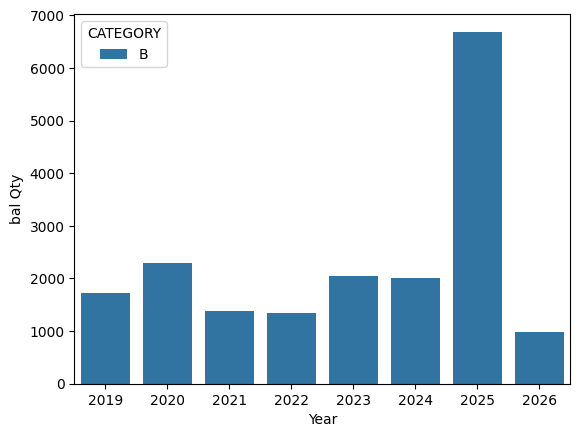

In [14]:
# تصفية البيانات
sectio_df = combined_df[combined_df['Section'] == '4051']

# عمل pivot table مع الـ CATEGORY
pivot_df = pd.pivot_table(
    sectio_df,
    index=['Section', 'CATEGORY'],  # خلي الـ index يشمل الـ Section و الـ CATEGORY
    columns='Year',
    values='bal Qty',
    aggfunc='sum'
).reset_index()

# تحويل pivot table إلى صيغة طويلة مع الـ CATEGORY
long_df = pivot_df.melt(id_vars=['Section', 'CATEGORY'], var_name='Year', value_name='bal Qty')

# رسم البيانات باستخدام seaborn
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=long_df, x='Year', y='bal Qty', hue='CATEGORY')
plt.show()

In [15]:
long_df

,Section,CATEGORY,Year,bal Qty
0,4051,B,2019,1731.390015
1,4051,B,2020,2292.300049
2,4051,B,2021,1376.050049
3,4051,B,2022,1352.800049
4,4051,B,2023,2049.100098
5,4051,B,2024,2010.949951
6,4051,B,2025,6687.850098
7,4051,B,2026,989.650024


In [17]:



# Group by outlets_type
type_sales = combined_df.groupby('outlets_type').agg({
    'bal Value': 'sum',
    'bal Qty': 'sum',
    'SKU': 'nunique'
})

print(type_sales)

                 bal Value       bal Qty    SKU
outlets_type                                   
B2B           1.021957e+09  3.537047e+07  55704
B2C           4.101874e+08  1.057757e+07  58024
Murex         1.670764e+06  3.483661e+04   2265
Projects      8.605250e+03  2.455000e+02     10


In [2]:
import pandas as pd


combined_df = pd.read_parquet(r'C:\Users\User\PycharmProjects\JupyterProject\MD\Output\combined_df.parquet')
#adjusted_combined_df = pd.read_parquet(r'C:\Users\User\PycharmProjects\JupyterProject\MD\Output\adjusted_combined_df.parquet')

In [5]:
combined_df.columns

Index(['Section', 'Section Name', 'bal Value', 'bal Qty', 'U Price', 'Client',
       'Client Name', 'Outlet', 'Outlet Name', 'Date', 'درجة أهمية العميل ',
       'SKU', 'Catalog No.', 'CURRENT_STOCK', 'OUTSTANDING', 'PR',
       'EFFECTIVE_STOCK', 'CATEGORY', 'Supplier', 'LAST_ENTRY_DATE',
       'Nb. Days (Avail. Balance)', 'SKU-STATUES-Mahmoud',
       'SKU STATUES -Python', 'OLD_QTY', 'First_Inv_Year', 'Year', 'Cost',
       'Unit_Price', 'Total_Cost', 'Total_Profit', 'Profit_Margin_%',
       'Sales_Type'],
      dtype='object')

In [7]:
combined_df[combined_df['SKU'] == "5217010013"].to_excel('5217010013.xlsx')

In [15]:
combined_df=pd.read_csv(r'C:\Users\User\PycharmProjects\JupyterProject\MD\Output\combined_df.csv')
combined_df.head()

C:\Users\User\AppData\Local\Temp\ipykernel_12936\1448611297.py:1: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  combined_df=pd.read_csv(r'C:\Users\User\PycharmProjects\JupyterProject\MD\Output\combined_df.csv')


,Section,Section Name,bal Value,bal Qty,U Price,Client,Client Name,Outlet,Outlet Name,Date,...,OUTSTANDING,PR,EFFECTIVE_STOCK,OLD_QTY,CATEGORY,Supplier,Unit_Price,Total_Cost,Total_Profit,Profit_Margin_%
0,3813,جاكار امبيوريو,513.510,51.3,10.01,4.600000e+09,عائله,46.0,صالة اليمن للتخفيضات,2019-01-01,...,0.0,0.0,54.82,1040.89,C,"J.W.L. MAINWAY CO., LTD",10.009942,1590.299976,-1076.789967,-209.692108
1,N116,,443.740,32.0,13.87,4.400002e+09,زكي,44.0,النجمة جدة,2019-01-01,...,NaN,NaN,NaN,NaN,NaN,NaN,13.866875,NaN,NaN,NaN
2,3884,أورقانزا تايتان,316.800,12.0,26.40,2.300000e+09,عـــائـــلــة,23.0,صالة العليا,2019-01-01,...,0.0,0.0,47.80,814.54,C,D'DECOR EXPORTS PVT. LTD.,26.400000,300.000000,16.799988,5.303027
3,4883,قطن استر بلس,112.060,4.5,24.90,4.000000e+08,مؤسسة لؤي نايل بوقري للتشغيل والصيانة,4.0,مركز مكة,2019-01-01,...,0.0,0.0,27.40,210.35,C,"ZHEJIANG FAMOUS TEXTILE CO., LTD.",24.902222,NaN,NaN,NaN
4,4410,دانتيل بامبو,-133.488,-3.0,44.50,7.600000e+09,شادن ستائر ومفروشات,76.0,مركز قطر,2019-01-01,...,0.0,0.0,0.00,2390.75,B,AYMES IC VE DIS TIC.PAZ.LTD.STI,44.496002,NaN,NaN,NaN


In [21]:

df_wrong=combined_df[combined_df['SKU'] == '4139010011']
df_wrong.to_excel('wrong.xlsx')


In [13]:
# # خلية منفصلة للـ adjusted فقط (لو عايز تعملها تاني)
# adjusted_combined_df = combined_df.copy()
#
# if 'adjusted_cost' in enrichments and enrichments['adjusted_cost'] is not None:
#     adjusted_combined_df = adjusted_combined_df.merge(
#         enrichments['adjusted_cost'],
#         on='SKU',
#         how='outer'
#     )
#
#     adjusted_combined_df['Final_Cost'] = adjusted_combined_df['Adjusted_Cost'].fillna(
#         adjusted_combined_df.get('Cost', np.nan)
#     )
#
#     # الحسابات الجديدة
#     adjusted_combined_df['Total_Cost'] = adjusted_combined_df['Final_Cost'] * adjusted_combined_df['bal Qty']
#     adjusted_combined_df['Total_Profit'] = adjusted_combined_df['bal Value'] - adjusted_combined_df['Total_Cost']
#     adjusted_combined_df['Profit_Margin_%'] = (
#         adjusted_combined_df['Total_Profit'] / adjusted_combined_df['bal Value'].replace(0, np.nan)
#     ) * 100
#
#     adjusted_combined_df.to_csv(
#         OUTPUT_DIR / "adjusted_combined_optimized.csv",
#         index=False, encoding='utf-8-sig'
#     )
#     print("تم حفظ النسخة المعدلة بنجاح")

# else:
#     print("مفيش بيانات Adjusted Cost متاحة")

## FUNTION TO LOAD THE DATA

In [3]:
# csv_folder = r"C:\Users\User\PycharmProjects\JupyterProject\MD"
# cost_file = r"C:\Users\User\PycharmProjects\JupyterProject\MD\SKUS COST.xlsx"
# stock_file = r"C:\Users\User\PycharmProjects\JupyterProject\MD\current_stock.xlsx"
# entry_date_file = r"C:\Users\User\PycharmProjects\JupyterProject\MD\ENTRY_DATES.xlsx"
# category_file = r"C:\Users\User\PycharmProjects\JupyterProject\MD\SKU_CATEGORIES.xlsx"
# supplier_file = r"C:\Users\User\PycharmProjects\JupyterProject\MD\SUPPLIER_CODE.xlsx"
# first_inv_date_file = r"C:\Users\User\PycharmProjects\JupyterProject\MD\First Inv.date.xlsx"  # NEW!
#
# output_file = "combined_output_PRO_CLEAN_FINAL.csv"
#
# combined_df = combine_csv_with_enrichment(
#     csv_folder,
#     output_file,
#     cost_file,
#     stock_file,
#     entry_date_file,
#     category_file,
#     supplier_file,
#     first_inv_date_file,  # NEW PARAMETER!
#     contract_threshold=100
# )
#
# if combined_df is not None:
#     print(f"\n✅ Ready: {len(combined_df):,} records")
#     print(f"📅 Period: {combined_df['Date'].min()} → {combined_df['Date'].max()}")
#     %store combined_df


🚀 STARTING FULL COMBINATION PIPELINE

💰 Loading COST data...
✅ Loaded 78,488 cost records
📋 Columns: ['Collection ', 'SKU', ' Cost  ']

📦 Loading STOCK data...
✅ Loaded 78,635 records
📋 Columns: ['Collection Name ', 'SKU', 'STOCK', 'OUTSTANDING', 'PR QTY']
📋 Mapped columns: {'Collection Name ': 'COLLECTION', 'SKU': 'SKU', 'STOCK': 'CURRENT_STOCK', 'OUTSTANDING': 'OUTSTANDING', 'PR QTY': 'PR'}
✅ CURRENT_STOCK: 17,769,284 total units
✅ OUTSTANDING: 2,654,943 total units
✅ PR: 133,250 total units

📊 STOCK SUMMARY:
   Current Stock:         17,769,284
   Outstanding:            2,654,943
   PR (Requisition):         133,250
   ─────────────────────────────────────
   EFFECTIVE STOCK:       20,530,232

📅 Loading LAST ENTRY DATE data...
✅ Loaded 78,635 records

🗂️ Loading SKU CATEGORY data...
✅ Loaded 78,581 records

🏭 Loading SUPPLIER CODE data...
✅ Loaded 78,452 records
📋 Columns: ['SKU', 'Supplier']

📆 Loading FIRST INVOICE DATE data...
✅ Loaded 2,544 records
📋 Columns: ['Section', 'Year

100%|███████████████████████████████████████████████████████████████| 57/57 [00:34<00:00,  1.67it/s]


✅ Merged COST data
✅ Merged STOCK data (includes EFFECTIVE_STOCK)
✅ Merged ENTRY DATE data
✅ Merged CATEGORY data
✅ Merged SUPPLIER data
✅ Merged FIRST INVOICE DATE data
   📊 4,435,511 / 4,930,461 records matched (90.0%)

🏢 Detecting sales types (threshold: 100)...
✅ CONTRACT: 38,132 records | Value: 203,827,778
✅ FAMILY  : 4,892,329 records | Value: 1,338,433,850

✅ FINAL FILE SAVED: 4,930,461 records → combined_output_PRO_CLEAN_FINAL.csv

📋 FINAL COLUMNS (47):
   Core: Section, bal Value, bal Qty, Client, Date, SKU
   Stock: U Price, Price Cat, CURRENT_STOCK, OUTSTANDING, PR, EFFECTIVE_STOCK, Unit_Price, Total_Profit, Profit_Margin_%
   Enrichment: Cost, COLLECTION, LAST_ENTRY_DATE, CATEGORY, Supplier, First_Inv_Year
   Calculated: Unit_Price, Total_Cost, Total_Profit, Profit_Margin_%, Sales_Type

✅ Ready: 4,930,461 records
📅 Period: 2019-01-01 00:00:00 → 2026-01-14 00:00:00
Stored 'combined_df' (DataFrame)


In [23]:
# ============================================================================
# CELL 1: SAVE VARIABLES (ضعها في نهاية Notebook)
# ============================================================================

import pickle
from pathlib import Path
from datetime import datetime

print("=" * 80)
print("💾 SAVING NOTEBOOK VARIABLES")
print("=" * 80)

# ═══════════════════════════════════════════════════════════════════════════
# 📋 STEP 1: List variables to save (Edit this list as needed)
# ═══════════════════════════════════════════════════════════════════════════

variables_to_save = [
    # Core DataFrames
    'combined_df', #the main dataframe
    'combined_df_updated', # updated dataframe for pattern dashboard
    'df',

    # Analysis Results
    'results_df', # for skus classification
    'classification_df',
    'forecasts_df',
    'inventory_df',
    'results_df_classi_collection',
    'sku_df',
    'section_df',#dataframe for collection classification

    # Dashboard Objects
    'dashboard',

    # Pattern Analysis
    'pattern_stats',
    'sku_level',
    'color_analysis',

    # Configs & Dicts
    'config',
    'metrics',

    # Add any other variables here
]

# ═══════════════════════════════════════════════════════════════════════════
# 📁 STEP 2: Create save folder
# ═══════════════════════════════════════════════════════════════════════════

save_folder = Path.home() / "Desktop" / "notebook_variables"
save_folder.mkdir(exist_ok=True)

# Create timestamped subfolder
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
session_folder = save_folder / f"session_{timestamp}"
session_folder.mkdir(exist_ok=True)

print(f"\n📂 Save location: {session_folder}")
print()

# ═══════════════════════════════════════════════════════════════════════════
# 💾 STEP 3: Save each variable
# ═══════════════════════════════════════════════════════════════════════════

saved_vars = {}
success_count = 0
skip_count = 0
fail_count = 0

for var_name in variables_to_save:
    if var_name in globals():
        try:
            var_value = globals()[var_name]

            # Save to pickle
            file_path = session_folder / f"{var_name}.pkl"
            with open(file_path, 'wb') as f:
                pickle.dump(var_value, f)

            # Get file size
            size_kb = file_path.stat().st_size / 1024
            size_str = f"{size_kb:.1f} KB" if size_kb < 1024 else f"{size_kb/1024:.1f} MB"

            saved_vars[var_name] = {
                'saved': True,
                'type': type(var_value).__name__,
                'size': size_str
            }

            print(f"✅ {var_name:<25} | {saved_vars[var_name]['type']:<15} | {size_str}")
            success_count += 1

        except Exception as e:
            saved_vars[var_name] = {'saved': False, 'error': str(e)}
            print(f"❌ {var_name:<25} | FAILED: {str(e)[:40]}")
            fail_count += 1
    else:
        print(f"⚠️  {var_name:<25} | NOT FOUND (skipped)")
        skip_count += 1

# ═══════════════════════════════════════════════════════════════════════════
# 📝 STEP 4: Save metadata
# ═══════════════════════════════════════════════════════════════════════════

metadata = {
    'timestamp': timestamp,
    'datetime': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'saved_variables': saved_vars,
    'notebook_name': 'Current Notebook',  # You can customize this
    'success_count': success_count,
    'skip_count': skip_count,
    'fail_count': fail_count
}

metadata_path = session_folder / "metadata.pkl"
with open(metadata_path, 'wb') as f:
    pickle.dump(metadata, f)

# ═══════════════════════════════════════════════════════════════════════════
# ✅ STEP 5: Summary
# ═══════════════════════════════════════════════════════════════════════════

print()
print("=" * 80)
print("✅ SAVE COMPLETE!")
print("=" * 80)
print(f"📂 Location: {session_folder}")
print(f"✅ Saved:    {success_count} variables")
print(f"⚠️  Skipped:  {skip_count} variables (not found)")
print(f"❌ Failed:   {fail_count} variables")
print("=" * 80)
print()
print("💡 To load these variables in another notebook, use CELL 2")
print("=" * 80)

💾 SAVING NOTEBOOK VARIABLES

📂 Save location: C:\Users\User\Desktop\notebook_variables\session_20260119_123201

✅ combined_df               | DataFrame       | 762.1 MB
✅ combined_df_updated       | DataFrame       | 1592.6 MB
✅ df                        | DataFrame       | 1454.8 MB
⚠️  results_df                | NOT FOUND (skipped)
⚠️  classification_df         | NOT FOUND (skipped)
⚠️  forecasts_df              | NOT FOUND (skipped)
✅ inventory_df              | DataFrame       | 17.6 MB
⚠️  results_df_classi_collection | NOT FOUND (skipped)
✅ sku_df                    | DataFrame       | 15.0 MB
✅ section_df                | DataFrame       | 855.7 KB
⚠️  dashboard                 | NOT FOUND (skipped)
⚠️  pattern_stats             | NOT FOUND (skipped)
⚠️  sku_level                 | NOT FOUND (skipped)
⚠️  color_analysis            | NOT FOUND (skipped)
⚠️  config                    | NOT FOUND (skipped)
⚠️  metrics                   | NOT FOUND (skipped)

✅ SAVE COMPLETE!
📂 Loc

In [13]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4937301 entries, 0 to 4937300
Data columns (total 28 columns):
 #   Column               Dtype         
---  ------               -----         
 0   Section              object        
 1   bal Value            float32       
 2   bal Qty              float32       
 3   U Price              float32       
 4   Client               object        
 5   Client Name          object        
 6   Date                 datetime64[ns]
 7   درجة أهمية العميل    object        
 8   SKU                  object        
 9   Catalog No.          object        
 10  Source_File          object        
 11  Cost                 float32       
 12  CURRENT_STOCK        float64       
 13  OUTSTANDING          float64       
 14  PR                   float64       
 15  EFFECTIVE_STOCK      float64       
 16  COLLECTION           object        
 17  CATEGORY             object        
 18  Supplier             object        
 19  LAST_ENTRY_DATE      

## Data information & Distribution

Shape after cleaning: (4494804, 3)
Analyzing SKU: 4424010013


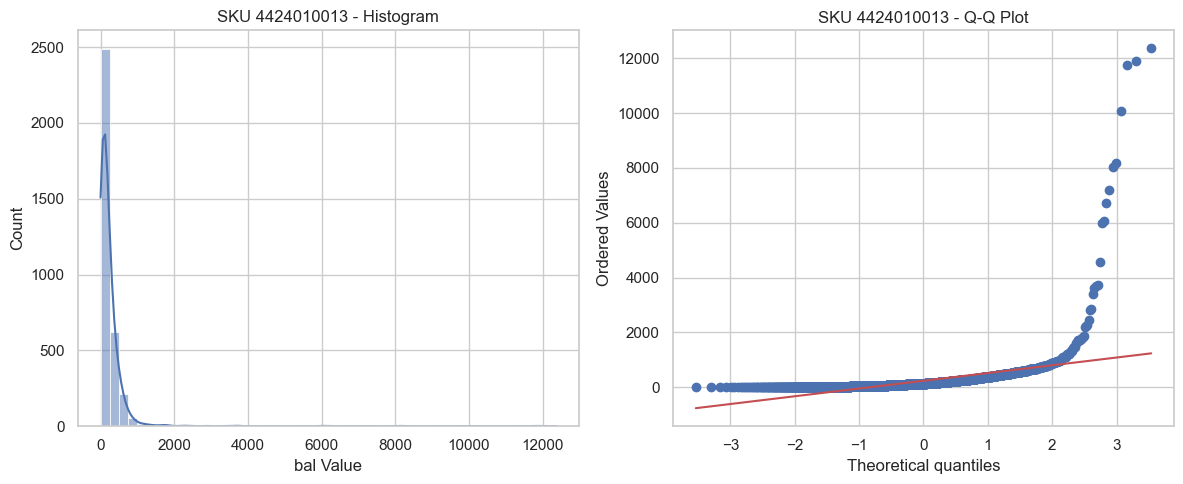

Shapiro-Wilk → stat=0.2616, p-value=2.0469e-79

Best fitting distributions:
lognorm: p-value = 5.3979e-07
expon: p-value = 3.1272e-21
norm: p-value = 0.0000e+00


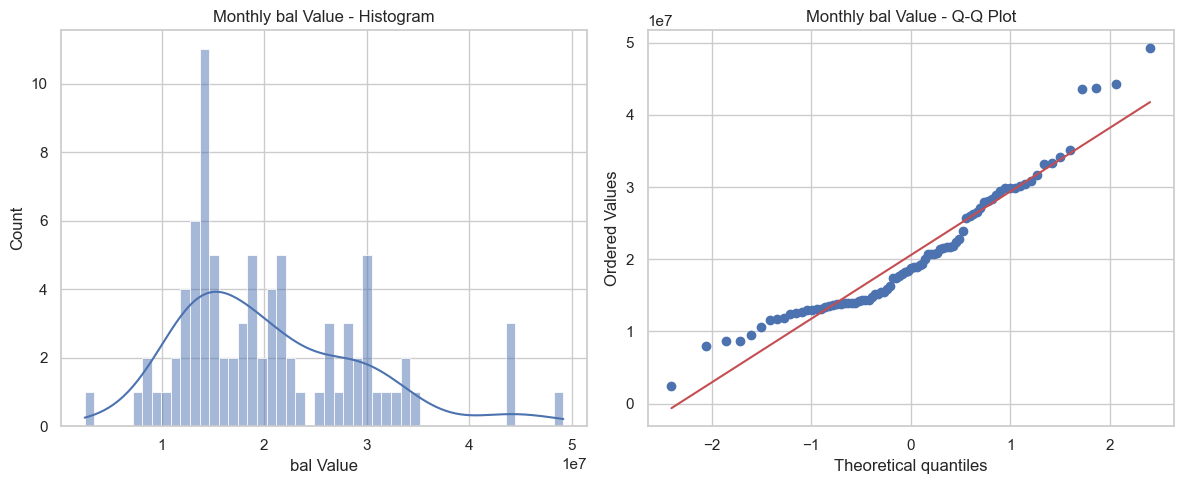

Shapiro-Wilk → stat=0.9285, p-value=1.5554e-04

Best fitting distributions:
lognorm: p-value = 4.7091e-01
norm: p-value = 1.8621e-01
expon: p-value = 1.5888e-08


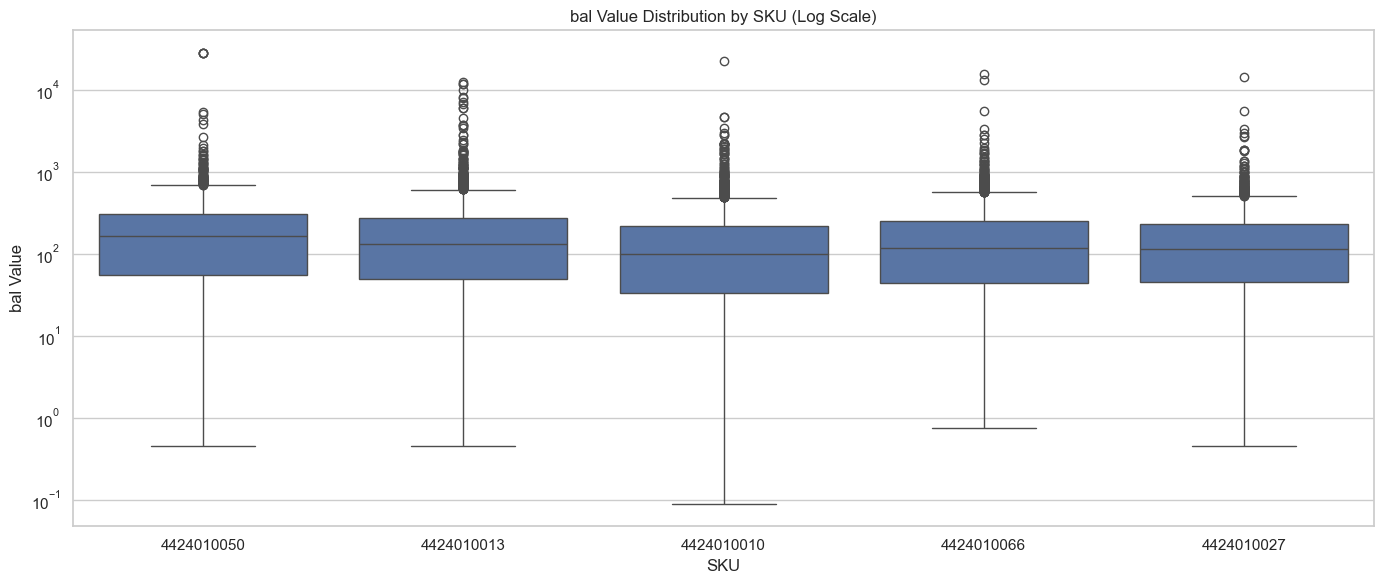

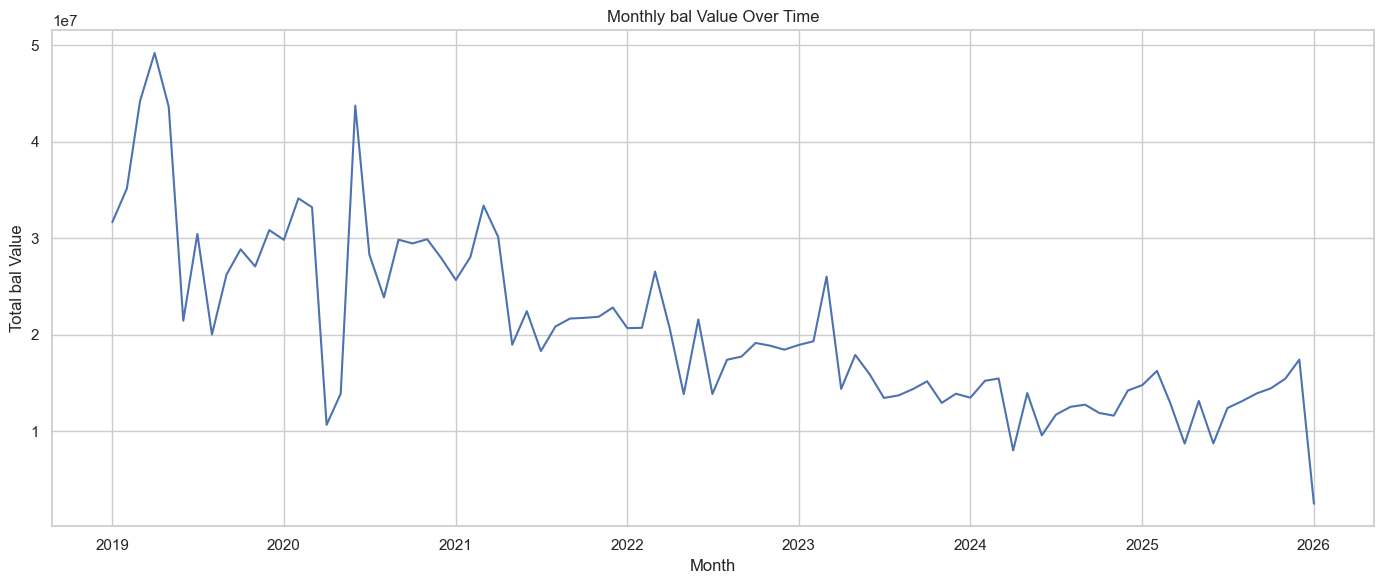

In [8]:
# =====================================
# Imports
# =====================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

sns.set(style="whitegrid")

# =====================================
# اختيار وتنظيف الداتا
# =====================================
df = combined_df[['SKU', 'bal Value', 'Date']].copy()

df = df.dropna(subset=['SKU', 'bal Value', 'Date'])

df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['bal Value'] = pd.to_numeric(df['bal Value'], errors='coerce')

# نشيل القيم غير المنطقية
df = df[df['bal Value'] > 0]

print("Shape after cleaning:", df.shape)

# =====================================
# دالة فحص التوزيع الإحصائي
# =====================================
def check_distribution(series, title="", sample_size=5000):
    series = series.dropna()

    # Sampling عشان الاختبارات الإحصائية
    if len(series) > sample_size:
        series = series.sample(sample_size, random_state=42)

    plt.figure(figsize=(12, 5))

    # Histogram + KDE
    plt.subplot(1, 2, 1)
    sns.histplot(series, bins=50, kde=True)
    plt.title(f'{title} - Histogram')

    # Q-Q Plot
    plt.subplot(1, 2, 2)
    stats.probplot(series, dist="norm", plot=plt)
    plt.title(f'{title} - Q-Q Plot')

    plt.tight_layout()
    plt.show()

    # Shapiro-Wilk
    stat, p = stats.shapiro(series)
    print(f"Shapiro-Wilk → stat={stat:.4f}, p-value={p:.4e}")

    # مقارنة توزيعات
    dist_names = ['norm', 'lognorm', 'expon']
    results = []

    for name in dist_names:
        dist = getattr(stats, name)
        params = dist.fit(series)
        _, p_val = stats.kstest(series, name, args=params)
        results.append((name, p_val))

    results.sort(key=lambda x: x[1], reverse=True)

    print("\nBest fitting distributions:")
    for d, p_val in results:
        print(f"{d}: p-value = {p_val:.4e}")

# =====================================
# 1️⃣ توزيع bal Value لمنتج (SKU) واحد
# =====================================
top_sku = df['SKU'].value_counts().idxmax()
print("Analyzing SKU:", top_sku)

sku_series = df[df['SKU'] == top_sku]['bal Value']
check_distribution(sku_series, title=f'SKU {top_sku}')

# =====================================
# 2️⃣ توزيع bal Value عبر الزمن (شهري)
# =====================================
df['Month'] = df['Date'].dt.to_period('M')

monthly_bal = (
    df.groupby('Month')['bal Value']
      .sum()
      .reset_index()
)

# تحويل Period → datetime (حل الخطأ)
monthly_bal['Month'] = monthly_bal['Month'].dt.to_timestamp()

check_distribution(monthly_bal['bal Value'], title='Monthly bal Value')

# =====================================
# 3️⃣ مقارنة التوزيع بين أعلى 5 SKUs
# =====================================
top_skus = df['SKU'].value_counts().head(5).index
subset = df[df['SKU'].isin(top_skus)]

plt.figure(figsize=(14, 6))
sns.boxplot(data=subset, x='SKU', y='bal Value')
plt.yscale('log')
plt.title('bal Value Distribution by SKU (Log Scale)')
plt.tight_layout()
plt.show()

# =====================================
# 4️⃣ الرسم الزمني (بدون خطأ)
# =====================================
plt.figure(figsize=(14, 6))
plt.plot(monthly_bal['Month'], monthly_bal['bal Value'])
plt.title('Monthly bal Value Over Time')
plt.ylabel('Total bal Value')
plt.xlabel('Month')
plt.tight_layout()
plt.show()


### This notebook is designed for only combining data if any addition files needed please edit this notebook only

In [26]:
combined_df.head()
unique_suppliers = combined_df['Supplier'].unique()
print(unique_suppliers)

['J.W.L. MAINWAY CO., LTD' None "D'DECOR EXPORTS PVT. LTD."
 'ZHEJIANG FAMOUS TEXTILE CO., LTD.' 'AYMES IC VE DIS TIC.PAZ.LTD.STI'
 'SHAOXING KEQIAO KANGWO TEXTILE CO., LTD' 'G.M.FABRICS PVT.LTD'
 'DICITEX FURNISHING PVT .LTD' 'IDEALL SOLUTIONZ SINGAPORE PTE LTD'
 'ZHEJIANG NEW-MINGRONG TRICOT CO., LTD.' "D'DECOR HOME FABRICS PVT.LTD"
 'HARPUT TEKSTIL SANAYI VE TICARET A.S.' 'G.M. SYNTEX PVT.LTD'
 'HANGZHOU MAIPU TEXTILE CO.LTD' 'Ekart Tekstil Sanayi ve Ticaret A.S.'
 'HANGZHOU FULONG FABRICS CO.,LTD' 'HANGZHOU AICO HOME TEXTILE CO., LTD'
 '(BRILLANT) EYMES TEKSTIL SAN. TIC. A.S.' 'VISTA FURNISHING LIMITED'
 'HAINING LONG FEI FENG WU EMBRODRY CO LTD'
 'HANGZHOU E-WAY INTERNATIONAL TRADE CO.' 'HANGZHOU RICKY FABRICS INC.'
 'HANGZHOU XINFANG FABRIC CO.,LTD' 'GULESER TEKSTIL A.S.'
 'Tekstop Tekstil Sanayi ve Ticaret A.S.' 'TEKSKO TEKSTIL'
 'PRESTIGE DIS TICARET LTD.' 'ELVIN TEKSTIL'
 'SUTLEJ TEXTILES AND INDUSTIES LTD(BIRLA)'
 'ESPIOLE- NURSULTAN INSAAT TUR.TEKS.LTD'
 'NEPTUNE HOUSE FURNI

In [4]:
combined_df.head()

,Section,Section Name,bal Value,bal Qty,U Price,Client,Client Name,Outlet,Outlet Name,Date,...,Nb. Days (Avail. Balance),SKU-STATUES-Mahmoud,SKU STATUES -Python,OLD_QTY,First_Inv_Year,Unit_Price,Total_Cost,Total_Profit,Profit_Margin_%,Sales_Type
0,3813,جاكار امبيوريو,513.510010,51.299999,10.01,4.600000e+09,عائله,46.0,صالة اليمن للتخفيضات,2019-01-01,...,120.0,clearance,Loss,1040.890015,2013.0,10.009942,923.399963,-409.889954,-79.821220,FAMILY
1,N116,,443.739990,32.000000,13.87,4.400002e+09,زكي,44.0,النجمة جدة,2019-01-01,...,NaN,None,None,NaN,NaN,13.866875,NaN,NaN,NaN,FAMILY
2,3884,أورقانزا تايتان,316.799988,12.000000,26.40,2.300000e+09,عـــائـــلــة,23.0,صالة العليا,2019-01-01,...,120.0,clearance,Sporadic (Inactive),814.539978,2013.0,26.400000,180.000000,136.799988,43.181816,FAMILY
3,4883,قطن استر بلس,112.059998,4.500000,24.90,4.000000e+08,مؤسسة لؤي نايل بوقري للتشغيل والصيانة,4.0,مركز مكة,2019-01-01,...,120.0,activation,Dead (Stock Available),210.350006,2018.0,24.902222,54.000000,58.059998,51.811527,FAMILY
4,4410,دانتيل بامبو,-133.488007,-3.000000,44.50,7.600000e+09,شادن ستائر ومفروشات,76.0,مركز قطر,2019-01-01,...,120.0,activation,Stock-Out (Was Profitable),2390.750000,2016.0,44.496002,-24.000000,-109.488007,82.020859,FAMILY


In [5]:
combined_df.columns


Index(['Section', 'Section Name', 'bal Value', 'bal Qty', 'U Price', 'Client',
       'Client Name', 'Outlet', 'Outlet Name', 'Date', 'درجة أهمية العميل ',
       'SKU', 'Catalog No.', 'Cost', 'CURRENT_STOCK', 'OUTSTANDING', 'PR',
       'EFFECTIVE_STOCK', 'CATEGORY', 'Supplier', 'LAST_ENTRY_DATE',
       'Nb. Days (Avail. Balance)', 'SKU-STATUES-Mahmoud',
       'SKU STATUES -Python', 'OLD_QTY', 'First_Inv_Year', 'Unit_Price',
       'Total_Cost', 'Total_Profit', 'Profit_Margin_%', 'Sales_Type'],
      dtype='object')

In [3]:
import pandas as pd
import numpy as np
from pathlib import Path
import glob
import gc

# ═════════════════════════════════════════════
# CONFIG
# ═════════════════════════════════════════════

BASE_DIR = Path(r"C:\Users\User\PycharmProjects\JupyterProject\MD")
SALES_DATA_DIR = BASE_DIR / "Sales_data"

FILTER_WORDS = ['جزيرة', 'مصنع الكتلوجات', 'نجمة', 'الادارة العامة التسويق', 'الشامل']

# ═════════════════════════════════════════════
# CSV COMBINER (RAW DATA)
# ═════════════════════════════════════════════

def load_raw_sales_csv(folder_path, filter_words):

    csv_files = glob.glob(str(folder_path / "*.csv"))
    if not csv_files:
        raise FileNotFoundError("No CSV files found")

    print(f"📂 Found {len(csv_files)} CSV files")

    dtype_spec = {
        'bal Value': 'float32',
        'bal Qty': 'float32',
        'U Price': 'float32',
        'Client': 'float32',
        'Outlet': 'float32',
        'Section': 'str',
        'SKU': 'str',
        'Outlet Name': 'str'
    }

    dfs = []
    total_before = 0
    total_after = 0

    for file in csv_files:
        df = pd.read_csv(
            file,
            encoding='windows-1256',
            dtype=dtype_spec,
            parse_dates=['Date'],
            dayfirst=True,
            low_memory=False
        )

        total_before += len(df)

        # ❌ Exclude unwanted outlet names
        if 'Outlet Name' in df.columns:
            mask = pd.Series(False, index=df.index)
            for word in filter_words:
                mask |= df['Outlet Name'].str.contains(word, case=False, na=False)
            df = df[~mask]

        # Clean SKU
        df['SKU'] = df['SKU'].str.strip().str.replace(r'\.0+$', '', regex=True)

        # Extract year
        df['Year'] = df['Date'].dt.year

        total_after += len(df)
        dfs.append(df)

        if len(dfs) >= 5:
            dfs = [pd.concat(dfs, ignore_index=True)]
            gc.collect()

    COMBINED_DF_202222 = pd.concat(dfs, ignore_index=True)
    COMBINED_DF_202222 = COMBINED_DF_202222.sort_values('Date').reset_index(drop=True)

    print(f"✅ RAW DATA READY")
    print(f"   Records before filter: {total_before:,}")
    print(f"   Records after filter : {total_after:,}")
    print(f"   Unique Clients       : {COMBINED_DF_202222['Client'].nunique():,}")
    print(f"   Period               : {COMBINED_DF_202222['Date'].min().date()} → {COMBINED_DF_202222['Date'].max().date()}")

    return COMBINED_DF_202222


# ═════════════════════════════════════════════
# EXECUTION
# ═════════════════════════════════════════════

COMBINED_DF_202222 = load_raw_sales_csv(SALES_DATA_DIR, FILTER_WORDS)


📂 Found 57 CSV files
✅ RAW DATA READY
   Records before filter: 4,958,966
   Records after filter : 4,439,953
   Unique Clients       : 565
   Period               : 2019-01-01 → 2026-02-02


In [ ]:
print(COMBINED_DF_202222['Client'].nunique())

In [8]:
import pandas as pd
import numpy as np
from pathlib import Path
import glob
import gc

# ═════════════════════════════════════════════
# CONFIG
# ═════════════════════════════════════════════

BASE_DIR = Path(r"C:\Users\User\PycharmProjects\JupyterProject\MD")
SALES_DATA_DIR = BASE_DIR / "Sales_data"

FILTER_WORDS = ['محمودددددد']

# ═════════════════════════════════════════════
# CSV COMBINER (RAW DATA)
# ═════════════════════════════════════════════

def load_raw_sales_csv(folder_path, filter_words):

    csv_files = glob.glob(str(folder_path / "*.csv"))
    if not csv_files:
        raise FileNotFoundError("No CSV files found")

    print(f"📂 Found {len(csv_files)} CSV files")

    dtype_spec = {
        'bal Value': 'float32',
        'bal Qty': 'float32',
        'U Price': 'float32',
        'Client': 'string',
        'Outlet': 'float32',
        'Section': 'str',
        'SKU': 'str',
        'Outlet Name': 'str'
    }

    dfs = []
    total_before = 0
    total_after = 0

    for file in csv_files:
        df = pd.read_csv(
            file,
            encoding='windows-1256',
            dtype=dtype_spec,
            parse_dates=['Date'],
            dayfirst=True,
            low_memory=False
        )

        total_before += len(df)

        # ❌ Exclude unwanted outlet names
        if 'Outlet Name' in df.columns:
            mask = pd.Series(False, index=df.index)
            for word in filter_words:
                mask |= df['Outlet Name'].str.contains(word, case=False, na=False)
            df = df[~mask]

        # Clean SKU
        df['SKU'] = df['SKU'].str.strip().str.replace(r'\.0+$', '', regex=True)

        # Extract year
        df['Year'] = df['Date'].dt.year

        total_after += len(df)
        dfs.append(df)

        if len(dfs) >= 5:
            dfs = [pd.concat(dfs, ignore_index=True)]
            gc.collect()

    COMBINED_DF_202222 = pd.concat(dfs, ignore_index=True)
    COMBINED_DF_202222 = COMBINED_DF_202222.sort_values('Date').reset_index(drop=True)

    print(f"✅ RAW DATA READY")
    print(f"   Records before filter: {total_before:,}")
    print(f"   Records after filter : {total_after:,}")
    print(f"   Unique Clients       : {COMBINED_DF_202222['Client'].nunique():,}")
    print(f"   Period               : {COMBINED_DF_202222['Date'].min().date()} → {COMBINED_DF_202222['Date'].max().date()}")

    return COMBINED_DF_202222


# ═════════════════════════════════════════════
# EXECUTION
# ═════════════════════════════════════════════

COMBINED_DF_202222 = load_raw_sales_csv(SALES_DATA_DIR, FILTER_WORDS)


📂 Found 57 CSV files
✅ RAW DATA READY
   Records before filter: 4,958,966
   Records after filter : 4,958,966
   Unique Clients       : 51,173
   Period               : 2019-01-01 → 2026-02-02


In [6]:
COMBINED_DF_202222['Client'].head(20
                                  )

0     4.400000e+09
1     8.400000e+09
2     9.099020e+08
3     2.200000e+09
4     6.200002e+09
5     6.200001e+09
6     4.600000e+09
7     2.900001e+09
8     6.100000e+09
9     4.600000e+09
10    6.200003e+09
11    6.100000e+09
12    6.400000e+09
13    9.909902e+08
14    9.000001e+08
15    4.400000e+09
16    2.900000e+09
17    2.900002e+09
18    4.410400e+08
19    6.200002e+09
Name: Client, dtype: float32

In [7]:
COMBINED_DF_202222['Client'].astype('int64').nunique()


IntCastingNaNError: Cannot convert non-finite values (NA or inf) to integer

In [1]:
# ════════════════════════════════════════════════════════════════════════════
# ULTRA-OPTIMIZED DATA LOADING - WITH YEARLY COSTS + FULL OUTLETS MERGE
# ✅ Smart cost detection per year
# ✅ Yearly profit calculation
# ✅ Average profit across years
# ✅ Outlet filtering
# ✅ FULL OUTLETS MERGE: All 4 columns (Outlet_Names, Outlets, area_master_category, country)
# ✅ Extreme memory efficiency
# ════════════════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
import glob
import gc
import re
warnings.filterwarnings('ignore')

# ════════════════════════════════════════════════════════════════
# CONFIGURATION
# ════════════════════════════════════════════════════════════════
BASE_DIR = Path(r"C:\Users\User\PycharmProjects\JupyterProject\MD")
SALES_DATA_DIR = BASE_DIR / "Sales_data"
HELPING_FILES_DIR = BASE_DIR / "Helping_Files"
OUTPUT_DIR = BASE_DIR / "Output"
OUTPUT_DIR.mkdir(exist_ok=True)

FILES = {
    'yearly_costs': HELPING_FILES_DIR / "SKU_COST_SHEET.xlsx",
    'fallback_cost': HELPING_FILES_DIR / "SKUS_COST.xlsx",
    'stock': HELPING_FILES_DIR / "current_stock.xlsx",
    'entry_date': HELPING_FILES_DIR / "ENTRY_DATES.xlsx",
    'category': HELPING_FILES_DIR / "SKU_CATEGORIES.xlsx",
    'supplier': HELPING_FILES_DIR / "SUPPLIER_CODE.xlsx",
    'first_inv': HELPING_FILES_DIR / "First Inv.date.xlsx",
    'mahmoud_class': HELPING_FILES_DIR / "Mahmoud_SKU_Classification.xlsx",
    'nb_days': HELPING_FILES_DIR / "nb.xlsx",
    'historical_qty': HELPING_FILES_DIR / "Sales_Qty_1999_2018.xlsx",
    'artprint_texture': HELPING_FILES_DIR / "ARTPRINT_TEXTURE.xlsx",
    'outlets': HELPING_FILES_DIR / "Outlets.xlsx"
}

# Filter words for Outlet Name
FILTER_WORDS = ['جزيرة', 'مصنع الكتلوجات', 'نجمة', 'الادارة العامة التسويق', 'الشامل']

print("=" * 80)
print("🚀 ULTRA-OPTIMIZED DATA LOADING (YEARLY COSTS + FULL OUTLETS MERGE)")
print("=" * 80)

# ════════════════════════════════════════════════════════════════
# SMART COST DETECTOR
# ════════════════════════════════════════════════════════════════
def load_yearly_costs(path):
    """Smart detection of yearly cost columns"""
    if not path.exists():
        print(f"   ⚠️  Yearly costs file not found: {path}")
        return None, None

    try:
        df = pd.read_excel(path)

        # Find SKU column
        sku_cols = [c for c in df.columns if 'sku' in c.lower()]
        if not sku_cols:
            print("   ⚠️  No SKU column found in yearly costs")
            return None, None

        sku_col = sku_cols[0]
        df = df.rename(columns={sku_col: 'SKU'})
        df['SKU'] = df['SKU'].astype(str).str.strip().str.replace(r'\.0+$', '', regex=True)

        # Smart detection of cost columns with years
        cost_cols = {}
        year_pattern = re.compile(r'(19|20)\d{2}')

        for col in df.columns:
            if col == 'SKU':
                continue
            col_lower = col.lower()
            if any(keyword in col_lower for keyword in ['cost', 'price', 'unit']):
                year_match = year_pattern.search(col)
                if year_match:
                    year = int(year_match.group())
                    cost_cols[year] = col

        if not cost_cols:
            print("   ⚠️  No yearly cost columns detected")
            return None, None

        # Create final dataframe
        result_df = df[['SKU']].copy()
        for year in sorted(cost_cols.keys()):
            original_col = cost_cols[year]
            new_col = f'Cost_{year}'
            result_df[new_col] = df[original_col].astype('float32')

        print(f"   ✅ Yearly costs loaded: {len(result_df):,} SKUs")
        print(f"   📅 Years detected: {sorted(cost_cols.keys())}")

        return result_df, sorted(cost_cols.keys())

    except Exception as e:
        print(f"   ⚠️  Error loading yearly costs: {e}")
        return None, None

# ════════════════════════════════════════════════════════════════
# ULTRA-FAST CSV LOADER WITH OUTLET FILTERING
# ════════════════════════════════════════════════════════════════
def load_csv_ultra_fast(folder_path, filter_words):
    """Ultra-optimized CSV loader with outlet filtering"""
    csv_files = glob.glob(str(folder_path / "*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"No CSV files in {folder_path}")

    print(f"\n📂 Loading {len(csv_files)} CSV files...")

    # Optimal dtypes
    dtype_spec = {
        'bal Value': 'float32',
        'bal Qty': 'float32',
        'U Price': 'float32',
        'Client': 'string',
        'Outlet': 'float32',
        'Section': 'str',
        'SKU': 'str',
        'Outlet Name': 'str'
    }

    dfs = []
    total_before = 0
    total_after = 0

    for file in csv_files:
        print(f"   📄 {Path(file).name}...", end=' ')
        df = pd.read_csv(
            file,
            encoding='windows-1256',
            dtype=dtype_spec,
            parse_dates=['Date'],
            dayfirst=True,
            low_memory=False
        )

        total_before += len(df)

        # ✅ FILTER OUTLET NAMES
        if 'Outlet Name' in df.columns:
            filter_mask = pd.Series([False] * len(df), index=df.index)
            for word in filter_words:
                filter_mask |= df['Outlet Name'].str.contains(word, case=False, na=False, regex=False)

            # Keep only rows that DON'T match filter words
            df = df[~filter_mask].copy()
            filtered_count = total_before - len(df)
            if filtered_count > 0:
                print(f"filtered {filtered_count:,}, ", end='')

        # Clean SKU
        df['SKU'] = df['SKU'].str.strip().str.replace(r'\.0+$', '', regex=True)

        # Extract year for later cost matching
        df['Year'] = df['Date'].dt.year

        total_after += len(df)
        dfs.append(df)
        print(f"{len(df):,} rows")

        # Clean up every 5 files
        if len(dfs) >= 5:
            temp = pd.concat(dfs, ignore_index=True)
            dfs = [temp]
            gc.collect()

    # Final concat
    print("\n   🔗 Combining all files...")
    combined = pd.concat(dfs, ignore_index=True)
    del dfs
    gc.collect()

    # Sort by date
    combined = combined.sort_values('Date', ignore_index=True)

    print(f"\n   ✅ Loaded: {total_after:,} records (filtered {total_before - total_after:,})")

    return combined

# ════════════════════════════════════════════════════════════════
# YEARLY PROFIT CALCULATOR
# ════════════════════════════════════════════════════════════════
def calculate_yearly_profits(df, yearly_costs_df, cost_years, fallback_cost_df):
    """Calculate profit for each year using year-specific costs"""
    print("\n" + "=" * 80)
    print("CALCULATING YEARLY PROFITS")
    print("=" * 80)

    # Create fallback cost dictionary
    fallback_dict = {}
    if fallback_cost_df is not None:
        fallback_dict = fallback_cost_df.set_index('SKU')['Cost'].to_dict()
        print(f"   ℹ️  Fallback costs available: {len(fallback_dict):,} SKUs")

    # Create yearly cost dictionaries for fast lookup
    yearly_cost_dicts = {}
    if yearly_costs_df is not None:
        for year in cost_years:
            col_name = f'Cost_{year}'
            if col_name in yearly_costs_df.columns:
                yearly_cost_dicts[year] = yearly_costs_df.set_index('SKU')[col_name].to_dict()
                print(f"   📅 {year}: {len(yearly_cost_dicts[year]):,} SKUs")

    # Get unique years in data
    data_years = sorted(df['Year'].unique())
    print(f"\n   📊 Sales years: {data_years[0]} - {data_years[-1]}")

    # Initialize columns
    profit_cols = []
    margin_cols = []

    for year in data_years:
        cost_col = f'Cost_{year}'
        profit_col = f'Profit_{year}'
        margin_col = f'Margin_%_{year}'

        # Initialize with NaN
        df[cost_col] = np.nan
        df[profit_col] = np.nan
        df[margin_col] = np.nan

        profit_cols.append(profit_col)
        margin_cols.append(margin_col)

        # Filter rows for this year
        year_mask = df['Year'] == year
        year_count = year_mask.sum()

        if year_count == 0:
            continue

        print(f"\n   🔍 Processing year {year} ({year_count:,} records)...")

        # Get cost for this year (vectorized)
        if year in yearly_cost_dicts:
            # Map year-specific costs
            df.loc[year_mask, cost_col] = df.loc[year_mask, 'SKU'].map(yearly_cost_dicts[year])
            found_count = df.loc[year_mask, cost_col].notna().sum()
            print(f"      ✅ Found yearly costs: {found_count:,} records")

            # Fallback to general cost for missing
            missing_mask = year_mask & df[cost_col].isna()
            missing_count = missing_mask.sum()
            if missing_count > 0 and fallback_dict:
                df.loc[missing_mask, cost_col] = df.loc[missing_mask, 'SKU'].map(fallback_dict)
                fallback_found = df.loc[missing_mask, cost_col].notna().sum()
                print(f"      ⚠️  Used fallback: {fallback_found:,} / {missing_count:,}")
        else:
            # No yearly cost for this year, use fallback
            if fallback_dict:
                df.loc[year_mask, cost_col] = df.loc[year_mask, 'SKU'].map(fallback_dict)
                found_count = df.loc[year_mask, cost_col].notna().sum()
                print(f"      ⚠️  No yearly cost, used fallback: {found_count:,} / {year_count:,}")

        # Calculate profit and margin (vectorized)
        valid_cost_mask = year_mask & df[cost_col].notna()
        if valid_cost_mask.sum() > 0:
            df.loc[valid_cost_mask, profit_col] = (
                df.loc[valid_cost_mask, 'bal Value'] -
                (df.loc[valid_cost_mask, cost_col] * df.loc[valid_cost_mask, 'bal Qty'])
            ).astype('float32')

            df.loc[valid_cost_mask, margin_col] = (
                (df.loc[valid_cost_mask, profit_col] /
                 df.loc[valid_cost_mask, 'bal Value']) * 100
            ).astype('float32')

            avg_margin = df.loc[valid_cost_mask, margin_col].mean()
            print(f"      💰 Avg margin: {avg_margin:.1f}%")

    # ✅ CALCULATE AVERAGE PROFIT ACROSS YEARS
    print(f"\n   📊 Calculating average profit across years...")

    # Create mask for rows with at least one valid profit
    has_profit_mask = pd.Series([False] * len(df), index=df.index)
    for col in profit_cols:
        has_profit_mask |= df[col].notna()

    if has_profit_mask.sum() > 0:
        # Calculate mean profit (ignoring NaN)
        df['Avg_Profit'] = df[profit_cols].mean(axis=1, skipna=True).astype('float32')
        df['Avg_Margin_%'] = df[margin_cols].mean(axis=1, skipna=True).astype('float32')

        avg_profit_count = df['Avg_Profit'].notna().sum()
        overall_avg_margin = df['Avg_Margin_%'].mean()

        print(f"      ✅ Records with avg profit: {avg_profit_count:,}")
        print(f"      💰 Overall avg margin: {overall_avg_margin:.1f}%")
    else:
        df['Avg_Profit'] = np.nan
        df['Avg_Margin_%'] = np.nan
        print(f"      ⚠️  No profit data calculated")

    # ✅ CALCULATE TOTAL_PROFIT (General)
    print(f"\n   📊 Calculating Total_Profit (general column)...")

    # Get the most recent cost for each row
    df['Cost_Used'] = np.nan
    for year in data_years:
        cost_col = f'Cost_{year}'
        if cost_col in df.columns:
            year_mask = df['Year'] == year
            df.loc[year_mask & df[cost_col].notna(), 'Cost_Used'] = df.loc[year_mask & df[cost_col].notna(), cost_col]

    # Calculate Total_Profit using Cost_Used
    valid_cost = df['Cost_Used'].notna()
    if valid_cost.sum() > 0:
        df['Total_Cost'] = np.nan
        df['Total_Profit'] = np.nan
        df['Profit_Margin_%'] = np.nan

        df.loc[valid_cost, 'Total_Cost'] = (df.loc[valid_cost, 'Cost_Used'] * df.loc[valid_cost, 'bal Qty']).astype('float32')
        df.loc[valid_cost, 'Total_Profit'] = (df.loc[valid_cost, 'bal Value'] - df.loc[valid_cost, 'Total_Cost']).astype('float32')
        df.loc[valid_cost, 'Profit_Margin_%'] = ((df.loc[valid_cost, 'Total_Profit'] / df.loc[valid_cost, 'bal Value']) * 100).astype('float32')

        print(f"      ✅ Total_Profit calculated for {valid_cost.sum():,} records")
        print(f"      💰 Total Profit: {df['Total_Profit'].sum():,.0f} SAR")
    else:
        df['Total_Cost'] = np.nan
        df['Total_Profit'] = np.nan
        df['Profit_Margin_%'] = np.nan
        print(f"      ⚠️  No costs available for Total_Profit calculation")

    # Drop temporary Cost_Used column
    df.drop(columns=['Cost_Used'], inplace=True)

    # Clean up
    gc.collect()

    return df

# ════════════════════════════════════════════════════════════════
# OPTIMIZED ENRICHMENT LOADER - FULL OUTLETS MERGE
# ════════════════════════════════════════════════════════════════
def load_enrichment(path, file_type):
    """Fast enrichment loader with FULL outlets logic (all 4 columns)"""
    if not path.exists():
        print(f"   ⚠️  {file_type}: File not found: {path}")
        return None

    try:
        df = pd.read_excel(path)
        print(f"   🔍 {file_type}: Loaded Excel with columns: {df.columns.tolist()}")

        # ✅✅✅ FULL OUTLETS HANDLING - ALL 4 COLUMNS ✅✅✅
        if file_type == 'outlets':
            print(f"   🔍 outlets: Original columns: {df.columns.tolist()}")
            print(f"   🔍 outlets: Sample data:")
            print(df.head(3).to_string())

            # ✅ Define expected columns
            expected_columns = {
                'Outlet_Names': 'Outlet Name',      # This will match sales_df
                'Outlets': 'Outlet_Type',           # Renamed for clarity
                'area_master_category': 'Area_Master_Category',
                'country': 'Country'
            }

            # ✅ Find columns (case-insensitive)
            found_columns = {}
            for excel_col, target_col in expected_columns.items():
                # Try exact match first
                if excel_col in df.columns:
                    found_columns[excel_col] = target_col
                else:
                    # Try case-insensitive match
                    for col in df.columns:
                        if col.strip().lower() == excel_col.lower():
                            found_columns[col] = target_col
                            break

            # ✅ Check if we found the key column
            if 'Outlet Name' not in found_columns.values():
                print(f"   ❌ outlets: 'Outlet_Names' column not found!")
                print(f"      Available columns: {df.columns.tolist()}")
                return None

            print(f"   ✅ outlets: Found columns mapping:")
            for excel_col, target_col in found_columns.items():
                print(f"      '{excel_col}' -> '{target_col}'")

            # ✅ Select and rename columns
            rename_dict = {k: v for k, v in found_columns.items() if k in df.columns}
            result_df = df[list(rename_dict.keys())].copy()
            result_df = result_df.rename(columns=rename_dict)

            # ✅ Clean all string columns
            for col in result_df.columns:
                if result_df[col].dtype == 'object':
                    result_df[col] = result_df[col].astype(str).str.strip()

            # ✅ Remove rows with invalid Outlet Name
            result_df = result_df[result_df['Outlet Name'].notna()]
            result_df = result_df[result_df['Outlet Name'] != '']
            result_df = result_df[result_df['Outlet Name'] != 'nan']

            # ✅ Remove duplicates (keep first)
            result_df = result_df.drop_duplicates(subset=['Outlet Name'], keep='first')

            print(f"   ✅ outlets: {len(result_df):,} unique outlets ready for merge")
            print(f"      Columns to merge: {list(result_df.columns)}")
            print(f"      Sample mapping:")
            for i, row in result_df.head(3).iterrows():
                print(f"        '{row['Outlet Name']}' -> Type: '{row.get('Outlet_Type', 'N/A')}', Area: '{row.get('Area_Master_Category', 'N/A')}', Country: '{row.get('Country', 'N/A')}'")

            return result_df

        # FALLBACK COST FILE
        elif file_type == 'fallback_cost':
            sku_cols = [c for c in df.columns if 'sku' in c.lower()]
            cost_cols = [c for c in df.columns if 'cost' in c.lower()]

            if not sku_cols or not cost_cols:
                print(f"   ⚠️  {file_type}: Required columns not found")
                return None

            sku_col = sku_cols[0]
            cost_col = cost_cols[0]

            df = df.rename(columns={sku_col: 'SKU', cost_col: 'Cost'})
            df['SKU'] = df['SKU'].astype(str).str.strip().str.replace(r'\.0+$', '', regex=True)
            df['Cost'] = df['Cost'].astype('float32')

            print(f"   ✅ {file_type}: {len(df):,} rows")
            return df[['SKU', 'Cost']]

        # STOCK FILE
        elif file_type == 'stock':
            rename = {}
            for c in df.columns:
                cl = c.lower()
                if 'sku' in cl: rename[c] = 'SKU'
                elif 'stock' in cl or 'stocks' in cl: rename[c] = 'CURRENT_STOCK'
                elif 'outstanding' in cl: rename[c] = 'OUTSTANDING'
                elif 'pr' in cl: rename[c] = 'PR'

            if 'SKU' not in rename.values():
                print(f"   ⚠️  stock: SKU column not found")
                return None

            df = df.rename(columns=rename)
            df['SKU'] = df['SKU'].astype(str).str.strip().str.replace(r'\.0+$', '', regex=True)

            for col in ['CURRENT_STOCK', 'OUTSTANDING', 'PR']:
                df[col] = df.get(col, 0).astype('int32')

            df['EFFECTIVE_STOCK'] = (df['CURRENT_STOCK'] + df['OUTSTANDING'] + df['PR']).astype('int32')

            print(f"   ✅ stock: {len(df):,} rows (Stock: {df['CURRENT_STOCK'].sum():,})")
            return df[['SKU', 'CURRENT_STOCK', 'OUTSTANDING', 'PR', 'EFFECTIVE_STOCK']]

        # OTHER FILES (same as before)
        elif file_type == 'category':
            sku_cols = [c for c in df.columns if 'sku' in c.lower()]
            cat_cols = [c for c in df.columns if 'category' in c.lower() or 'فئة' in c.lower()]

            if not sku_cols or not cat_cols:
                print(f"   ⚠️  category: Required columns not found")
                return None

            sku_col = sku_cols[0]
            cat_col = cat_cols[0]

            df = df.rename(columns={sku_col: 'SKU', cat_col: 'CATEGORY'})
            df['SKU'] = df['SKU'].astype(str).str.strip().str.replace(r'\.0+$', '', regex=True)

            print(f"   ✅ category: {len(df):,} rows")
            return df[['SKU', 'CATEGORY']]

        elif file_type == 'supplier':
            sku_cols = [c for c in df.columns if 'sku' in c.lower()]
            sup_cols = [c for c in df.columns if 'supplier' in c.lower() or 'مورد' in c.lower()]

            if not sku_cols or not sup_cols:
                print(f"   ⚠️  supplier: Required columns not found")
                return None

            sku_col = sku_cols[0]
            sup_col = sup_cols[0]

            df = df.rename(columns={sku_col: 'SKU', sup_col: 'Supplier'})
            df['SKU'] = df['SKU'].astype(str).str.strip().str.replace(r'\.0+$', '', regex=True)

            print(f"   ✅ supplier: {len(df):,} rows")
            return df[['SKU', 'Supplier']]

        elif file_type == 'entry_date':
            sku_cols = [c for c in df.columns if 'sku' in c.lower()]
            date_cols = [c for c in df.columns if 'date' in c.lower() or 'تاريخ' in c.lower()]

            if not sku_cols or not date_cols:
                print(f"   ⚠️  entry_date: Required columns not found")
                return None

            sku_col = sku_cols[0]
            date_col = date_cols[0]

            df = df.rename(columns={sku_col: 'SKU', date_col: 'LAST_ENTRY_DATE'})
            df['SKU'] = df['SKU'].astype(str).str.strip().str.replace(r'\.0+$', '', regex=True)
            df['LAST_ENTRY_DATE'] = pd.to_datetime(df['LAST_ENTRY_DATE'], errors='coerce')

            print(f"   ✅ entry_date: {len(df):,} rows")
            return df[['SKU', 'LAST_ENTRY_DATE']]

        elif file_type == 'nb_days':
            sku_cols = [c for c in df.columns if 'sku' in c.lower()]
            days_cols = [c for c in df.columns if 'nb' in c.lower() or 'days' in c.lower() or 'avail' in c.lower()]

            if not sku_cols or not days_cols:
                print(f"   ⚠️  nb_days: Required columns not found")
                return None

            sku_col = sku_cols[0]
            days_col = days_cols[0]

            df = df.rename(columns={sku_col: 'SKU', days_col: 'Nb. Days (Avail. Balance)'})
            df['SKU'] = df['SKU'].astype(str).str.strip().str.replace(r'\.0+$', '', regex=True)
            df['Nb. Days (Avail. Balance)'] = df['Nb. Days (Avail. Balance)'].astype('float32')

            print(f"   ✅ nb_days: {len(df):,} rows")
            return df[['SKU', 'Nb. Days (Avail. Balance)']]

        elif file_type == 'first_inv':
            sec_cols = [c for c in df.columns if 'section' in c.lower()]
            year_cols = [c for c in df.columns if 'year' in c.lower() or 'سنة' in c.lower()]

            if not sec_cols or not year_cols:
                print(f"   ⚠️  first_inv: Required columns not found")
                return None

            sec_col = sec_cols[0]
            year_col = year_cols[0]

            df = df.rename(columns={sec_col: 'Section', year_col: 'First_Inv_Year'})
            df['Section'] = df['Section'].astype(str).str.strip()
            df['First_Inv_Year'] = df['First_Inv_Year'].astype('int16')

            print(f"   ✅ first_inv: {len(df):,} rows")
            return df[['Section', 'First_Inv_Year']]

        elif file_type == 'mahmoud_class':
            sku_cols = [c for c in df.columns if 'sku' in c.lower()]

            if 'SKU' not in df.columns and not sku_cols:
                print(f"   ⚠️  mahmoud_class: SKU column not found")
                return None

            if 'SKU' not in df.columns:
                sku_col = sku_cols[0]
                df = df.rename(columns={sku_col: 'SKU'})

            df['SKU'] = df['SKU'].astype(str).str.strip().str.replace(r'\.0+$', '', regex=True)

            print(f"   ✅ mahmoud_class: {len(df):,} rows")
            return df

        elif file_type == 'historical_qty':
            sku_cols = [c for c in df.columns if 'sku' in c.lower()]
            qty_cols = [c for c in df.columns if 'qty' in c.lower() or 'old' in c.lower()]

            if not sku_cols or not qty_cols:
                print(f"   ⚠️  historical_qty: Required columns not found")
                return None

            sku_col = sku_cols[0]
            qty_col = qty_cols[0]

            df = df.rename(columns={sku_col: 'SKU', qty_col: 'OLD_QTY'})
            df['SKU'] = df['SKU'].astype(str).str.strip().str.replace(r'\.0+$', '', regex=True)
            df['OLD_QTY'] = df['OLD_QTY'].astype('float32')

            print(f"   ✅ historical_qty: {len(df):,} rows")
            return df[['SKU', 'OLD_QTY']]

        elif file_type == 'artprint_texture':
            sku_cols = [c for c in df.columns if 'sku' in c.lower()]
            artpattern_cols = [c for c in df.columns if 'artpatern' in c.lower() or 'artpattern' in c.lower() or 'art' in c.lower()]
            texture_cols = [c for c in df.columns if 'texture' in c.lower()]
            sub_catg_cols = [c for c in df.columns if 'Sub category' in c.lower()]

            if not sku_cols:
                print(f"   ⚠️  artprint_texture: SKU column not found")
                return None

            sku_col = sku_cols[0]

            # Rename columns
            rename_dict = {sku_col: 'SKU'}
            if artpattern_cols:
                rename_dict[artpattern_cols[0]] = 'ARTPATERN'
            if texture_cols:
                rename_dict[texture_cols[0]] = 'TEXTURE'
            if sub_catg_cols:
                rename_dict[sub_catg_cols[0]] = 'SUB_CATEGORY'

            df = df.rename(columns=rename_dict)
            df['SKU'] = df['SKU'].astype(str).str.strip().str.replace(r'\.0+$', '', regex=True)

            # Ensure columns exist and convert to string
            keep_cols = ['SKU']
            if 'ARTPATERN' in df.columns:
                df['ARTPATERN'] = df['ARTPATERN'].astype(str)
                keep_cols.append('ARTPATERN')
            if 'TEXTURE' in df.columns:
                df['TEXTURE'] = df['TEXTURE'].astype(str)
                keep_cols.append('TEXTURE')
            if 'SUB_CATEGORY' in df.columns:
                df['SUB_CATEGORY'] = df['SUB_CATEGORY'].astype(str)
                keep_cols.append('SUB_CATEGORY')

            print(f"   ✅ artprint_texture: {len(df):,} rows (Columns: {', '.join(keep_cols[1:])})")
            return df[keep_cols]

    except Exception as e:
        print(f"   ⚠️  {file_type}: {e}")
        return None

# ════════════════════════════════════════════════════════════════
# MAIN EXECUTION
# ════════════════════════════════════════════════════════════════
print("\n" + "=" * 80)
print("STEP 1: LOADING SALES DATA")
print("=" * 80)

sales_df = load_csv_ultra_fast(SALES_DATA_DIR, FILTER_WORDS)

print(f"\n✅ Loaded: {len(sales_df):,} records")
print(f"   Period: {sales_df['Date'].min().date()} → {sales_df['Date'].max().date()}")
print(f"   SKUs: {sales_df['SKU'].nunique():,}")
print(f"   Years: {sorted(sales_df['Year'].unique())}")
print(f"   Memory: {sales_df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

# ════════════════════════════════════════════════════════════════
# STEP 2: LOAD YEARLY COSTS
# ════════════════════════════════════════════════════════════════
print("\n" + "=" * 80)
print("STEP 2: LOADING YEARLY COSTS")
print("=" * 80)

yearly_costs_df, cost_years = load_yearly_costs(FILES['yearly_costs'])
fallback_cost_df = load_enrichment(FILES['fallback_cost'], 'fallback_cost')

# ════════════════════════════════════════════════════════════════
# STEP 3: CALCULATE YEARLY PROFITS
# ════════════════════════════════════════════════════════════════
sales_df = calculate_yearly_profits(sales_df, yearly_costs_df, cost_years or [], fallback_cost_df)

# ════════════════════════════════════════════════════════════════
# STEP 4: LOAD OTHER ENRICHMENTS
# ════════════════════════════════════════════════════════════════
print("\n" + "=" * 80)
print("STEP 4: LOADING OTHER ENRICHMENTS")
print("=" * 80)

enrich = {}
for key in ['stock', 'category', 'supplier', 'entry_date', 'nb_days', 'first_inv', 'mahmoud_class', 'historical_qty', 'artprint_texture', 'outlets']:
    if key in FILES:
        enrich[key] = load_enrichment(FILES[key], key)

# ════════════════════════════════════════════════════════════════
# STEP 5: MERGE ENRICHMENTS
# ════════════════════════════════════════════════════════════════
print("\n" + "=" * 80)
print("STEP 5: MERGING ENRICHMENTS")
print("=" * 80)

# Drop unwanted columns FIRST
drop_cols = [
    'Route', 'Route Name', 'cliroute', 'Region', 'Region Name', 'Gen',
    'Credit Value', 'Credit Qty', 'Debit Value', 'Debit Qty',
    'Zone', 'zone name', 'Salesman', 'Salesman Name',
    'Ret Inv Nbr', 'Price Cat', 'Number', 'Type'
]
sales_df.drop(columns=[c for c in drop_cols if c in sales_df.columns], inplace=True)
gc.collect()

# Merge enrichments
for key in ['stock', 'category', 'supplier', 'entry_date', 'nb_days', 'mahmoud_class', 'historical_qty', 'artprint_texture']:
    if enrich.get(key) is not None:
        sales_df = sales_df.merge(enrich[key], on='SKU', how='left')
        print(f"   ✅ Merged {key}")
        del enrich[key]
        gc.collect()

# First invoice by section
if enrich.get('first_inv') is not None and 'Section' in sales_df.columns:
    sales_df['Section'] = sales_df['Section'].astype(str).str.strip()
    sales_df = sales_df.merge(enrich['first_inv'], on='Section', how='left')
    print(f"   ✅ Merged first_inv")
    del enrich['first_inv']
    gc.collect()

# ✅✅✅ FULL OUTLETS MERGE - ALL 4 COLUMNS ✅✅✅
if enrich.get('outlets') is not None:
    # Clean Outlet Name in sales_df
    sales_df['Outlet Name'] = sales_df['Outlet Name'].astype(str).str.strip()

    print("\n   🔍 Merging outlets (ALL 4 COLUMNS)...")
    print(f"      Sales unique outlets: {sales_df['Outlet Name'].nunique():,}")
    print(f"      Outlets file records: {len(enrich['outlets']):,}")

    # Merge all columns from outlets file
    sales_df = sales_df.merge(
        enrich['outlets'],
        on='Outlet Name',
        how='left'
    )

    # Check how many matched
    matched_count = sales_df['Outlet_Type'].notna().sum()
    total_count = len(sales_df)

    print(f"   ✅ Merged outlets: {matched_count:,} / {total_count:,} rows matched ({matched_count/total_count*100:.1f}%)")
    print(f"      New columns added: {list(enrich['outlets'].columns)}")

    del enrich['outlets']
    gc.collect()

# ════════════════════════════════════════════════════════════════
# STEP 6: ADD SALES TYPE
# ════════════════════════════════════════════════════════════════
sales_df['Sales_Type'] = np.where(sales_df['bal Qty'] >= 100, 'CONTRACT', 'FAMILY')
print(f"\n   ✅ Sales Type: CONTRACT={len(sales_df[sales_df['Sales_Type']=='CONTRACT']):,}")

# ════════════════════════════════════════════════════════════════
# STEP 7: CREATE FINAL DATAFRAME
# ════════════════════════════════════════════════════════════════
print("\n" + "=" * 80)
print("STEP 7: FINALIZING DATAFRAME")
print("=" * 80)

combined_df = sales_df.copy()

# Fix object columns for Parquet
for col in combined_df.select_dtypes(include='object').columns:
    combined_df[col] = combined_df[col].astype('string')

print(f"   ✅ combined_df: {len(combined_df):,} records")
print(f"   📋 Total columns: {len(combined_df.columns)}")
print(f"   💾 Memory: {combined_df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

# ════════════════════════════════════════════════════════════════
# STEP 8: SAVE
# ════════════════════════════════════════════════════════════════
print("\n" + "=" * 80)
print("STEP 8: SAVING")
print("=" * 80)

parquet_path = OUTPUT_DIR / "combined_df.parquet"
combined_df.to_parquet(parquet_path, engine='pyarrow', compression='snappy', index=False)
parquet_size = parquet_path.stat().st_size / 1024**2
print(f"   ✅ Parquet: {parquet_size:.1f} MB")

csv_path = OUTPUT_DIR / "combined_df.csv"
combined_df.to_csv(csv_path, index=False, encoding='utf-8-sig')
csv_size = csv_path.stat().st_size / 1024**2
print(f"   ✅ CSV: {csv_size:.1f} MB")

# ════════════════════════════════════════════════════════════════
# STEP 9: STORE IN JUPYTER
# ════════════════════════════════════════════════════════════════
# print("\n" + "=" * 80)
# print("STEP 9: STORING IN JUPYTER")
# print("=" * 80)
#
# get_ipython().run_line_magic('store', 'combined_df')
# print("   ✅ Dataframe stored in Jupyter")

# ════════════════════════════════════════════════════════════════
# FINAL SUMMARY
# ════════════════════════════════════════════════════════════════
# print("\n" + "=" * 80)
# print("🎉 DATA LOADING COMPLETE!")
# print("=" * 80)
#
# print(f"\n📊 COMBINED_DF:")
# print(f"   Records:     {len(combined_df):>12,}")
# print(f"   SKUs:        {combined_df['SKU'].nunique():>12,}")
# print(f"   Period:      {combined_df['Date'].min().date()} → {combined_df['Date'].max().date()}")
# print(f"   Columns:     {len(combined_df.columns):>12}")
# print(f"   Memory:      {combined_df.memory_usage(deep=True).sum() / 1024**2:>12.1f} MB")
#
# # Show outlet merge statistics
# if 'Outlet_Type' in combined_df.columns:
#     print(f"\n🏢 OUTLET ENRICHMENT:")
#     print(f"   Outlet_Type filled:          {combined_df['Outlet_Type'].notna().sum():>12,}")
#     if 'Area_Master_Category' in combined_df.columns:
#         print(f"   Area_Master_Category filled: {combined_df['Area_Master_Category'].notna().sum():>12,}")
#     if 'Country' in combined_df.columns:
#         print(f"   Country filled:              {combined_df['Country'].notna().sum():>12,}")
#
# if 'Total_Profit' in combined_df.columns:
#     print(f"\n💰 OVERALL FINANCIALS (Total_Profit):")
#     print(f"   Revenue:      {combined_df['bal Value'].sum():>15,.0f} SAR")
#     print(f"   Total Profit: {combined_df['Total_Profit'].sum():>15,.0f} SAR")
#     print(f"   Margin:       {combined_df['Profit_Margin_%'].mean():>14.1f}%")
#
# if 'Avg_Profit' in combined_df.columns:
#     print(f"\n💰 AVERAGE ACROSS YEARS (Avg_Profit):")
#     print(f"   Avg Profit:  {combined_df['Avg_Profit'].sum():>15,.0f} SAR")
#     print(f"   Avg Margin:  {combined_df['Avg_Margin_%'].mean():>14.1f}%")
#
#     # Show yearly breakdown
#     print(f"\n📅 YEARLY BREAKDOWN:")
#     for year in sorted(combined_df['Year'].unique()):
#         profit_col = f'Profit_{year}'
#         margin_col = f'Margin_%_{year}'
#         if profit_col in combined_df.columns:
#             year_data = combined_df[combined_df['Year'] == year]
#             profit = year_data[profit_col].sum()
#             margin = year_data[margin_col].mean()
#             print(f"   {year}: Profit={profit:>12,.0f} SAR | Margin={margin:>6.1f}%")

print("\n" + "=" * 80)
print("🚀 OPTIMIZATIONS APPLIED:")
print("=" * 80)
print("   ✅ Smart yearly cost detection")
print("   ✅ Yearly profit calculation")
print("   ✅ Average profit across years")
print("   ✅ Outlet name filtering (vectorized)")
print("   ✅ FULL outlets merge (4 columns)")
print("   ✅ Fallback cost mechanism")
print("   ✅ float32 memory optimization")
print("   ✅ Dictionary mapping (no merge)")
print("   ✅ Aggressive garbage collection")

print("\n💡 NEXT TIME: Load from Parquet in 5 seconds:")
print("   combined_df = pd.read_parquet('Output/combined_df.parquet')")
print("=" * 80)

🚀 ULTRA-OPTIMIZED DATA LOADING (YEARLY COSTS + FULL OUTLETS MERGE)

STEP 1: LOADING SALES DATA

📂 Loading 57 CSV files...
   📄 APR  2023.csv... filtered 7,267, 40,590 rows
   📄 APR 2022.csv... filtered 56,604, 57,328 rows
   📄 APR 2024.csv... filtered 119,223, 15,798 rows
   📄 AUG 2022.csv... filtered 140,357, 40,745 rows
   📄 AUG 2023.csv... filtered 188,125, 33,392 rows
   📄 AUG 2024.csv... filtered 229,097, 26,185 rows
   📄 AUG 2025.csv... filtered 262,692, 23,314 rows
   📄 DEC 2022.csv... filtered 291,945, 43,356 rows
   📄 DEC 2023.csv... filtered 343,176, 30,371 rows
   📄 DEC 2024.csv... filtered 382,284, 29,339 rows
   📄 DEC 2025.csv... filtered 420,772, 31,746 rows
   📄 FEB 2022.csv... filtered 457,620, 53,940 rows
   📄 FEB 2023.csv... filtered 518,771, 45,848 rows
   📄 FEB 2024.csv... filtered 573,384, 31,833 rows
   📄 JAN 2022.csv... filtered 609,904, 57,734 rows
   📄 JAN 2023.csv... filtered 673,860, 45,269 rows
   📄 JAN 2024.csv... filtered 727,472, 26,984 rows
   📄 JAN 2026

In [2]:
import pandas as pd
combined_df = pd.read_parquet(r'C:\Users\User\PycharmProjects\JupyterProject\MD\Output\combined_df.parquet')

In [3]:

combined_df[combined_df['Section']=='5299'].to_excel('mahmoutytytytyd.xlsx')

In [23]:
#الكود القديم اللي بيلووود الداتا

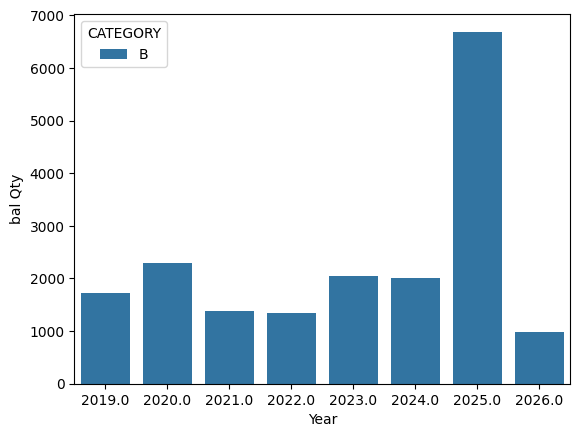

In [2]:
# تصفية البيانات
sectio_df = combined_df[combined_df['Section'] == '4051']

# عمل pivot table مع الـ CATEGORY
pivot_df = pd.pivot_table(
    sectio_df,
    index=['Section', 'CATEGORY'],  # خلي الـ index يشمل الـ Section و الـ CATEGORY
    columns='Year',
    values='bal Qty',
    aggfunc='sum'
).reset_index()

# تحويل pivot table إلى صيغة طويلة مع الـ CATEGORY
long_df = pivot_df.melt(id_vars=['Section', 'CATEGORY'], var_name='Year', value_name='bal Qty')

# رسم البيانات باستخدام seaborn
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=long_df, x='Year', y='bal Qty', hue='CATEGORY')
plt.show()

In [3]:
pivot_df

Year,Section,CATEGORY,2019.0,2020.0,2021.0,2022.0,2023.0,2024.0,2025.0,2026.0
0,4051,B,1731.390015,2292.300049,1376.050049,1352.800049,2049.100098,2010.949951,6687.850098,989.650024
